# Sensor-Based Air Pollutant Concentration Regression
**Machine Learning · Assignment #1 · Air Quality Monitoring (UCI Air Quality dataset)**

Predict a ground-truth pollutant concentration from low-cost metal-oxide sensor signals and weather variables, using Linear / Polynomial regression (from scratch + scikit-learn) and Decision Tree regressors.

| Stage | Contents | Status |
|---|---|---|
| **1. Data Preparation** | Load, EDA, missing values, target & feature selection, scaling, 80/20 split | ✅ this section |
| **2. Model Training** | Linear & polynomial regression from scratch, sklearn cross-check, Decision Trees (`max_depth` sweep), CV tuning, ablations | ✅ |
| 3. Model Evaluation | MSE, RMSE, R²; metric vs. epoch and vs. tree depth | ✅ |
| 4. Model Visualization | Tree plot (`max_depth=3`), feature importances | ✅ |
| 5. Baseline Comparison | Linear vs. Decision Tree | ✅ |
| 6. Discussion | Short written answers | ⏳ |

## Stage 1 — Data Preparation
### 1.0 Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

SEED = 42                       # single seed -> reproducible split
DATA_PATH = "../../data/air+quality/AirQualityUCI.csv"   # relative to src/notebooks/

# Plot style: clean, recessive grid, colour-blind-safe (Okabe-Ito) palette
BLUE, ORANGE, GREEN, RED, GREY = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#7F7F7F"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "grid.alpha": 0.35, "axes.titleweight": "bold", "axes.titlesize": 12})
pd.set_option("display.max_columns", 30, "display.width", 140, "display.float_format", "{:,.3f}".format)

### 1.1 Load the data
The UCI CSV is **semicolon-separated with decimal commas**, and has two trailing empty columns and trailing blank rows (an Excel export artefact). We parse it accordingly.

In [2]:
raw = pd.read_csv(DATA_PATH, sep=";", decimal=",")
print(f"Raw file shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
display(raw.head())
display(raw.tail(3))

Raw file shape: 9,471 rows x 17 columns


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.600,"1,360.000",150.000,11.900,"1,046.000",166.000,"1,056.000",113.000,"1,692.000","1,268.000",13.600,48.900,0.758,NaN,NaN
1,10/03/2004,19.00.00,2.000,"1,292.000",112.000,9.400,955.000,103.000,"1,174.000",92.000,"1,559.000",972.000,13.300,47.700,0.726,NaN,NaN
2,10/03/2004,20.00.00,2.200,"1,402.000",88.000,9.000,939.000,131.000,"1,140.000",114.000,"1,555.000","1,074.000",11.900,54.000,0.750,NaN,NaN
3,10/03/2004,21.00.00,2.200,"1,376.000",80.000,9.200,948.000,172.000,"1,092.000",122.000,"1,584.000","1,203.000",11.000,60.000,0.787,NaN,NaN
4,10/03/2004,22.00.00,1.600,"1,272.000",51.000,6.500,836.000,131.000,"1,205.000",116.000,"1,490.000","1,110.000",11.200,59.600,0.789,NaN,NaN


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9470,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2 Structural cleaning (artefacts of the file format)

In [3]:
df = raw.dropna(how="all").dropna(axis=1, how="all").copy()   # drop blank rows / the 2 empty 'Unnamed' columns
print(f"After removing blank rows/columns: {df.shape[0]:,} rows x {df.shape[1]} columns "
      f"(removed {raw.shape[0]-df.shape[0]} blank rows, {raw.shape[1]-df.shape[1]} empty columns)")

# Build a proper timestamp and index the data by it (dates are dd/mm/yyyy, times use '.' separators)
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], format="%d/%m/%Y %H.%M.%S")
df = df.drop(columns=["Date", "Time"]).set_index("Datetime").sort_index()

GT_COLS     = ["CO(GT)", "NMHC(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]       # candidate targets
SENSOR_COLS = ["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)", "PT08.S4(NO2)", "PT08.S5(O3)"]
WEATHER_COLS = ["T", "RH", "AH"]
FEATURE_CANDIDATES = SENSOR_COLS + WEATHER_COLS

print("\nTime coverage :", df.index.min(), "->", df.index.max())
print("Duplicate rows:", df.duplicated().sum(), "| duplicate timestamps:", df.index.duplicated().sum())
gaps = df.index.to_series().diff().value_counts()
print("Gaps between consecutive timestamps:\n", gaps.to_string())

After removing blank rows/columns: 9,357 rows x 15 columns (removed 114 blank rows, 2 empty columns)

Time coverage : 2004-03-10 18:00:00 -> 2005-04-04 14:00:00
Duplicate rows: 31 | duplicate timestamps: 0
Gaps between consecutive timestamps:
 Datetime
0 days 01:00:00    9356


**Observations.** The series is a clean, gap-free hourly grid (every step is exactly 1 h) with no duplicates. Note the data really ends in **April 2005**, slightly beyond the "March 2004 – February 2005" in the brief — it is just over one year, so every season (and weather regime) appears at least once.

### 1.3 Schema, dtypes and raw summary statistics

In [4]:
schema = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "role": ["target candidate" if c in GT_COLS else "sensor feature" if c in SENSOR_COLS else "weather feature" for c in df.columns],
    "n_unique": df.nunique(),
})
display(schema)
print("RAW describe() (before treating -200 as missing):")
display(df.describe().T)

,dtype,role,n_unique
CO(GT),float64,target candidate,97
PT08.S1(CO),float64,sensor feature,1042
NMHC(GT),float64,target candidate,430
C6H6(GT),float64,target candidate,408
PT08.S2(NMHC),float64,sensor feature,1246
NOx(GT),float64,target candidate,926
PT08.S3(NOx),float64,sensor feature,1222
NO2(GT),float64,target candidate,284
PT08.S4(NO2),float64,sensor feature,1604
PT08.S5(O3),float64,sensor feature,1744


RAW describe() (before treating -200 as missing):


,count,mean,std,min,25%,50%,75%,max
CO(GT),"9,357.000",-34.208,77.657,-200.000,0.600,1.500,2.600,11.900
PT08.S1(CO),"9,357.000","1,048.990",329.833,-200.000,921.000,"1,053.000","1,221.000","2,040.000"
NMHC(GT),"9,357.000",-159.090,139.789,-200.000,-200.000,-200.000,-200.000,"1,189.000"
C6H6(GT),"9,357.000",1.866,41.380,-200.000,4.000,7.900,13.600,63.700
PT08.S2(NMHC),"9,357.000",894.595,342.333,-200.000,711.000,895.000,"1,105.000","2,214.000"
NOx(GT),"9,357.000",168.617,257.434,-200.000,50.000,141.000,284.000,"1,479.000"
PT08.S3(NOx),"9,357.000",794.990,321.994,-200.000,637.000,794.000,960.000,"2,683.000"
NO2(GT),"9,357.000",58.149,126.940,-200.000,53.000,96.000,133.000,340.000
PT08.S4(NO2),"9,357.000","1,391.480",467.210,-200.000,"1,185.000","1,446.000","1,662.000","2,775.000"
PT08.S5(O3),"9,357.000",975.072,456.938,-200.000,700.000,942.000,"1,255.000","2,523.000"


**Observation — hidden missing values.** `min` is **-200** in every column. Concentrations, humidity and sensor voltages cannot be negative, and `T = -200 °C` is physically impossible. The UCI documentation states that **-200 is the missing-value sentinel**. Left untreated it would badly distort every statistic, scaler and regression fit, so we convert it to `NaN` first.

### 1.4 Missing-value diagnosis

,missing,missing_%,valid
NMHC(GT),8443,90.2%,914
CO(GT),1683,18.0%,7674
NO2(GT),1642,17.5%,7715
NOx(GT),1639,17.5%,7718
PT08.S1(CO),366,3.9%,8991
C6H6(GT),366,3.9%,8991
PT08.S2(NMHC),366,3.9%,8991
PT08.S3(NOx),366,3.9%,8991
PT08.S4(NO2),366,3.9%,8991
PT08.S5(O3),366,3.9%,8991


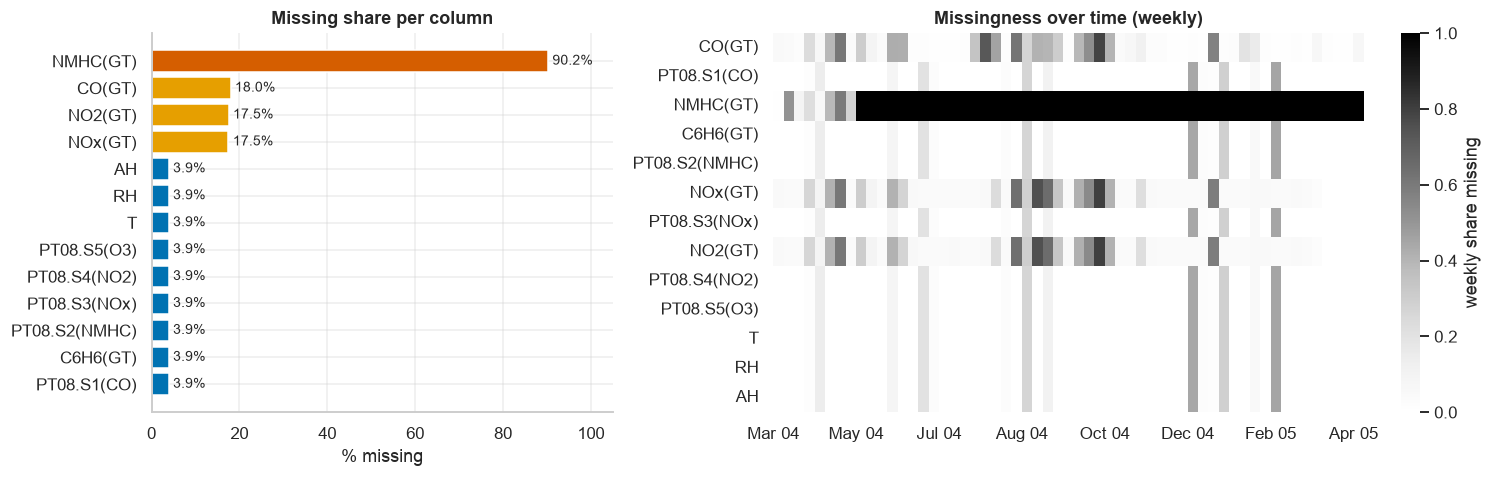

In [5]:
df = df.replace(-200, np.nan)

miss = pd.DataFrame({"missing": df.isna().sum(), "missing_%": df.isna().mean() * 100,
                     "valid": df.notna().sum()}).sort_values("missing_%", ascending=False)
display(miss.style.background_gradient(subset=["missing_%"], cmap="Oranges").format({"missing_%": "{:.1f}%"}))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={"width_ratios": [1, 1.6]})
m = miss["missing_%"].sort_values()
axes[0].barh(m.index, m.values, color=[RED if v > 50 else ORANGE if v > 10 else BLUE for v in m.values])
for i, v in enumerate(m.values): axes[0].text(v + 1, i, f"{v:.1f}%", va="center", fontsize=9)
axes[0].set_xlim(0, 105); axes[0].set_xlabel("% missing"); axes[0].set_title("Missing share per column")

# Missingness over time: one row per column, dark = missing
sns.heatmap(df.isna().T.astype(int).resample("D", axis=1).mean() if False else
            df.isna().astype(int).resample("W").mean().T, cmap="Greys", cbar_kws={"label": "weekly share missing"},
            ax=axes[1], xticklabels=False)
wk = df.isna().astype(int).resample("W").mean().index
axes[1].set_xticks(np.arange(0, len(wk), 8)); axes[1].set_xticklabels([d.strftime("%b %y") for d in wk[::8]], rotation=0)
axes[1].set_title("Missingness over time (weekly)"); axes[1].set_xlabel("")
plt.tight_layout(); plt.show()

Rows with ALL 8 sensor/weather features missing : 366
Rows with ANY   sensor/weather feature missing  : 366  -> partial-missing rows = 0
Rows where C6H6(GT) is missing ALSO have all features missing: True


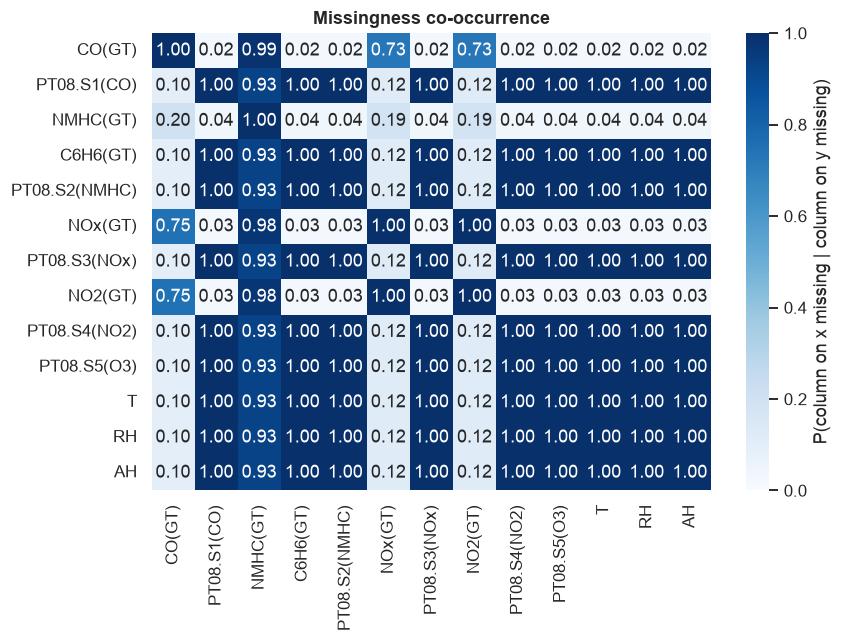


Longest consecutive outage (hours):
{'CO(GT)': 173, 'NOx(GT)': 173, 'NO2(GT)': 173, 'C6H6(GT)': 76, 'PT08.S1(CO)': 76}


In [6]:
# Is the missingness structured?  (a) rows where ALL sensors+weather are missing, (b) how GT-missingness overlaps
all_feat_missing = df[FEATURE_CANDIDATES].isna().all(axis=1)
any_feat_missing = df[FEATURE_CANDIDATES].isna().any(axis=1)
print(f"Rows with ALL 8 sensor/weather features missing : {all_feat_missing.sum()}")
print(f"Rows with ANY   sensor/weather feature missing  : {any_feat_missing.sum()}  "
      f"-> partial-missing rows = {(any_feat_missing & ~all_feat_missing).sum()}")
print(f"Rows where C6H6(GT) is missing ALSO have all features missing: "
      f"{(df['C6H6(GT)'].isna() == all_feat_missing).all()}")

# Missingness co-occurrence matrix (Jaccard-style: P(col B missing | col A missing))
M = df.isna().astype(int)
cooc = pd.DataFrame({b: {a: (M[a] & M[b]).sum() / max(M[a].sum(), 1) for a in M.columns} for b in M.columns})
plt.figure(figsize=(8, 6))
sns.heatmap(cooc, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar_kws={"label": "P(column on x missing | column on y missing)"})
plt.title("Missingness co-occurrence"); plt.tight_layout(); plt.show()

# Longest consecutive outage of target candidates (hours)
def longest_run(s):
    g = s.ne(s.shift()).cumsum(); r = s.groupby(g).sum(); return int(r.max())
print("\nLongest consecutive outage (hours):")
print({c: longest_run(df[c].isna()) for c in ["CO(GT)", "NOx(GT)", "NO2(GT)", "C6H6(GT)", "PT08.S1(CO)"]})

**Diagnosis**
- **NMHC(GT) is ~90 % missing** (only 914 valid hours). It is unusable as a target and cannot be imputed credibly → **excluded**.
- All five sensors, `T`, `RH`, `AH` and `C6H6(GT)` share the **same 366 missing hours**: whole rows are blank (instrument outages), there are *no* partially-missing feature rows. The missingness co-occurrence matrix confirms the block structure. There is nothing to impute for the features – those rows hold **zero** information and are dropped.
- `CO(GT)`, `NOx(GT)`, `NO2(GT)` are additionally missing for ~1.3–1.7 k hours (≈17–18 %), as the reference analyser was offline at times, often for long consecutive stretches (see the outage lengths above) — time-interpolating across multi-day gaps would fabricate data.
- **Never impute the target**: a regression label filled in by a heuristic makes the model learn the heuristic. Rows without a target are dropped.

### 1.5 Choosing the target variable

In [7]:
cand = pd.DataFrame(index=GT_COLS)
cand["valid_rows"] = df[GT_COLS].notna().sum()
cand["valid_%"] = df[GT_COLS].notna().mean() * 100
cand["usable_rows (target & features valid)"] = [(df[c].notna() & ~any_feat_missing).sum() for c in GT_COLS]
cand["skew"] = df[GT_COLS].skew()
# strongest single-sensor linear relation (|Pearson r|) and the sensor it comes from
best = {c: df[[c] + FEATURE_CANDIDATES].corr()[c].drop(c).abs().sort_values(ascending=False).head(1) for c in GT_COLS}
cand["best |r| with a feature"] = [best[c].iloc[0] for c in GT_COLS]
cand["... which feature"] = [best[c].index[0] for c in GT_COLS]
display(cand)

,valid_rows,valid_%,usable_rows (target & features valid),skew,best |r| with a feature,... which feature
CO(GT),7674,82.013,7344,1.370,0.916,PT08.S2(NMHC)
NMHC(GT),914,9.768,887,1.557,0.878,PT08.S2(NMHC)
C6H6(GT),8991,96.088,8991,1.362,0.982,PT08.S2(NMHC)
NOx(GT),7718,82.484,7396,1.716,0.787,PT08.S5(O3)
NO2(GT),7715,82.452,7393,0.622,0.708,PT08.S5(O3)


**Decision: target = `CO(GT)`** (true hourly CO concentration, mg/m³).

| Candidate | Verdict |
|---|---|
| `NMHC(GT)` | ~90 % missing → rejected. |
| `C6H6(GT)` | Most complete, but benzene in this dataset is almost a deterministic function of the `PT08.S2(NMHC)` sensor (|r| ≈ 0.98) — the task would be trivial and not discriminate between models. |
| `NOx(GT)` / `NO2(GT)` | Valid, but ~17 % missing and `NOx` is extremely right-skewed. |
| **`CO(GT)`** | ~7.7 k valid rows (plenty), has a **strong but imperfect** relation (|r| ≈ 0.9 with `PT08.S2`) with several sensors, a visible non-linear component, and a diurnal traffic signal — ideal for contrasting Linear/Polynomial regression with Decision Trees. |

Features are restricted to the **8 sensors + weather variables** as the brief specifies; the other GT pollutants are *not* used as predictors (they would be unavailable at inference time for a low-cost sensor and would leak the answer).

In [8]:
TARGET = "CO(GT)"
FEATURES = FEATURE_CANDIDATES.copy()
print("Target  :", TARGET)
print("Features:", FEATURES)

# Drop: (i) rows with no sensor/weather readings, (ii) rows with no target.  -> Never impute the target.
data = df[FEATURES + [TARGET]].dropna()
flow = pd.DataFrame({"step": ["Raw rows after structural cleaning", "- rows with all features missing (sensor outage)",
                              f"- rows with missing target {TARGET}", "= Modelling dataset"],
                     "rows": [len(df), -int(any_feat_missing.sum()),
                              -int((df[FEATURES].notna().all(axis=1) & df[TARGET].isna()).sum()), len(data)]})
display(flow)
assert data.isna().sum().sum() == 0
print(f"Retained {len(data)/len(df):.1%} of hourly records; remaining NaNs: {int(data.isna().sum().sum())}")

Target  : CO(GT)
Features: ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


,step,rows
0,Raw rows after structural cleaning,9357
1,- rows with all features missing (sensor outage),-366
2,- rows with missing target CO(GT),-1647
3,= Modelling dataset,7344


Retained 78.5% of hourly records; remaining NaNs: 0


### 1.6 Target analysis — `CO(GT)`: distribution, class-wise balance

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,kurtosis,CV (std/mean)
CO(GT),"7,344.000",2.130,1.436,0.100,0.200,0.500,1.100,1.800,2.800,4.900,6.700,11.900,1.357,2.658,0.674


Distinct target values: 94 | smallest step: 0.1


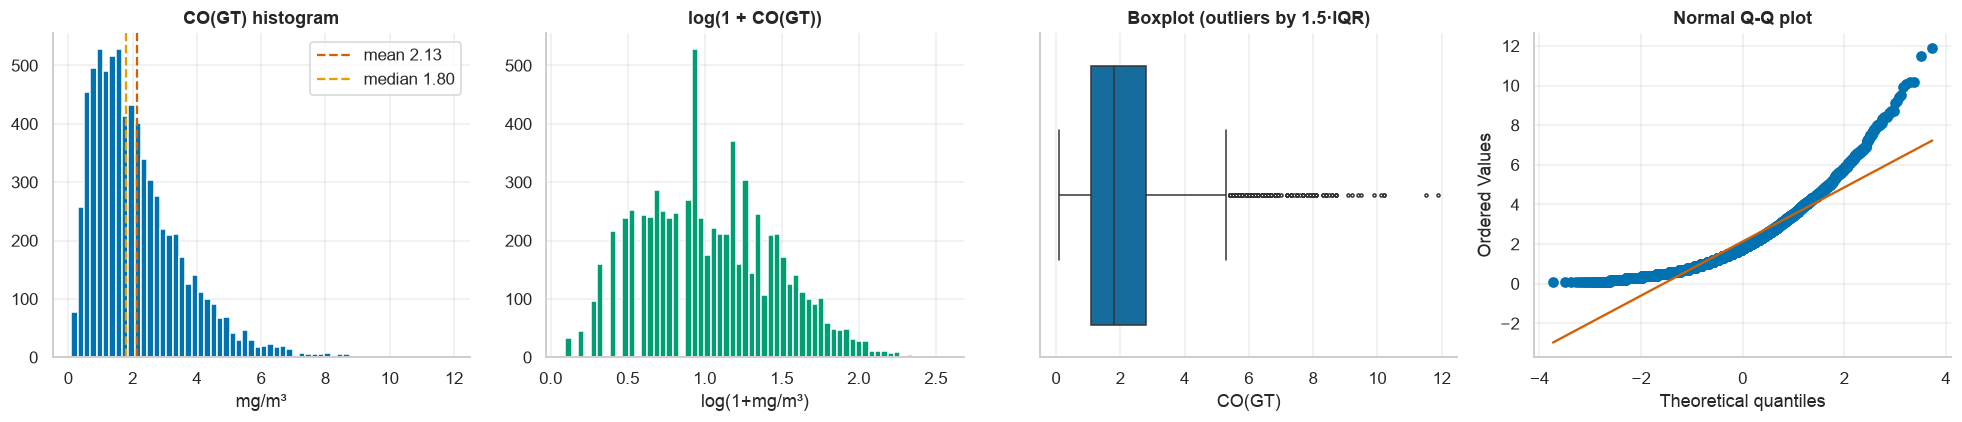

Shapiro-Wilk (5k sample): W=0.901, p=5.4e-49 -> normality rejected; skew 1.36 -> log-transform skew 0.22


In [9]:
y = data[TARGET]
desc = y.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_frame("CO(GT)").T
desc["skew"], desc["kurtosis"] = y.skew(), y.kurt()
desc["CV (std/mean)"] = y.std() / y.mean()
display(desc)

# Resolution of the label: CO is reported in 0.1 mg/m3 steps
print("Distinct target values:", y.nunique(), "| smallest step:", np.diff(np.sort(y.unique())).min().round(2))

fig, ax = plt.subplots(1, 4, figsize=(18, 4))
ax[0].hist(y, bins=60, color=BLUE, edgecolor="white"); ax[0].axvline(y.mean(), color=RED, ls="--", label=f"mean {y.mean():.2f}")
ax[0].axvline(y.median(), color=ORANGE, ls="--", label=f"median {y.median():.2f}"); ax[0].legend(); ax[0].set_title("CO(GT) histogram"); ax[0].set_xlabel("mg/m³")
ax[1].hist(np.log1p(y), bins=60, color=GREEN, edgecolor="white"); ax[1].set_title("log(1 + CO(GT))"); ax[1].set_xlabel("log(1+mg/m³)")
sns.boxplot(x=y, ax=ax[2], color=BLUE, fliersize=2); ax[2].set_title("Boxplot (outliers by 1.5·IQR)")
stats.probplot(y, dist="norm", plot=ax[3]); ax[3].set_title("Normal Q-Q plot")
ax[3].get_lines()[0].set_color(BLUE); ax[3].get_lines()[1].set_color(RED)
plt.tight_layout(); plt.show()
sh_stat, sh_p = stats.shapiro(y.sample(5000, random_state=SEED))
print(f"Shapiro-Wilk (5k sample): W={sh_stat:.3f}, p={sh_p:.1e} -> normality {'rejected' if sh_p < .05 else 'not rejected'}; "
      f"skew {y.skew():.2f} -> log-transform skew {np.log1p(y).skew():.2f}")

**Observations.** `CO(GT)` is **right-skewed** (skew ≈ 1.3, long tail up to ~12 mg/m³ with a few high-pollution episodes); mean > median; Shapiro-Wilk rejects normality; the Q-Q plot bends upward at the upper tail. The values are quantised in 0.1 mg/m³ steps.
Implications: MSE/RMSE will be dominated by the rare high-concentration hours, and a plain linear fit will tend to under-predict the peaks. We keep the target in **original units** so the reported RMSE is physically interpretable (mg/m³) and comparable across all models; a log-transform is noted as an optional experiment, not applied by default.

#### Class-wise balance
CO(GT) is a continuous target, so "classes" are defined by binning it into **air-quality regimes**. We use the quartile bins (equal-count, to check how the split is balanced) and the EU/WHO-motivated bands (8-h limit of ~10 mg/m³ is hit only extremely rarely, so we use practical bands: *Low < 1.5, Moderate 1.5–3, High 3–5, Very high ≥ 5 mg/m³*).

,count,share_%,mean_CO,std_CO
CO(GT),,,,
Low (<1.5),2820,38.399,0.884,0.341
Moderate (1.5-3),2808,38.235,2.102,0.423
High (3-5),1369,18.641,3.740,0.548
Very high (>=5),347,4.725,6.124,1.141


Imbalance ratio (largest : smallest regime) = 8.1 : 1
Quartile bins: {Interval(0.099, 1.1, closed='right'): 2064, Interval(1.1, 1.8, closed='right'): 1698, Interval(1.8, 2.8, closed='right'): 1753, Interval(2.8, 11.9, closed='right'): 1829}


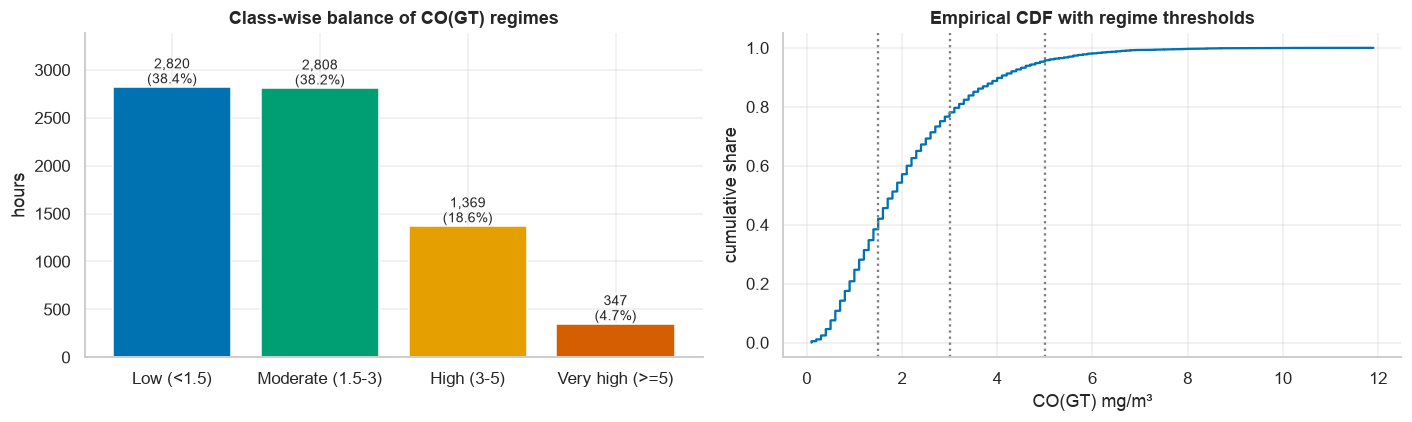

In [10]:
bands_edges  = [0, 1.5, 3, 5, np.inf]
bands_labels = ["Low (<1.5)", "Moderate (1.5-3)", "High (3-5)", "Very high (>=5)"]
band = pd.cut(y, bins=bands_edges, labels=bands_labels, right=False)
quart = pd.qcut(y, 4, duplicates="drop")

bal = pd.DataFrame({"count": band.value_counts().sort_index()})
bal["share_%"] = bal["count"] / bal["count"].sum() * 100
bal["mean_CO"] = y.groupby(band).mean(); bal["std_CO"] = y.groupby(band).std()
display(bal)
imbalance_ratio = bal["count"].max() / bal["count"].min()
print(f"Imbalance ratio (largest : smallest regime) = {imbalance_ratio:.1f} : 1")
print("Quartile bins:", quart.value_counts().sort_index().to_dict())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
colors = [BLUE, GREEN, ORANGE, RED]
ax[0].bar(bal.index, bal["count"], color=colors)
for i, (c, s) in enumerate(zip(bal["count"], bal["share_%"])): ax[0].text(i, c + 40, f"{c:,}\n({s:.1f}%)", ha="center", fontsize=9)
ax[0].set_ylim(0, bal["count"].max() * 1.2); ax[0].set_title("Class-wise balance of CO(GT) regimes"); ax[0].set_ylabel("hours")
ecdf = np.sort(y); ax[1].plot(ecdf, np.arange(1, len(ecdf) + 1) / len(ecdf), color=BLUE)
for e in bands_edges[1:-1]: ax[1].axvline(e, color=GREY, ls=":")
ax[1].set_title("Empirical CDF with regime thresholds"); ax[1].set_xlabel("CO(GT) mg/m³"); ax[1].set_ylabel("cumulative share")
plt.tight_layout(); plt.show()

**Diagnosis — imbalance.** The regimes are clearly **imbalanced**: most hours are *Low/Moderate* and only a few percent are *Very high*. For regression this matters in three ways:
1. A random split may by chance put too few extreme hours in the test set → unstable R². We therefore make the **80/20 split stratified on these regime bins**, so train and test have the same target distribution (verified in §1.12).
2. Error metrics are dominated by the rare high values; we will also report errors **per regime** during evaluation (Stage 3).
3. We do **not** re-sample/oversample (that is a classification remedy and would distort the continuous target); stratification is the appropriate control.

### 1.7 Feature analysis — distributions & descriptive statistics

In [11]:
X = data[FEATURES]
fs = X.describe(percentiles=[.01, .25, .5, .75, .99]).T
fs["skew"], fs["kurtosis"], fs["CV"] = X.skew(), X.kurt(), X.std() / X.mean()
fs["range"] = fs["max"] - fs["min"]
display(fs)
print("Scale mismatch: largest/smallest feature std =", f"{X.std().max() / X.std().min():,.0f}x",
      "| largest/smallest mean magnitude =", f"{X.mean().abs().max() / X.mean().abs().min():,.0f}x")

,count,mean,std,min,1%,25%,50%,75%,99%,max,skew,kurtosis,CV,range
PT08.S1(CO),"7,344.000","1,110.581",218.681,647.000,746.000,946.000,"1,075.000","1,246.000","1,722.570","2,040.000",0.727,0.294,0.197,"1,393.000"
PT08.S2(NMHC),"7,344.000",947.198,265.472,387.000,471.430,743.000,919.000,"1,125.250","1,642.140","2,214.000",0.532,0.033,0.280,"1,827.000"
PT08.S3(NOx),"7,344.000",826.920,256.648,322.000,401.000,649.000,795.000,960.000,"1,664.570","2,683.000",1.152,2.917,0.310,"2,361.000"
PT08.S4(NO2),"7,344.000","1,444.753",350.344,551.000,742.000,"1,203.000","1,447.000","1,673.000","2,342.420","2,775.000",0.219,-0.031,0.242,"2,224.000"
PT08.S5(O3),"7,344.000","1,043.513",405.570,221.000,347.000,744.750,990.000,"1,305.000","2,109.140","2,523.000",0.577,0.003,0.389,"2,302.000"
T,"7,344.000",17.770,8.863,-1.900,2.043,11.200,16.900,23.800,39.300,44.600,0.377,-0.417,0.499,46.500
RH,"7,344.000",49.060,17.452,9.200,14.800,35.400,49.300,62.500,83.057,88.700,-0.015,-0.844,0.356,79.500
AH,"7,344.000",0.989,0.400,0.185,0.273,0.698,0.960,1.259,1.940,2.181,0.340,-0.460,0.404,1.996


Scale mismatch: largest/smallest feature std = 1,014x | largest/smallest mean magnitude = 1,460x


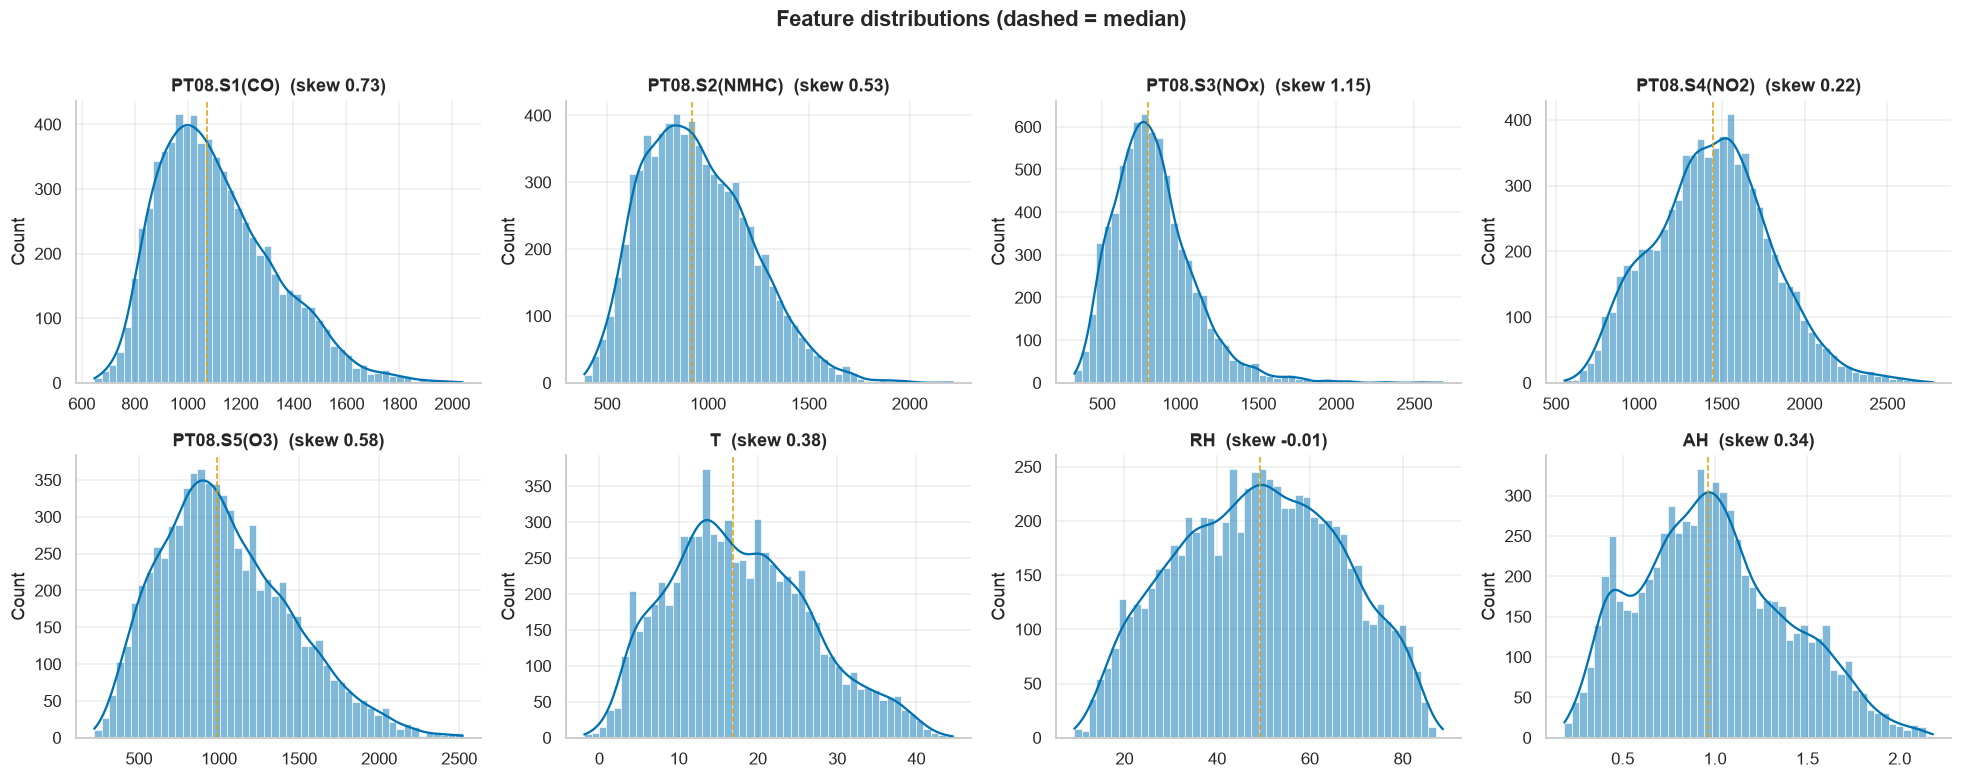

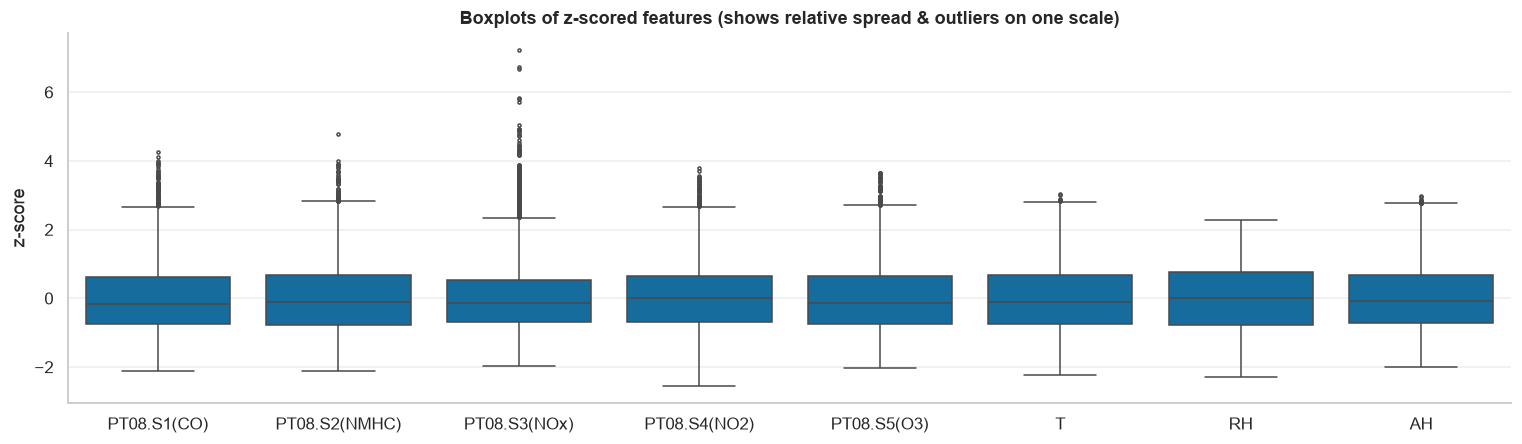

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for a, c in zip(axes.ravel(), FEATURES):
    sns.histplot(X[c], bins=50, kde=True, color=BLUE, ax=a, edgecolor="white")
    a.axvline(X[c].median(), color=ORANGE, ls="--", lw=1); a.set_title(f"{c}  (skew {X[c].skew():.2f})"); a.set_xlabel("")
plt.suptitle("Feature distributions (dashed = median)", y=1.01, fontweight="bold"); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(14, 4.2))
sns.boxplot(data=(X - X.mean()) / X.std(), orient="v", ax=ax, color=BLUE, fliersize=2)
ax.set_title("Boxplots of z-scored features (shows relative spread & outliers on one scale)"); ax.set_ylabel("z-score")
plt.tight_layout(); plt.show()

**Observations.**
- **Wildly different scales**: sensors are in the hundreds–thousands (≈ 200–2800), `T` ≈ −2…45 °C, `RH` ≈ 10–90 %, `AH` ≈ 0.2–2.2. Gradient-descent regression (Stage 2, "metric vs. epoch") and polynomial features need **standardisation**; otherwise the large-scale sensors dominate the gradient and the high-degree terms explode numerically. Decision Trees are scale-invariant, so they will be fed the same scaled data purely for a fair like-for-like comparison.
- `PT08.S3(NOx)` is clearly right-skewed with a long tail (skew ≈ 1.15, kurtosis ≈ 2.9); the other sensors are mildly skewed; `T`, `RH`, `AH` are broad and roughly symmetric (`RH` and `AH` platykurtic).
- No physically impossible values remain after the −200 treatment (checked below).

### 1.8 Outlier & validity audit

,IQR outliers (n),IQR outliers (%),|z|>3 (n),max |z|
PT08.S1(CO),90.000,1.225,46.000,4.250
PT08.S2(NMHC),47.000,0.640,29.000,4.772
PT08.S3(NOx),191.000,2.601,91.000,7.232
PT08.S4(NO2),65.000,0.885,29.000,3.797
PT08.S5(O3),65.000,0.885,27.000,3.648
T,6.000,0.082,1.000,3.027
RH,0.000,0.000,0.000,2.284
AH,18.000,0.245,0.000,2.979
CO(GT),257.000,3.499,98.000,6.802


,passes
CO(GT) >= 0,True
"RH within [0,100]",True
AH > 0,True
sensor signals > 0,True
T in plausible range (-10..50 C),True


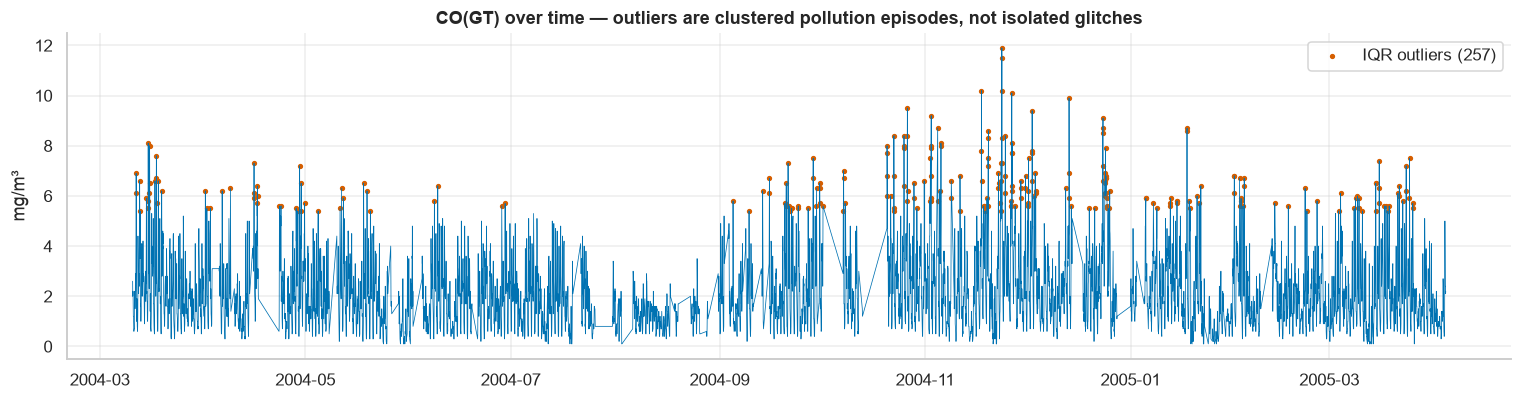

In [13]:
Z = (X - X.mean()) / X.std()
q1, q3 = X.quantile(.25), X.quantile(.75); iqr = q3 - q1
out = pd.DataFrame({
    "IQR outliers (n)": ((X < q1 - 1.5 * iqr) | (X > q3 + 1.5 * iqr)).sum(),
    "IQR outliers (%)": ((X < q1 - 1.5 * iqr) | (X > q3 + 1.5 * iqr)).mean() * 100,
    "|z|>3 (n)": (Z.abs() > 3).sum(),
    "max |z|": Z.abs().max()})
yq1, yq3 = y.quantile([.25, .75]); yi = yq3 - yq1
out.loc[TARGET] = [int(((y < yq1 - 1.5*yi) | (y > yq3 + 1.5*yi)).sum()), ((y < yq1 - 1.5*yi) | (y > yq3 + 1.5*yi)).mean()*100,
                   int((((y - y.mean()) / y.std()).abs() > 3).sum()), ((y - y.mean()) / y.std()).abs().max()]
display(out)

# Physical-validity checks
checks = {"CO(GT) >= 0": (y >= 0).all(), "RH within [0,100]": X["RH"].between(0, 100).all(),
          "AH > 0": (X["AH"] > 0).all(), "sensor signals > 0": (X[SENSOR_COLS] > 0).all().all(),
          "T in plausible range (-10..50 C)": X["T"].between(-10, 50).all()}
display(pd.Series(checks, name="passes").to_frame())

# Are the outliers real events or glitches?  Look at the extreme hours in time.
fig, ax = plt.subplots(figsize=(14, 3.8))
ax.plot(y.index, y, lw=.5, color=BLUE); hi = y[y > yq3 + 1.5 * yi]
ax.scatter(hi.index, hi, s=6, color=RED, label=f"IQR outliers ({len(hi)})")
ax.set_title("CO(GT) over time — outliers are clustered pollution episodes, not isolated glitches"); ax.set_ylabel("mg/m³"); ax.legend()
plt.tight_layout(); plt.show()

**Decision — keep the outliers.** They are not random sensor glitches: ~70 % of the flagged CO hours have another flagged hour right next to them (contiguous *episodes*), and they concentrate in the **morning (08–09 h) and evening (17–20 h) rush hours**, consistent with traffic emissions and with high sensor readings. Removing them would delete exactly the hours a pollution model should learn to predict, and make the test score optimistic. Standardisation (mean/std) is sensitive to outliers but, since none are impossible values, it is retained; no clipping/winsorising is applied.

### 1.9 Relationships — correlations, linearity, multicollinearity

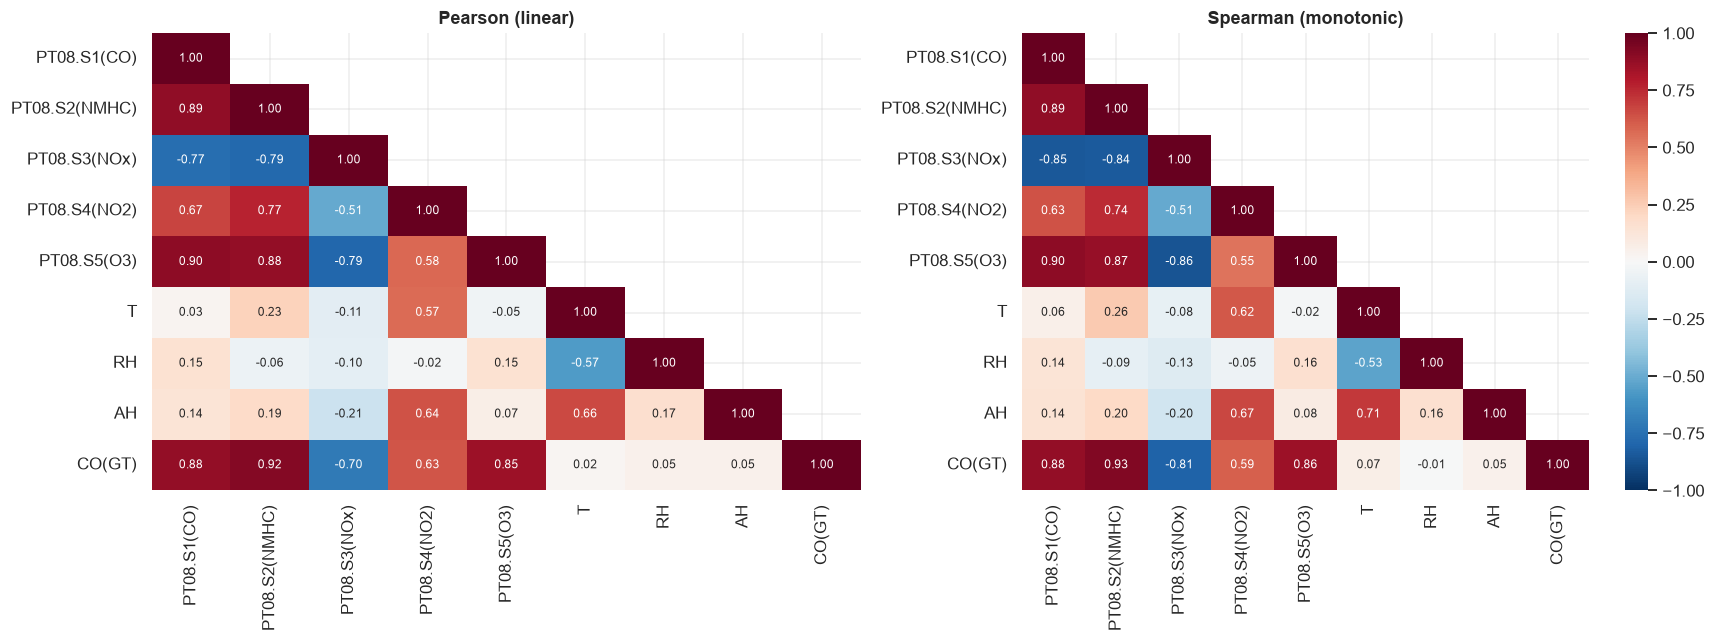

,Pearson r,Spearman rho,|gap|
PT08.S2(NMHC),0.916,0.927,0.011
PT08.S1(CO),0.879,0.879,0.000
PT08.S5(O3),0.854,0.856,0.002
PT08.S3(NOx),-0.703,-0.811,0.108
PT08.S4(NO2),0.631,0.594,-0.036
RH,0.049,-0.006,-0.042
AH,0.049,0.053,0.005
T,0.022,0.069,0.047


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
corr_p = data.corr(method="pearson"); corr_s = data.corr(method="spearman")
mask = np.triu(np.ones_like(corr_p, dtype=bool), k=1)
sns.heatmap(corr_p, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax[0], cbar=False, annot_kws={"size": 8})
ax[0].set_title("Pearson (linear)")
sns.heatmap(corr_s, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax[1], annot_kws={"size": 8})
ax[1].set_title("Spearman (monotonic)"); plt.tight_layout(); plt.show()

rel = pd.DataFrame({"Pearson r": corr_p[TARGET], "Spearman rho": corr_s[TARGET]}).drop(TARGET)
rel["|gap|"] = (rel["Spearman rho"].abs() - rel["Pearson r"].abs())
display(rel.sort_values("Pearson r", key=abs, ascending=False))

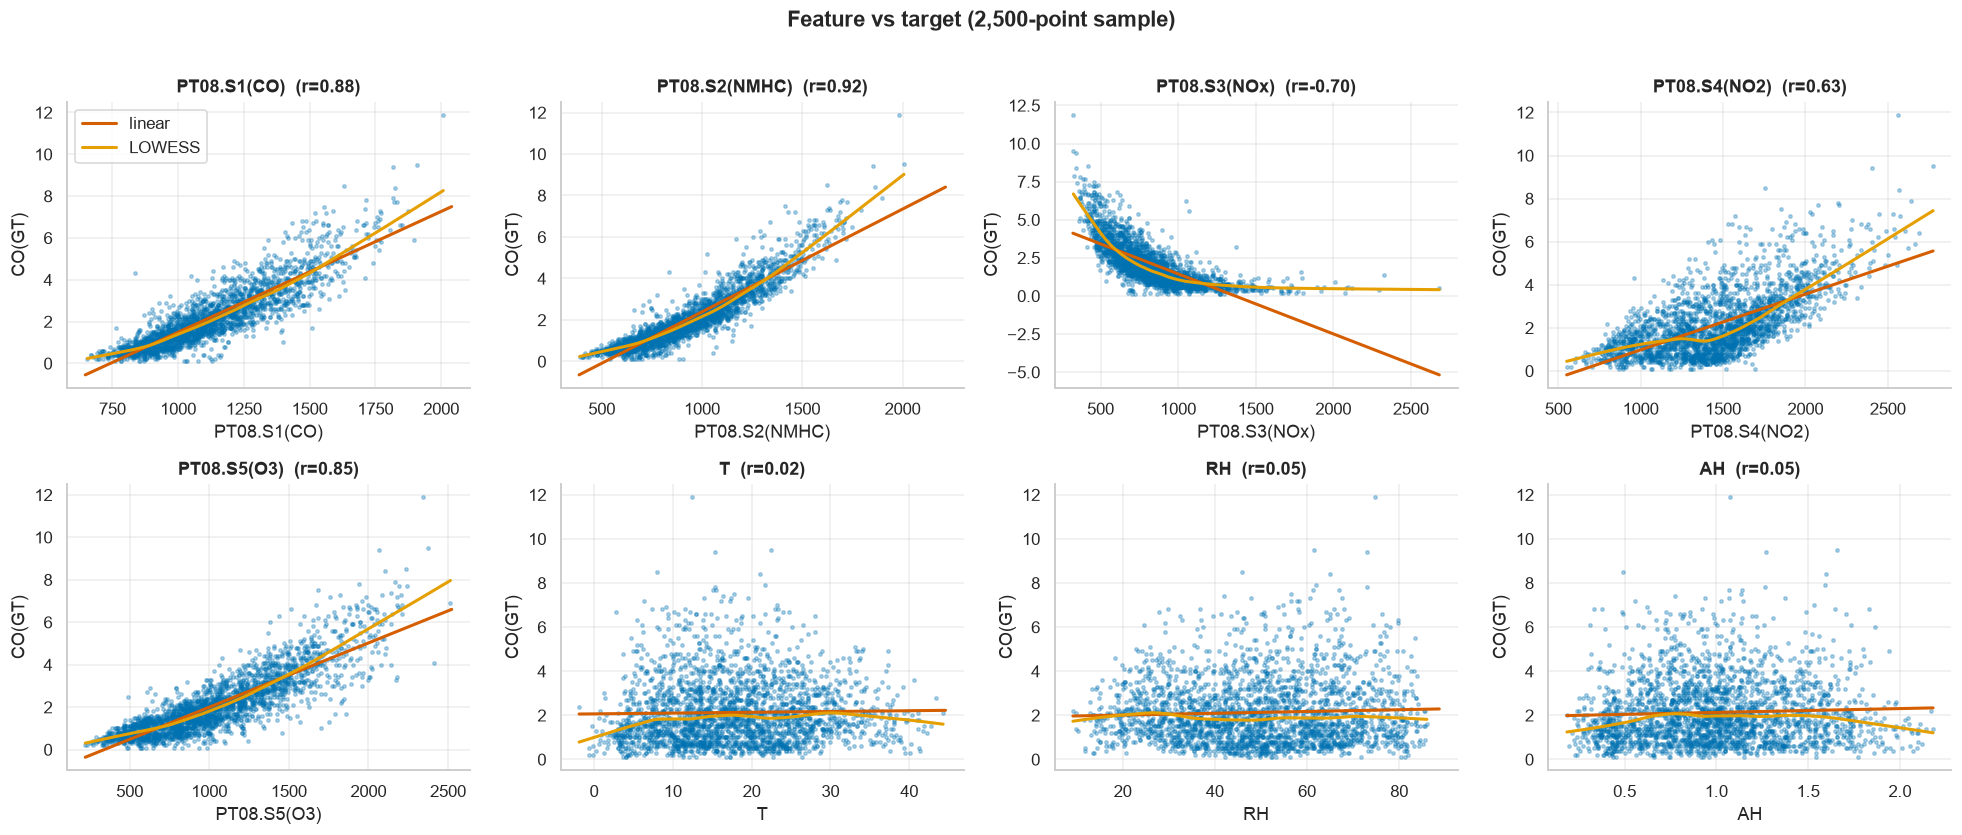

In [15]:
# Scatter of each feature vs target with linear (red) and LOWESS (orange) fits -> reveals non-linearity
from statsmodels.nonparametric.smoothers_lowess import lowess
fig, axes = plt.subplots(2, 4, figsize=(18, 7.5))
samp = data.sample(2500, random_state=SEED)
for a, c in zip(axes.ravel(), FEATURES):
    a.scatter(samp[c], samp[TARGET], s=5, alpha=.3, color=BLUE)
    b = np.polyfit(data[c], y, 1); xs = np.linspace(data[c].min(), data[c].max(), 100)
    a.plot(xs, np.polyval(b, xs), color=RED, lw=2, label="linear")
    lw = lowess(samp[TARGET], samp[c], frac=.3); a.plot(lw[:, 0], lw[:, 1], color=ORANGE, lw=2, label="LOWESS")
    a.set_title(f"{c}  (r={corr_p.loc[c, TARGET]:.2f})"); a.set_xlabel(c); a.set_ylabel("CO(GT)")
axes[0, 0].legend(); plt.suptitle("Feature vs target (2,500-point sample)", y=1.01, fontweight="bold"); plt.tight_layout(); plt.show()

,VIF
PT08.S2(NMHC),15.2
T,13.6
PT08.S4(NO2),10.3
AH,10.0
PT08.S5(O3),8.2
PT08.S1(CO),8.1
RH,7.6
PT08.S3(NOx),4.1


Condition number (standardised X): 10.8


r
PT08.S1(CO)   PT08.S5(O3)    0.898
              PT08.S2(NMHC)  0.888
PT08.S2(NMHC) PT08.S5(O3)    0.877
PT08.S3(NOx)  PT08.S5(O3)   -0.794
PT08.S2(NMHC) PT08.S3(NOx)  -0.785
              PT08.S4(NO2)   0.772

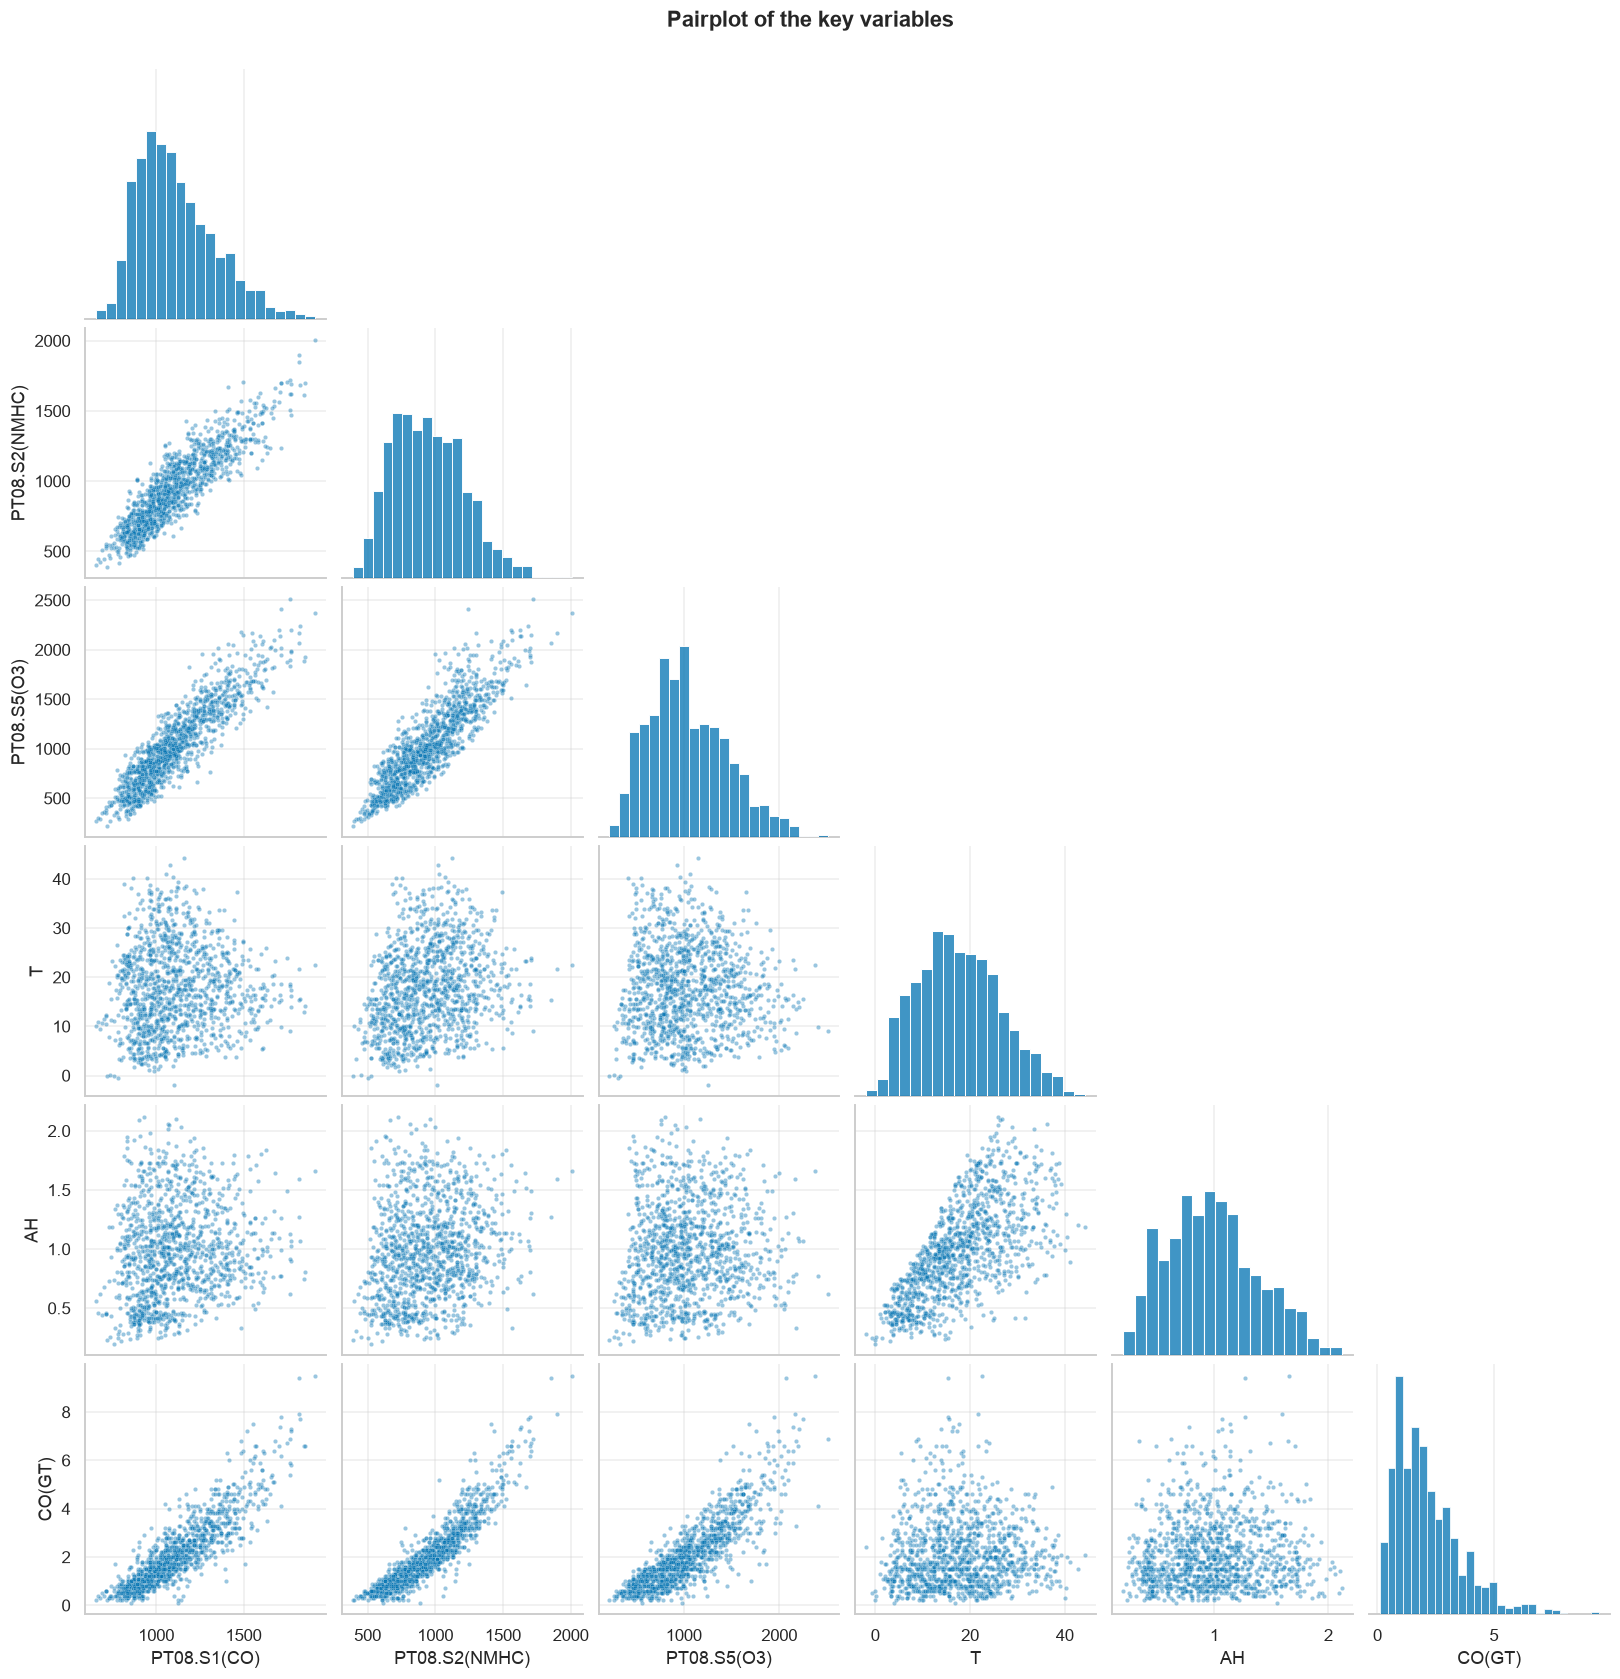

In [16]:
# Multicollinearity: VIF (>5 moderate, >10 severe) and condition number of the standardised feature matrix
Xs = (X - X.mean()) / X.std()
vif = pd.Series([variance_inflation_factor(Xs.values, i) for i in range(Xs.shape[1])], index=FEATURES, name="VIF").sort_values(ascending=False)
display(vif.to_frame().style.background_gradient(cmap="Reds").format("{:.1f}"))
print(f"Condition number (standardised X): {np.linalg.cond(Xs.values):.1f}")

# Most correlated feature pairs
pairs = corr_p.loc[FEATURES, FEATURES].where(np.triu(np.ones((8, 8), bool), 1)).stack().rename("r")
display(pairs.reindex(pairs.abs().sort_values(ascending=False).index).head(6).to_frame())
sns.pairplot(samp[["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S5(O3)", "T", "AH", TARGET]].sample(1200, random_state=SEED),
             corner=True, plot_kws={"s": 8, "alpha": .4, "color": BLUE}, diag_kws={"color": BLUE})
plt.suptitle("Pairplot of the key variables", y=1.02, fontweight="bold"); plt.show()

**Observations.**
- The CO target is most strongly related to **`PT08.S2(NMHC)`, `PT08.S1(CO)`, `PT08.S5(O3)`** (and negatively to `PT08.S3(NOx)`); the weather variables show weak linear association. `PT08.S3(NOx)` has |Spearman| ≈ 0.81 vs |Pearson| ≈ 0.70, i.e. a monotonic but clearly non-linear relation, and the LOWESS curves bend away from the straight line (see plots) → there is **some genuine non-linearity**, which motivates the polynomial and tree models.
- **Severe multicollinearity**: the CO, NMHC and O₃ sensors are strongly inter-correlated, `AH` is tied to `T`/`RH`, and four VIFs exceed 10 (`PT08.S2` ≈ 15, `T` ≈ 14, `PT08.S4` ≈ 10, `AH` ≈ 10; only `PT08.S3` is below 5), although the condition number of the standardised matrix is a moderate ≈ 11. Consequences for the next stages: (a) a degree-1 OLS fit is numerically fine after standardisation, but polynomial expansions will multiply the collinearity → use a stable `lstsq`/`pinv` solve or a small L2 term; (b) individual **linear coefficients will not be reliably interpretable**; (c) tree **feature importances will be split among correlated sensors** – interpret groups, not single features.
- All 8 features are kept: the assignment asks for sensors + weather, no feature is constant, and VIF-driven dropping would hurt tree performance for no benefit. Regularisation (Ridge) is *available* as a remedy if the polynomial fit proves unstable (decided in Stage 2 with validation data, not on the test set).

### 1.10 Temporal structure (seasonality, diurnal cycle, sensor drift)

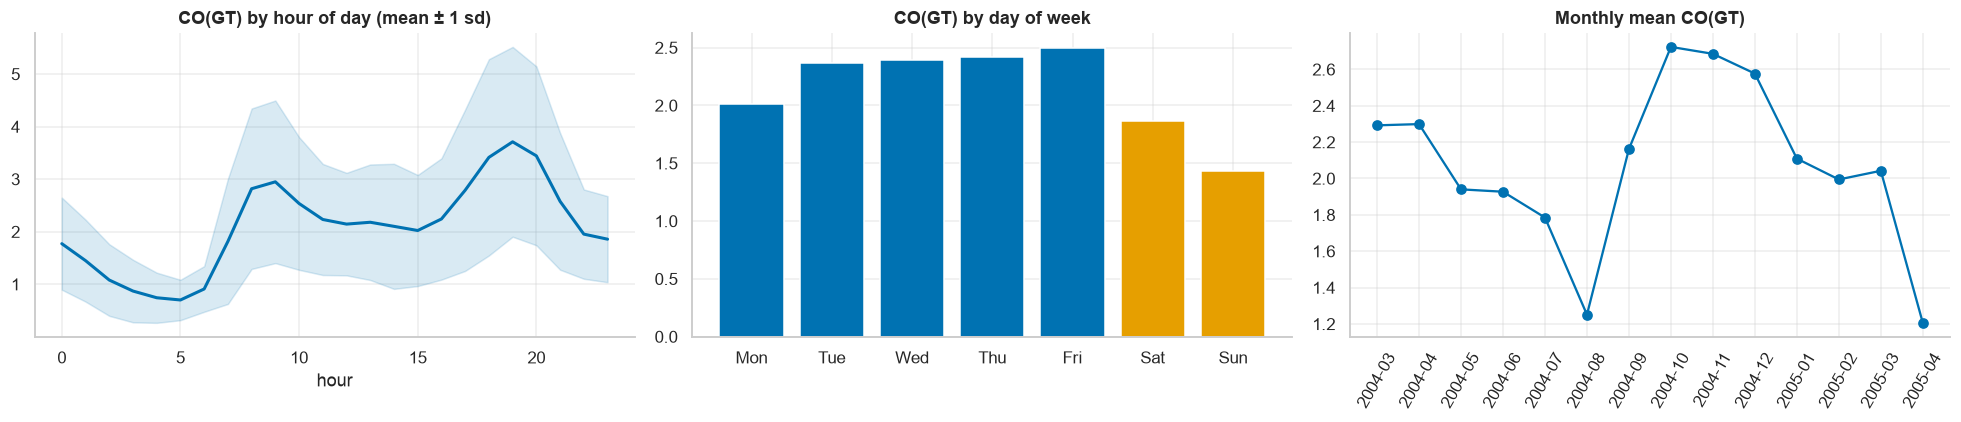

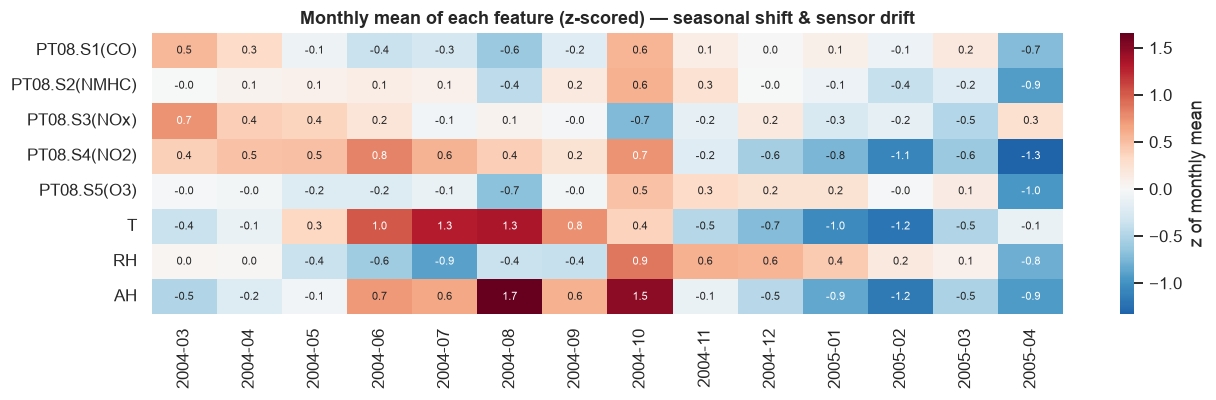

lag (h),1,2,3,6,12,24,48
autocorr,0.831,0.595,0.405,0.136,0.137,0.521,0.282


In [17]:
d = data.copy(); d["hour"] = d.index.hour; d["dow"] = d.index.dayofweek; d["month"] = d.index.to_period("M")
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
h = d.groupby("hour")[TARGET].agg(["mean", "std"]); ax[0].plot(h.index, h["mean"], color=BLUE, lw=2)
ax[0].fill_between(h.index, h["mean"] - h["std"], h["mean"] + h["std"], color=BLUE, alpha=.15); ax[0].set_title("CO(GT) by hour of day (mean ± 1 sd)"); ax[0].set_xlabel("hour")
wd = d.groupby("dow")[TARGET].mean(); ax[1].bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], wd.values, color=[BLUE]*5 + [ORANGE]*2); ax[1].set_title("CO(GT) by day of week")
mo = d.groupby("month")[TARGET].mean(); ax[2].plot(mo.index.astype(str), mo.values, marker="o", color=BLUE); ax[2].set_title("Monthly mean CO(GT)"); ax[2].tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()

# Sensor drift / seasonal shift: monthly mean of each (z-scored) feature
mz = (d[FEATURES].groupby(d["month"]).mean() - X.mean()) / X.std()
plt.figure(figsize=(12, 3.8)); sns.heatmap(mz.T, cmap="RdBu_r", center=0, annot=True, fmt=".1f", annot_kws={"size": 7}, cbar_kws={"label": "z of monthly mean"})
plt.title("Monthly mean of each feature (z-scored) — seasonal shift & sensor drift"); plt.xlabel(""); plt.tight_layout(); plt.show()

# Autocorrelation of the target: how dependent are neighbouring hours?
ac = [y.autocorr(l) for l in (1, 2, 3, 6, 12, 24, 48)]
display(pd.DataFrame({"lag (h)": (1, 2, 3, 6, 12, 24, 48), "autocorr": ac}).set_index("lag (h)").T)

**Observations.**
- Clear **diurnal cycle** (peaks ≈ 2.9 mg/m³ at 09 h and ≈ 3.7 at 19 h, night minimum ≈ 0.7 at 05 h) and a **weekend dip** (Sat ≈ 1.9, Sun ≈ 1.4 vs ≈ 2.4 on weekdays) → CO is traffic-driven. The brief restricts predictors to sensors + weather; the sensors implicitly carry the diurnal signal, so we do **not** add hour/day features (a possible extension).
- **Seasonality & drift**: monthly mean CO is highest in **Oct–Dec (≈ 2.6–2.7)** and lowest in **Aug (≈ 1.25, holiday period)**; `T` swings from ≈ 30 °C (Aug) to ≈ 7 °C (Feb). The `PT08.S4(NO2)` sensor mean falls steadily from ≈ 1,600–1,700 (spring/summer 2004) to ≈ 1,000–1,200 (winter 2005) — a mix of seasonal effect and metal-oxide sensor drift, which matters for any out-of-time evaluation.
- **Strong autocorrelation** (lag-1 ≈ 0.83, lag-24 ≈ 0.52): neighbouring hours are near duplicates. A *random* split therefore yields a test set interleaved with training hours (optimistic, "interpolation" scores), whereas a *chronological* split measures true forecasting/generalisation to a new season. Evaluated in §1.11.

### 1.11 Train/test split strategy — random vs. chronological

In [18]:
# What would a chronological 80/20 split look like?  (first 80% of time -> train, last 20% -> test)
cut = int(len(data) * .8); tr_t, te_t = data.iloc[:cut], data.iloc[cut:]
print(f"Chronological split: train {tr_t.index.min():%d %b %Y} -> {tr_t.index.max():%d %b %Y} | test {te_t.index.min():%d %b %Y} -> {te_t.index.max():%d %b %Y}")
cmp = pd.DataFrame({"train mean": tr_t[FEATURES + [TARGET]].mean(), "test mean": te_t[FEATURES + [TARGET]].mean()})
cmp["shift (in train std)"] = (cmp["test mean"] - cmp["train mean"]) / tr_t[FEATURES + [TARGET]].std()
display(cmp)
ks = {c: stats.ks_2samp(tr_t[c], te_t[c]).statistic for c in FEATURES + [TARGET]}
print("KS statistic train-vs-test (chronological):", {k: round(v, 2) for k, v in ks.items()})

Chronological split: train 10 Mar 2004 -> 28 Jan 2005 | test 28 Jan 2005 -> 04 Apr 2005


,train mean,test mean,shift (in train std)
PT08.S1(CO),"1,112.152","1,104.295",-0.035
PT08.S2(NMHC),970.195,855.228,-0.433
PT08.S3(NOx),842.590,764.251,-0.300
PT08.S4(NO2),"1,523.574","1,129.521",-1.220
PT08.S5(O3),"1,047.547","1,027.378",-0.051
T,19.556,10.631,-1.049
RH,48.894,49.724,0.047
AH,1.076,0.645,-1.134
CO(GT),2.175,1.950,-0.154


KS statistic train-vs-test (chronological): {'PT08.S1(CO)': np.float64(0.04), 'PT08.S2(NMHC)': np.float64(0.2), 'PT08.S3(NOx)': np.float64(0.14), 'PT08.S4(NO2)': np.float64(0.53), 'PT08.S5(O3)': np.float64(0.07), 'T': np.float64(0.43), 'RH': np.float64(0.05), 'AH': np.float64(0.52), 'CO(GT)': np.float64(0.09)}


**Decision.** A chronological split trains on Mar 2004 – Jan 2005 (including the hot summer) and tests on the colder, drier late-Jan – Apr 2005 period, creating a large **covariate shift**: `T` −1.0 sd, `AH` −1.1 sd, `PT08.S4` −1.2 sd (KS statistics ≈ 0.4–0.5), while CO itself shifts only −0.15 sd. Such a test would mostly measure season extrapolation rather than model quality, and the polynomial/tree comparison the assignment asks for would be dominated by that shift.

The assignment simply specifies an **80/20 train/test split**, so we use a **shuffled, target-stratified 80/20 split** (`random_state=42`) as the primary protocol. We state its limitation openly: because of hourly autocorrelation, test scores will be somewhat optimistic relative to true forecasting. The chronological split above is kept as a documented *robustness check* option for the Discussion.

### 1.12 Final preprocessing: stratified 80/20 split → scaling (fit on train only)

In [19]:
X_all, y_all = data[FEATURES], data[TARGET]
strata = pd.cut(y_all, bins=bands_edges, labels=bands_labels, right=False)      # regimes from §1.6

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=SEED, shuffle=True, stratify=strata)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}  |  test share = {len(X_test)/len(X_all):.1%}")

# Standardisation: statistics learned ONLY from the training set (no test-set leakage), then applied to both
scaler = StandardScaler().fit(X_train)
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=FEATURES, index=X_train.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=FEATURES, index=X_test.index)

chk = pd.DataFrame({"train mean": X_train_s.mean(), "train std": X_train_s.std(ddof=0),
                    "test mean": X_test_s.mean(), "test std": X_test_s.std(ddof=0)})
display(chk)
assert np.allclose(X_train_s.mean(), 0, atol=1e-9) and np.allclose(X_train_s.std(ddof=0), 1)

Train: (5875, 8)  |  Test: (1469, 8)  |  test share = 20.0%


,train mean,train std,test mean,test std
PT08.S1(CO),-0.000,1.000,0.003,1.004
PT08.S2(NMHC),0.000,1.000,-0.023,0.980
PT08.S3(NOx),0.000,1.000,0.014,1.009
PT08.S4(NO2),-0.000,1.000,-0.004,0.985
PT08.S5(O3),0.000,1.000,-0.004,1.008
T,-0.000,1.000,0.011,1.018
RH,-0.000,1.000,-0.008,1.010
AH,-0.000,1.000,0.000,0.987


,train_n,test_n,train_%,test_%
CO(GT),,,,
Low (<1.5),2256,564,38.400,38.393
Moderate (1.5-3),2246,562,38.230,38.257
High (3-5),1095,274,18.638,18.652
Very high (>=5),278,69,4.732,4.697


,count,mean,std,min,25%,50%,75%,max
train,"5,875.000",2.132,1.440,0.100,1.100,1.800,2.850,11.900
test,"1,469.000",2.120,1.424,0.100,1.000,1.800,2.800,8.700


KS test on target train vs test: stat=0.015, p=0.94


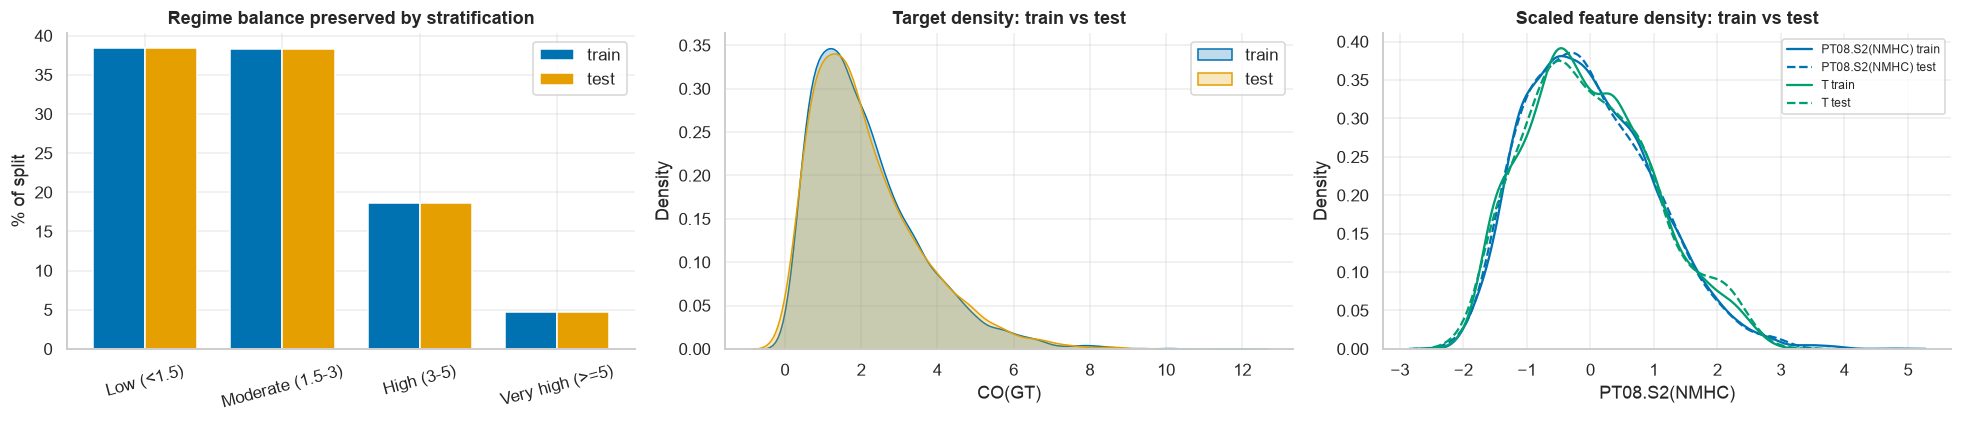

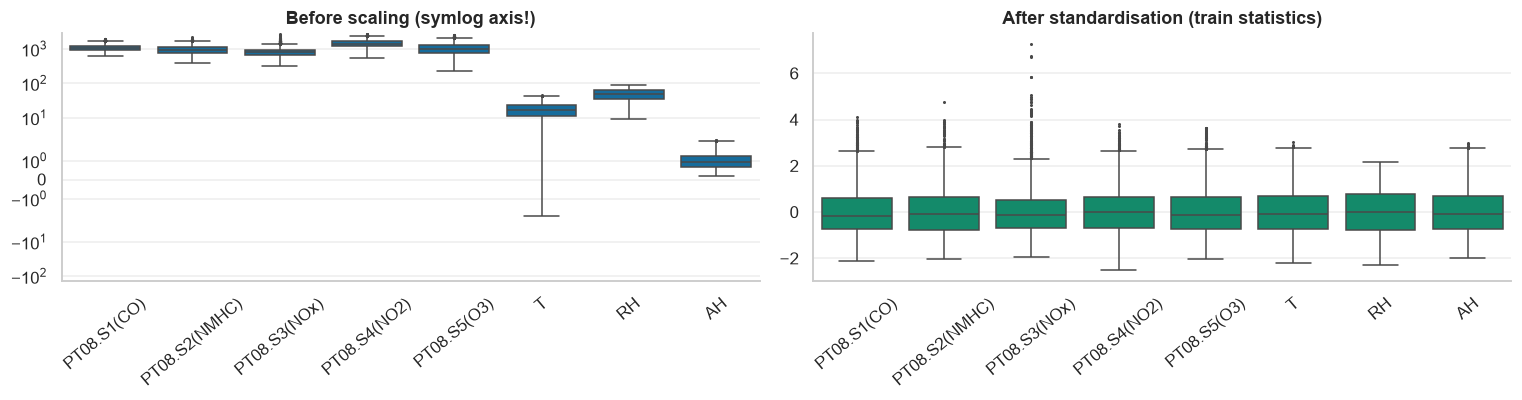

In [20]:
# Verify the split is representative: class balance, target distribution, feature distributions
sb = pd.DataFrame({"train_n": pd.cut(y_train, bands_edges, labels=bands_labels, right=False).value_counts().sort_index(),
                   "test_n":  pd.cut(y_test,  bands_edges, labels=bands_labels, right=False).value_counts().sort_index()})
sb["train_%"] = sb["train_n"] / sb["train_n"].sum() * 100; sb["test_%"] = sb["test_n"] / sb["test_n"].sum() * 100
display(sb)

tt = pd.DataFrame({"train": y_train.describe(), "test": y_test.describe()}); display(tt.T)
print(f"KS test on target train vs test: stat={stats.ks_2samp(y_train, y_test).statistic:.3f}, p={stats.ks_2samp(y_train, y_test).pvalue:.2f}")

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
w = .38; xi = np.arange(len(sb)); ax[0].bar(xi - w/2, sb["train_%"], w, color=BLUE, label="train"); ax[0].bar(xi + w/2, sb["test_%"], w, color=ORANGE, label="test")
ax[0].set_xticks(xi); ax[0].set_xticklabels(sb.index, rotation=15); ax[0].set_ylabel("% of split"); ax[0].set_title("Regime balance preserved by stratification"); ax[0].legend()
sns.kdeplot(y_train, ax=ax[1], color=BLUE, label="train", fill=True, alpha=.25); sns.kdeplot(y_test, ax=ax[1], color=ORANGE, label="test", fill=True, alpha=.25)
ax[1].set_title("Target density: train vs test"); ax[1].legend()
for c, col in zip(["PT08.S2(NMHC)", "T"], [BLUE, GREEN]):
    sns.kdeplot(X_train_s[c], ax=ax[2], color=col, label=f"{c} train"); sns.kdeplot(X_test_s[c], ax=ax[2], color=col, ls="--", label=f"{c} test")
ax[2].set_title("Scaled feature density: train vs test"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

# Scaling effect
fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
sns.boxplot(data=X_train, ax=ax[0], color=BLUE, fliersize=1); ax[0].set_yscale("symlog"); ax[0].set_title("Before scaling (symlog axis!)"); ax[0].tick_params(axis="x", rotation=40)
sns.boxplot(data=X_train_s, ax=ax[1], color=GREEN, fliersize=1); ax[1].set_title("After standardisation (train statistics)"); ax[1].tick_params(axis="x", rotation=40)
plt.tight_layout(); plt.show()

**Scaling / normalisation / regularisation plan — decisions made from the EDA**

| Aspect | Decision | Evidence from EDA |
|---|---|---|
| Missing sentinel | `-200 → NaN` | min = −200 in every column |
| Missing rows | drop outage rows & rows without target; **no imputation** | 366 whole-row outages; multi-day target gaps; target must not be imputed |
| Dropped column | `NMHC(GT)` | ~90 % missing |
| Target | `CO(GT)`, original units (mg/m³) | skewed but interpretable RMSE; log is an optional experiment |
| Feature scaling | **Z-score standardisation, fitted on train only** | scale mismatch of up to ~10³×; needed for gradient-descent "epochs" & polynomial terms; harmless for trees |
| Normalisation (min-max) | not used | outliers would squash the bulk of the data; z-score is preferred |
| Outliers | kept | real pollution episodes, no impossible values |
| Split | 80/20 shuffled, **stratified** on CO regimes, `seed=42` | class imbalance; stratification keeps test representative |
| Regularisation | none by default; **Ridge/L2 held in reserve** for polynomial regression; trees controlled via `max_depth` | VIF shows strong multicollinearity; high-degree polynomials may overfit |
| Polynomial degree | to be chosen by **validation/CV on the training set only** | non-linearity observed, but test set stays untouched |
| Hand-off to Stage 2 | `X_train_s, X_test_s, y_train, y_test, FEATURES, TARGET, scaler` | — |

In [21]:
# Final hand-off summary for the model-training stage
summary = pd.DataFrame({
    "object": ["X_train_s", "X_test_s", "y_train", "y_test"],
    "shape": [X_train_s.shape, X_test_s.shape, y_train.shape, y_test.shape],
    "NaNs": [int(X_train_s.isna().sum().sum()), int(X_test_s.isna().sum().sum()), int(y_train.isna().sum()), int(y_test.isna().sum())],
    "scaled": [True, True, False, False]}).set_index("object")
display(summary)
print("Features :", FEATURES); print("Target   :", TARGET, "(mg/m³)")
print("Index overlap train/test:", len(set(X_train.index) & set(X_test.index)), "(must be 0)")
assert len(set(X_train.index) & set(X_test.index)) == 0

,shape,NaNs,scaled
object,,,
X_train_s,"(5875, 8)",0,True
X_test_s,"(1469, 8)",0,True
y_train,"(5875,)",0,False
y_test,"(1469,)",0,False


Features : ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
Target   : CO(GT) (mg/m³)
Index overlap train/test: 0 (must be 0)


✅ **Stage 1 complete.** The data are cleaned, the target and features are fixed, the scaler is fitted on the training data only, and the stratified train/test split is verified.

---
## Stage 2 — Model Training

**Design principles carried over from Stage 1**

| Stage 1 finding | Consequence for training |
|---|---|
| Hourly data are strongly autocorrelated (lag-1 ≈ 0.83) | Hyper-parameters (polynomial degree, learning rate, tree depth) are chosen with **group-aware 5-fold CV on the training set** (whole calendar weeks are kept together), never on the test set. |
| Features are collinear (VIF > 10) | Ridge (L2) is studied as an ablation for the polynomial model; coefficients are reported with bootstrap CIs. |
| Features differ ~10³× in scale | Gradient descent is run on standardised inputs; an ablation demonstrates why. |
| CO is right-skewed, ~8:1 regime imbalance | Besides MSE/RMSE/R² we also store residuals and **per-regime errors**; log-target is tested as an ablation. |
| Shuffled split is optimistic | An **out-of-time** (chronological) robustness check is run for the final models. |

**What this stage produces for later stages** (all kept in memory): the model registry `RESULTS`, fitted models `FITTED`, train/test predictions `PRED`, per-epoch histories `HISTORY`, the tree depth sweep `TREE_SWEEP`, feature-importance tables, learning curves and all ablation tables.

### 2.0 Setup, from-scratch metrics and the model registry

In [22]:
import time
from itertools import combinations_with_replacement
import matplotlib
import sklearn
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GroupKFold, cross_validate, learning_curve, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

print({m.__name__: m.__version__ for m in (np, pd, sklearn)})

# ---- evaluation metrics implemented from scratch (verified against sklearn below) ----
def mse(y_true, y_pred):  return float(np.mean((np.asarray(y_true, float) - np.asarray(y_pred, float)) ** 2))
def rmse(y_true, y_pred): return float(np.sqrt(mse(y_true, y_pred)))
def mae(y_true, y_pred):  return float(np.mean(np.abs(np.asarray(y_true, float) - np.asarray(y_pred, float))))
def r2(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return float(1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2))
def regression_metrics(y_true, y_pred):
    return {"mse": mse(y_true, y_pred), "rmse": rmse(y_true, y_pred), "r2": r2(y_true, y_pred), "mae": mae(y_true, y_pred)}

_a, _b = y_test.values, y_test.values * 0.9 + 0.1
assert np.isclose(mse(_a, _b), mean_squared_error(_a, _b)) and np.isclose(r2(_a, _b), r2_score(_a, _b)) and np.isclose(mae(_a, _b), mean_absolute_error(_a, _b))
print("From-scratch MSE / RMSE / R² / MAE match sklearn.metrics ✔")

# ---- registries shared with Stages 3-6 ----
RESULTS, FITTED, PRED, HISTORY = {}, {}, {}, {}

def timed_fit(model, X, y, **kw):
    t = time.perf_counter(); model.fit(X, y, **kw); return model, time.perf_counter() - t

def evaluate(name, model, family, config, fit_time, complexity=None):
    """Score a fitted model on the scaled train/test sets and store everything needed later."""
    p_tr, p_te = np.asarray(model.predict(X_train_s)), np.asarray(model.predict(X_test_s))
    row = {"model": name, "family": family, "config": config, "complexity": complexity, "fit_time_s": fit_time}
    for split, yt, yp in (("train", y_train, p_tr), ("test", y_test, p_te)):
        row.update({f"{split}_{k}": v for k, v in regression_metrics(yt, yp).items()})
    row["rmse_gap (test-train)"] = row["test_rmse"] - row["train_rmse"]
    RESULTS[name] = row; FITTED[name] = model; PRED[name] = {"train": p_tr, "test": p_te}
    return row

def epochs_to_tol(hist, col="train_mse", tol=0.01):
    """First epoch at which the loss is within `tol` (relative) of its final value."""
    h = hist[col].values; ok = np.where(h <= h[-1] * (1 + tol))[0]
    return int(hist["epoch"].values[ok[0]]) if len(ok) else None

{'numpy': '2.4.6', 'pandas': '3.0.6', 'sklearn': '1.9.1'}
From-scratch MSE / RMSE / R² / MAE match sklearn.metrics ✔


### 2.1 Validation protocol (used for *every* modelling choice)
The test set is touched only to **report** results. All selection (learning rate, polynomial degree, ridge strength, tree depth/leaf size, ablations) uses 5-fold cross-validation **within the training set**. Because neighbouring hours are near-duplicates, folds are formed from **whole calendar weeks** (`GroupKFold`), so a validation fold never contains hours adjacent to training hours. This gives a more honest (more pessimistic) estimate than a plain shuffled K-fold.

In [23]:
groups = pd.factorize(X_train.index.to_period("W").astype(str))[0]       # one group per calendar week
cv = GroupKFold(n_splits=5)
folds = list(cv.split(X_train_s, y_train, groups))

fold_tbl = pd.DataFrame([{"fold": i + 1, "train_n": len(tr), "val_n": len(va), "val_weeks": len(np.unique(groups[va])),
                          "val_CO_mean": y_train.values[va].mean(), "val_CO_std": y_train.values[va].std()}
                         for i, (tr, va) in enumerate(folds)]).set_index("fold")
display(fold_tbl)
assert all(set(groups[tr]).isdisjoint(groups[va]) for tr, va in folds)
print(f"{len(np.unique(groups))} weekly groups; no week appears in both a training and a validation fold ✔")

def cv_eval(est, X=None, y=None, **kw):
    """Group-CV summary of an sklearn-compatible estimator (RMSE / R², mean ± sd over folds)."""
    X = X_train_s if X is None else X; y = y_train if y is None else y
    r = cross_validate(est, X, y, groups=groups, cv=cv, return_train_score=True,
                       scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"}, **kw)
    return {"cv_rmse": -r["test_rmse"].mean(), "cv_rmse_sd": r["test_rmse"].std(), "cv_r2": r["test_r2"].mean(),
            "cv_train_rmse": -r["train_rmse"].mean()}

,train_n,val_n,val_weeks,val_CO_mean,val_CO_std
fold,,,,,
1,4706,1169,11,2.068,1.354
2,4704,1171,11,2.019,1.369
3,4695,1180,12,2.045,1.316
4,4705,1170,11,2.186,1.512
5,4690,1185,12,2.342,1.600


57 weekly groups; no week appears in both a training and a validation fold ✔


**Observation.** 57 weekly groups give five folds of ~1,170 validation hours (11–12 weeks each) with no week shared between training and validation. Fold mean CO ranges from 2.02 to 2.34 mg/m³, so folds are reasonably comparable, and the spread of fold scores (reported as ± sd below) honestly reflects seasonal variation.

### 2.2 Linear regression from scratch (NumPy only)
One estimator, three solvers, all minimising the same objective  ‖y − Xθ‖² / n + (α/n)·‖w‖² (the intercept is never penalised; α = 0 is ordinary least squares and α is directly comparable with scikit-learn's `Ridge(alpha)`):

* `solver="normal"` – exact least-squares solution (`np.linalg.lstsq`, SVD-based and therefore stable under collinearity; with α > 0 the ridge normal equations are solved);
* `solver="gd"` – batch gradient descent, `θ ← θ − lr·∇`, with **per-epoch recording** of train/test MSE, RMSE and R² (needed for the *metric-vs-epoch* plots);
* `solver="adam"` – Adam, used later for the polynomial model where plain GD is badly conditioned.

The class follows the scikit-learn `fit/predict` API purely so that it can plug into the same CV / pipeline tooling – **no scikit-learn algorithm is used inside it**.

In [24]:
class LinearRegressionScratch(RegressorMixin, BaseEstimator):
    def __init__(self, solver="normal", alpha=0.0, lr=0.1, epochs=1000, beta1=0.9, beta2=0.999, track=False):
        self.solver, self.alpha, self.lr, self.epochs = solver, alpha, lr, epochs
        self.beta1, self.beta2, self.track = beta1, beta2, track

    @staticmethod
    def _design(X): return np.c_[np.ones(len(X)), np.asarray(X, float)]

    def _grad(self, Xb, y, theta):
        g = (2.0 / len(y)) * Xb.T @ (Xb @ theta - y)
        g[1:] += (2.0 * self.alpha / len(y)) * theta[1:]            # L2 term, intercept excluded
        return g

    def fit(self, X, y, eval_sets=None):
        Xb, y = self._design(X), np.asarray(y, float).ravel(); d = Xb.shape[1]
        if self.solver == "normal":
            if self.alpha == 0:
                theta = np.linalg.lstsq(Xb, y, rcond=None)[0]
            else:
                P = self.alpha * np.eye(d); P[0, 0] = 0
                theta = np.linalg.solve(Xb.T @ Xb + P, Xb.T @ y)
        elif self.solver in ("gd", "adam"):
            theta = self._descend(Xb, y, eval_sets)
        else:
            raise ValueError(self.solver)
        self.theta_, self.intercept_, self.coef_ = theta, theta[0], theta[1:]
        return self

    def _descend(self, Xb, y, eval_sets):
        theta, m, v = np.zeros(Xb.shape[1]), np.zeros(Xb.shape[1]), np.zeros(Xb.shape[1])
        ev = {k: (self._design(Xe), np.asarray(ye, float).ravel()) for k, (Xe, ye) in (eval_sets or {}).items()}
        rows, self.diverged_ = [], False

        def record(ep):
            r = {"epoch": ep}
            for nm, (A, t) in {"train": (Xb, y), **ev}.items():
                p = A @ theta
                r[f"{nm}_mse"], r[f"{nm}_rmse"], r[f"{nm}_r2"] = mse(t, p), rmse(t, p), r2(t, p)
            rows.append(r)

        with np.errstate(all="ignore"):
            if self.track: record(0)
            for t in range(1, self.epochs + 1):
                g = self._grad(Xb, y, theta)
                if self.solver == "gd":
                    theta = theta - self.lr * g
                else:                                                    # Adam (bias-corrected)
                    m = self.beta1 * m + (1 - self.beta1) * g
                    v = self.beta2 * v + (1 - self.beta2) * g ** 2
                    theta = theta - self.lr * (m / (1 - self.beta1 ** t)) / (np.sqrt(v / (1 - self.beta2 ** t)) + 1e-8)
                if not np.all(np.isfinite(theta)) or np.abs(theta).max() > 1e12:
                    self.diverged_ = True; break
                if self.track: record(t)
        self.history_ = pd.DataFrame(rows) if self.track else None
        return theta

    def predict(self, X): return self._design(X) @ self.theta_


# ---- unit tests of the implementation ----
# (1) analytic gradient vs central finite differences
rs = np.random.default_rng(0); Xt, yt_, th = rs.normal(size=(60, 4)), rs.normal(size=60), rs.normal(size=5)
lm = LinearRegressionScratch(alpha=0.7); Xb_t = lm._design(Xt)
loss = lambda t: np.mean((Xb_t @ t - yt_) ** 2) + 0.7 / len(yt_) * np.sum(t[1:] ** 2)
num = np.array([(loss(th + 1e-6 * e) - loss(th - 1e-6 * e)) / 2e-6 for e in np.eye(5)])
print("gradient check, max |analytic - numeric| =", f"{np.abs(lm._grad(Xb_t, yt_, th) - num).max():.2e}")
assert np.allclose(lm._grad(Xb_t, yt_, th), num, atol=1e-6)
# (2) recovers known coefficients on noiseless synthetic data
w_true = np.array([1.5, -2.0, 0.5, 3.0]); ys = 4.0 + Xt @ w_true
assert np.allclose(LinearRegressionScratch().fit(Xt, ys).theta_, np.r_[4.0, w_true])
assert np.allclose(LinearRegressionScratch(solver="gd", lr=0.1, epochs=2000).fit(Xt, ys).theta_, np.r_[4.0, w_true], atol=1e-4)
print("Closed form and GD both recover the true coefficients on synthetic data ✔")

gradient check, max |analytic - numeric| = 5.32e-09
Closed form and GD both recover the true coefficients on synthetic data ✔


#### 2.2.1 Choosing the gradient-descent learning rate (train loss only)

λ_max(XᵀX/n) = 4.21  ->  theoretical stability limit lr < 0.238


,diverged,final_train_rmse,epochs_to_1%,||theta - theta_OLS||
lr,,,,
0.001,False,0.618,990.000,1.183
0.010,False,0.492,884.000,0.545
0.050,False,0.480,405.000,0.024
0.100,False,0.480,203.000,0.001
0.150,False,0.480,135.000,0.000
0.250,True,NaN,NaN,NaN


Selected learning rate: 0.15


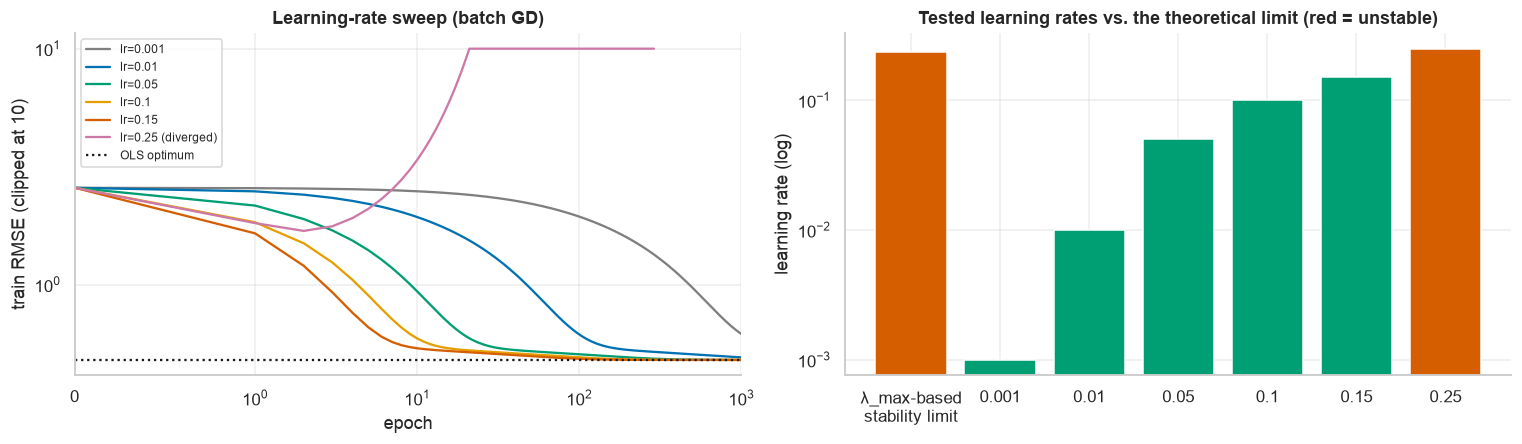

In [25]:
Xb_all = LinearRegressionScratch._design(X_train_s)
lam_max = np.linalg.eigvalsh(Xb_all.T @ Xb_all / len(Xb_all)).max()
lr_stable = 2.0 / (2.0 * lam_max)                       # GD on MSE is stable iff lr < 2/L, L = 2·λ_max(XᵀX/n)
print(f"λ_max(XᵀX/n) = {lam_max:.2f}  ->  theoretical stability limit lr < {lr_stable:.3f}")

EPOCHS_LIN = 1000
theta_opt = LinearRegressionScratch().fit(X_train_s, y_train).theta_
lr_grid = [0.001, 0.01, 0.05, 0.1, 0.15, 0.25]
lr_rows, lr_hist = [], {}
for lr in lr_grid:
    m_ = LinearRegressionScratch(solver="gd", lr=lr, epochs=EPOCHS_LIN, track=True).fit(X_train_s, y_train)
    h = m_.history_; lr_hist[lr] = h
    lr_rows.append({"lr": lr, "diverged": m_.diverged_, "final_train_rmse": h["train_rmse"].iloc[-1] if not m_.diverged_ else np.nan,
                    "epochs_to_1%": epochs_to_tol(h) if not m_.diverged_ else None,
                    "||theta - theta_OLS||": np.linalg.norm(m_.theta_ - theta_opt) if not m_.diverged_ else np.nan})
lr_tbl = pd.DataFrame(lr_rows).set_index("lr"); display(lr_tbl)

ok = lr_tbl[(~lr_tbl["diverged"]) & (lr_tbl["||theta - theta_OLS||"] < 1e-3)]
LR_LIN = float(ok["epochs_to_1%"].astype(float).idxmin()); print("Selected learning rate:", LR_LIN)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for lr, c in zip(lr_grid, [GREY, BLUE, GREEN, ORANGE, RED, "#CC79A7"]):
    h = lr_hist[lr]; ax[0].plot(h["epoch"], h["train_rmse"].clip(upper=10), color=c, label=f"lr={lr}" + (" (diverged)" if h["train_rmse"].iloc[-1] > 1e3 or len(h) < EPOCHS_LIN else ""))
ax[0].axhline(rmse(y_train, X_train_s.values @ theta_opt[1:] + theta_opt[0]), color="k", ls=":", label="OLS optimum")
ax[0].set_xscale("symlog", linthresh=1); ax[0].set_xlim(0, EPOCHS_LIN); ax[0].set_yscale("log"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("train RMSE (clipped at 10)")
ax[0].set_title("Learning-rate sweep (batch GD)"); ax[0].legend(fontsize=8)
ax[1].bar(["λ_max-based\nstability limit"] + [str(l) for l in lr_grid], [lr_stable] + lr_grid, color=[RED] + [GREEN if l < lr_stable else RED for l in lr_grid])
ax[1].set_yscale("log"); ax[1].set_title("Tested learning rates vs. the theoretical limit (red = unstable)"); ax[1].set_ylabel("learning rate (log)")
plt.tight_layout(); plt.show()

**Observations.**
- The theoretical stability limit for plain gradient descent is **lr < 0.238** (from the largest eigenvalue of XᵀX/n); the experiment agrees: `lr = 0.25` diverges, `0.15` is the fastest stable rate.
- Small rates are simply too slow: `lr = 0.001` has not converged after 1,000 epochs (RMSE 0.618 vs. optimum 0.480).
- **Selected `lr = 0.15`**: it reaches within 1 % of the optimum in ~135 epochs and ends within 1e-3 of the OLS coefficients. The choice uses *training loss only*.

#### 2.2.2 Final linear models: closed form, gradient descent (with per-epoch tracking) and scikit-learn

In [26]:
N_LIN_NE, N_LIN_GD, N_LIN_SK = "Linear | scratch (normal eq.)", "Linear | scratch (GD)", "Linear | sklearn"
N_MEAN = "Baseline | mean predictor"

m, t = timed_fit(LinearRegressionScratch(solver="normal"), X_train_s, y_train); evaluate(N_LIN_NE, m, "Linear", "OLS, lstsq", t, complexity=len(FEATURES) + 1)
m, t = timed_fit(LinearRegressionScratch(solver="gd", lr=LR_LIN, epochs=EPOCHS_LIN, track=True), X_train_s, y_train,
                 eval_sets={"test": (X_test_s, y_test)})
evaluate(N_LIN_GD, m, "Linear", f"batch GD, lr={LR_LIN}, {EPOCHS_LIN} epochs", t, complexity=len(FEATURES) + 1); HISTORY[N_LIN_GD] = m.history_
m, t = timed_fit(LinearRegression(), X_train_s, y_train); evaluate(N_LIN_SK, m, "Linear", "sklearn.LinearRegression", t, complexity=len(FEATURES) + 1)
m, t = timed_fit(DummyRegressor(strategy="mean"), X_train_s, y_train); evaluate(N_MEAN, m, "Baseline", "predict train mean", t, complexity=1)

def compare_pair(a, b):
    pa, pb = PRED[a]["test"], PRED[b]["test"]
    return {"max |Δ test prediction|": np.abs(pa - pb).max(), "corr(test predictions)": np.corrcoef(pa, pb)[0, 1],
            "Δ test RMSE": abs(RESULTS[a]["test_rmse"] - RESULTS[b]["test_rmse"]), "Δ test R²": abs(RESULTS[a]["test_r2"] - RESULTS[b]["test_r2"])}

cols = ["train_mse", "train_rmse", "train_r2", "test_mse", "test_rmse", "test_r2"]
display(pd.DataFrame(RESULTS).T.loc[[N_MEAN, N_LIN_NE, N_LIN_GD, N_LIN_SK], ["config"] + cols])

coef_cmp = pd.DataFrame({"scratch normal eq.": np.r_[FITTED[N_LIN_NE].intercept_, FITTED[N_LIN_NE].coef_],
                         "scratch GD": np.r_[FITTED[N_LIN_GD].intercept_, FITTED[N_LIN_GD].coef_],
                         "sklearn": np.r_[FITTED[N_LIN_SK].intercept_, FITTED[N_LIN_SK].coef_]}, index=["intercept"] + FEATURES)
coef_cmp["|NE - sklearn|"] = (coef_cmp["scratch normal eq."] - coef_cmp["sklearn"]).abs()
coef_cmp["|GD - sklearn|"] = (coef_cmp["scratch GD"] - coef_cmp["sklearn"]).abs()
display(coef_cmp)
display(pd.DataFrame({"scratch NE vs sklearn": compare_pair(N_LIN_NE, N_LIN_SK), "scratch GD vs sklearn": compare_pair(N_LIN_GD, N_LIN_SK)}).T)
assert np.allclose(coef_cmp["scratch normal eq."], coef_cmp["sklearn"], atol=1e-8)
h = HISTORY[N_LIN_GD]; print(f"GD: within 1% of final train loss after {epochs_to_tol(h)} epochs; final train RMSE {h['train_rmse'].iloc[-1]:.5f}")

,config,train_mse,train_rmse,train_r2,test_mse,test_rmse,test_r2
Baseline | mean predictor,predict train mean,2.073,1.440,0.000,2.025,1.423,-0.000
Linear | scratch (normal eq.),"OLS, lstsq",0.230,0.480,0.889,0.243,0.493,0.880
Linear | scratch (GD),"batch GD, lr=0.15, 1000 epochs",0.230,0.480,0.889,0.243,0.493,0.880
Linear | sklearn,sklearn.LinearRegression,0.230,0.480,0.889,0.243,0.493,0.880


,scratch normal eq.,scratch GD,sklearn,|NE - sklearn|,|GD - sklearn|
intercept,2.132,2.132,2.132,0.000,0.000
PT08.S1(CO),0.394,0.394,0.394,0.000,0.000
PT08.S2(NMHC),1.366,1.366,1.366,0.000,0.000
PT08.S3(NOx),0.199,0.199,0.199,0.000,0.000
PT08.S4(NO2),-0.174,-0.174,-0.174,0.000,0.000
PT08.S5(O3),-0.077,-0.077,-0.077,0.000,0.000
T,-0.244,-0.244,-0.244,0.000,0.000
RH,-0.030,-0.030,-0.030,0.000,0.000
AH,0.087,0.087,0.087,0.000,0.000


,max |Δ test prediction|,corr(test predictions),Δ test RMSE,Δ test R²
scratch NE vs sklearn,0.000,1.000,0.000,0.000
scratch GD vs sklearn,0.000,1.000,0.000,0.000


GD: within 1% of final train loss after 135 epochs; final train RMSE 0.47988


**Observations — from scratch vs. scikit-learn (linear).**
- The closed-form solution, the gradient-descent solution and `sklearn.LinearRegression` give the **same coefficients (agreement to < 1e-8 for the closed form)** and the same predictions (max difference ≈ 0 at the 3-decimal level shown), hence identical metrics: **train RMSE 0.480 / R² 0.889, test RMSE 0.493 / R² 0.880**.
- The mean predictor scores R² ≈ 0 (test RMSE 1.423), so the sensors explain ~88 % of the variance linearly.
- Standardised coefficients already show the dominant sensor: `PT08.S2(NMHC)` (+1.37) ≫ `PT08.S1(CO)` (+0.39) > `T` (−0.24) > `PT08.S3` (+0.20).
- The train–test gap is tiny (RMSE +0.013): the linear model is **bias-limited, not variance-limited**.

### 2.3 Polynomial regression from scratch
**Feature expansion** `PolynomialFeaturesScratch` builds every monomial of total degree 1…d (e.g. d=2: `x_i`, `x_i·x_j`, `x_i²`) and is verified against `sklearn.preprocessing.PolynomialFeatures`. Because polynomial columns have very different scales (and are highly collinear), the expanded matrix is re-standardised with **training-fold statistics** inside the estimator before the (closed-form or gradient-based) least-squares fit.

In [27]:
class PolynomialFeaturesScratch:
    """All monomials of total degree 1..d (no bias column); column order identical to sklearn's."""
    def __init__(self, degree): self.degree = degree
    def fit(self, X, y=None):
        self.n_features_ = np.asarray(X).shape[1]
        self.combos_ = [c for k in range(1, self.degree + 1) for c in combinations_with_replacement(range(self.n_features_), k)]
        return self
    def transform(self, X):
        X = np.asarray(X, float)
        return np.column_stack([np.prod(X[:, c], axis=1) for c in self.combos_])
    def feature_names(self, names):
        return ["*".join(names[i] for i in c) for c in self.combos_]


class PolyRegressionScratch(RegressorMixin, BaseEstimator):
    def __init__(self, degree=2, solver="normal", alpha=0.0, lr=0.05, epochs=2000, track=False):
        self.degree, self.solver, self.alpha, self.lr, self.epochs, self.track = degree, solver, alpha, lr, epochs, track
    def _expand(self, X): return (self.poly_.transform(X) - self.mu_) / self.sd_
    def fit(self, X, y, eval_sets=None):
        X = np.asarray(X, float); self.poly_ = PolynomialFeaturesScratch(self.degree).fit(X)
        P = self.poly_.transform(X); self.mu_, self.sd_ = P.mean(0), P.std(0); self.sd_[self.sd_ == 0] = 1.0
        ev = {k: (self._expand(Xe), ye) for k, (Xe, ye) in (eval_sets or {}).items()}
        self.lin_ = LinearRegressionScratch(self.solver, self.alpha, self.lr, self.epochs, track=self.track).fit((P - self.mu_) / self.sd_, y, ev)
        self.intercept_, self.coef_, self.history_ = self.lin_.intercept_, self.lin_.coef_, getattr(self.lin_, "history_", None)
        return self
    def predict(self, X): return self.lin_.predict(self._expand(np.asarray(X, float)))


# ---- verify the expansion against sklearn ----
for deg in (1, 2, 3):
    mine = PolynomialFeaturesScratch(deg).fit(X_train_s).transform(X_train_s)
    ref = PolynomialFeatures(deg, include_bias=False).fit_transform(X_train_s)
    assert mine.shape == ref.shape and np.allclose(mine, ref)
print("PolynomialFeaturesScratch == sklearn PolynomialFeatures for d = 1, 2, 3 ✔")
nfeat = {d: PolynomialFeaturesScratch(d).fit(X_train_s).transform(X_train_s[:5]).shape[1] for d in range(1, 7)}
display(pd.DataFrame({"degree": list(nfeat), "n_terms": list(nfeat.values()), "terms / training rows": [v / len(X_train_s) for v in nfeat.values()]}).set_index("degree").T)

PolynomialFeaturesScratch == sklearn PolynomialFeatures for d = 1, 2, 3 ✔


degree,1,2,3,4,5,6
n_terms,8.000,44.000,164.000,494.000,"1,286.000","3,002.000"
terms / training rows,0.001,0.007,0.028,0.084,0.219,0.511


#### 2.3.1 How the "appropriate" polynomial degree is obtained
The degree controls the bias/variance trade-off. We fit degrees 1–5 by closed-form least squares and score each with the **5-fold group CV** (training set only). We then use the **one-standard-error rule**: pick the *smallest* degree whose CV RMSE is within one standard error of the best — i.e. prefer the simpler model unless a more complex one is clearly better. The same expansion is also crossed with a Ridge strength α (an ablation addressing the multicollinearity found in Stage 1).

In [28]:
DEGREES = [1, 2, 3, 4, 5]
ALPHAS = [0, 1e-2, 1e-1, 1, 10, 100, 1e3, 1e4]            # alpha = 0 -> plain least squares (lstsq)
Xv, yv = X_train_s.values, y_train.values

def poly_cv_curve(degrees, alphas):
    """CV curve for polynomial (ridge) regression. The expansion is deterministic, so it is done once per degree;
    standardisation, fit and scoring are done per fold with training-fold statistics only (no leakage)."""
    rows = []
    for deg in degrees:
        P = PolynomialFeaturesScratch(deg).fit(Xv).transform(Xv)
        for k, (tr, va) in enumerate(folds):
            mu, sd = P[tr].mean(0), P[tr].std(0); sd[sd == 0] = 1
            A, B = (P[tr] - mu) / sd, (P[va] - mu) / sd
            ym = yv[tr].mean(); G, c = A.T @ A, A.T @ (yv[tr] - ym)       # centred columns -> intercept = mean(y)
            for a in alphas:
                w = np.linalg.lstsq(A, yv[tr] - ym, rcond=None)[0] if a == 0 else np.linalg.solve(G + a * np.eye(G.shape[0]), c)
                rows.append({"degree": deg, "alpha": a, "fold": k, "n_terms": P.shape[1],
                             "train_rmse": rmse(yv[tr], A @ w + ym), "val_rmse": rmse(yv[va], B @ w + ym), "val_r2": r2(yv[va], B @ w + ym)})
    return pd.DataFrame(rows)

t0 = time.perf_counter(); POLY_CV = poly_cv_curve(DEGREES, ALPHAS); print(f"degree x alpha CV finished in {time.perf_counter() - t0:.0f}s")
agg = POLY_CV.groupby(["degree", "alpha"]).agg(n_terms=("n_terms", "first"), train_rmse=("train_rmse", "mean"), cv_rmse=("val_rmse", "mean"),
                                               cv_rmse_sd=("val_rmse", "std"), cv_r2=("val_r2", "mean")).reset_index()
agg["cv_rmse_se"] = agg["cv_rmse_sd"] / np.sqrt(len(folds))

unreg = agg[agg["alpha"] == 0].set_index("degree")
best_d = unreg["cv_rmse"].idxmin(); thr = unreg.loc[best_d, "cv_rmse"] + unreg.loc[best_d, "cv_rmse_se"]
DEG_STAR = int(unreg[unreg["cv_rmse"] <= thr].index.min())
unreg = unreg.assign(selected=["<-- chosen (1-SE)" if d == DEG_STAR else ("best CV" if d == best_d else "") for d in unreg.index])
display(unreg[["n_terms", "train_rmse", "cv_rmse", "cv_rmse_sd", "cv_rmse_se", "cv_r2", "selected"]])
print(f"Best CV degree = {best_d}; 1-SE threshold = {thr:.4f}  ->  chosen degree = {DEG_STAR}")

best_row = agg.loc[agg["cv_rmse"].idxmin()]; DEG_R, ALPHA_R = int(best_row["degree"]), float(best_row["alpha"])
print(f"Best (degree, alpha) overall with Ridge: degree={DEG_R}, alpha={ALPHA_R:g}, CV RMSE={best_row['cv_rmse']:.4f}")

degree x alpha CV finished in 2s


,n_terms,train_rmse,cv_rmse,cv_rmse_sd,cv_rmse_se,cv_r2,selected
degree,,,,,,,
1,8,0.479,0.488,0.061,0.027,0.883,
2,44,0.407,0.453,0.054,0.024,0.899,<-- chosen (1-SE)
3,164,0.380,0.500,0.061,0.027,0.877,
4,494,0.341,1.228,0.809,0.362,0.076,
5,1286,0.274,8.571,13.349,5.970,-93.910,


Best CV degree = 2; 1-SE threshold = 0.4771  ->  chosen degree = 2
Best (degree, alpha) overall with Ridge: degree=2, alpha=1, CV RMSE=0.4516


**Observations — how the degree was chosen.**
- Training RMSE falls monotonically with degree (0.479 → 0.274) — it can never be used for selection.
- The **CV RMSE is U-shaped**: 0.488 (d=1) → **0.453 (d=2)** → 0.500 (d=3) → 1.23 (d=4) → 8.6 (d=5, with enormous fold-to-fold variance). From degree 4 the number of terms (494) is large and strongly collinear, so unregularised least squares extrapolates wildly on unseen weeks.
- Degree 2 is both the CV minimum and the 1-SE choice, so **degree = 2 (44 terms)** is selected.
- Ridge confirms the diagnosis: a large enough α rescues degrees 4–5 (d=5: 8.57 → 0.52 at α=100) but **never beats degree 2** (best overall: d=2, α=1, CV 0.4516 vs. 0.4530 — a negligible, within-noise gain). Degree 2 needs no regularisation.

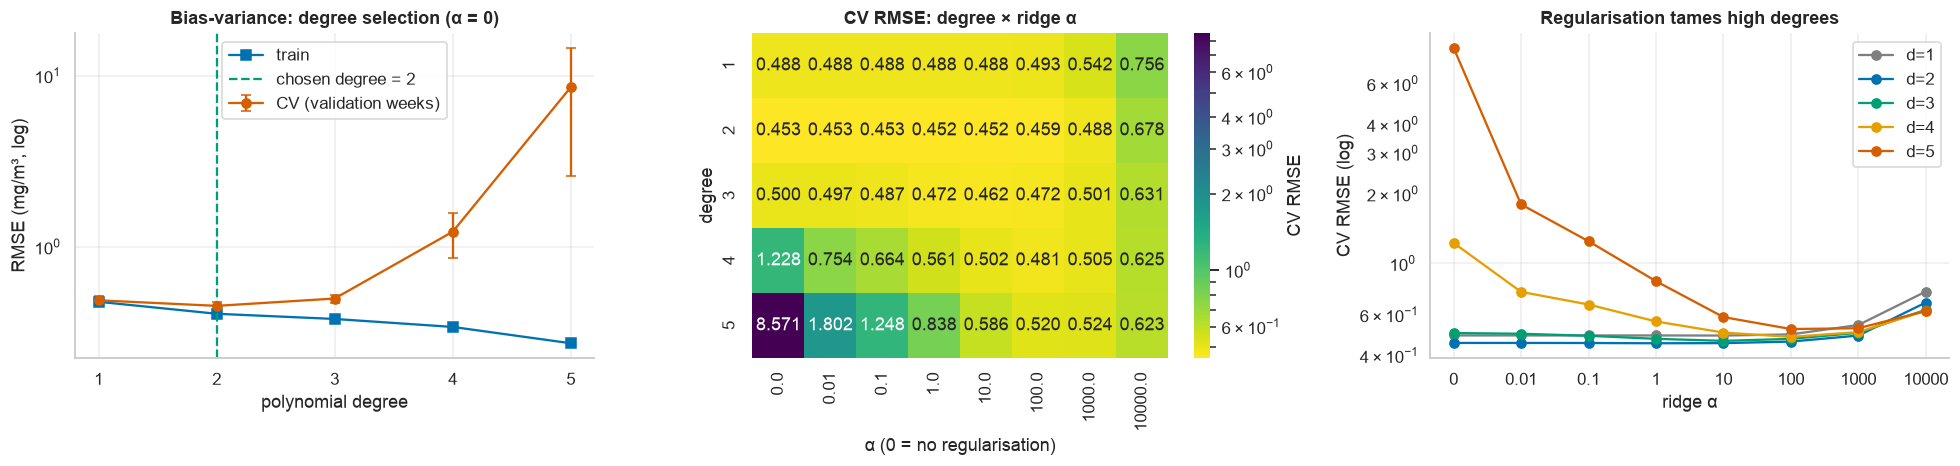

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4.4))
u = unreg.reset_index()
ax[0].errorbar(u["degree"], u["cv_rmse"], yerr=u["cv_rmse_se"], color=RED, marker="o", capsize=3, label="CV (validation weeks)")
ax[0].plot(u["degree"], u["train_rmse"], color=BLUE, marker="s", label="train")
ax[0].axvline(DEG_STAR, color=GREEN, ls="--", label=f"chosen degree = {DEG_STAR}"); ax[0].set_yscale("log")
ax[0].set_xticks(DEGREES); ax[0].set_xlabel("polynomial degree"); ax[0].set_ylabel("RMSE (mg/m³, log)"); ax[0].set_title("Bias-variance: degree selection (α = 0)"); ax[0].legend()

piv = agg.pivot(index="degree", columns="alpha", values="cv_rmse")
sns.heatmap(piv, annot=True, fmt=".3f", cmap="viridis_r", ax=ax[1], cbar_kws={"label": "CV RMSE"}, norm=matplotlib.colors.LogNorm())
ax[1].set_title("CV RMSE: degree × ridge α"); ax[1].set_xlabel("α (0 = no regularisation)")
for deg, c in zip(DEGREES, [GREY, BLUE, GREEN, ORANGE, RED]):
    s = agg[agg["degree"] == deg]; ax[2].plot(range(len(s)), s["cv_rmse"], marker="o", color=c, label=f"d={deg}")
ax[2].set_xticks(range(len(ALPHAS))); ax[2].set_xticklabels([f"{a:g}" for a in ALPHAS]); ax[2].set_yscale("log")
ax[2].set_xlabel("ridge α"); ax[2].set_ylabel("CV RMSE (log)"); ax[2].set_title("Regularisation tames high degrees"); ax[2].legend()
plt.tight_layout(); plt.show()

#### 2.3.2 Final polynomial models: scratch (closed form), scratch (Adam, tracked per epoch), scikit-learn, and the ridge variant

In [30]:
N_POLY_NE, N_POLY_GD, N_POLY_SK = f"Poly(d={DEG_STAR}) | scratch (normal eq.)", f"Poly(d={DEG_STAR}) | scratch (Adam GD)", f"Poly(d={DEG_STAR}) | sklearn"
N_PR_SC, N_PR_SK = f"Poly(d={DEG_R})+Ridge(α={ALPHA_R:g}) | scratch", f"Poly(d={DEG_R})+Ridge(α={ALPHA_R:g}) | sklearn"
nterms = lambda d: sum(1 for k in range(1, d + 1) for _ in combinations_with_replacement(range(len(FEATURES)), k)) + 1

# --- gradient-based poly fit: pick Adam's learning rate by TRAIN loss only (same principle as for the linear model)
EPOCHS_POLY = 3000
adam_rows = []
for lr in [0.003, 0.01, 0.03, 0.1]:
    mm = PolyRegressionScratch(DEG_STAR, solver="adam", lr=lr, epochs=EPOCHS_POLY).fit(X_train_s, y_train)
    adam_rows.append({"lr": lr, "diverged": mm.lin_.diverged_, "train_rmse": rmse(y_train, mm.predict(X_train_s))})
adam_tbl = pd.DataFrame(adam_rows).set_index("lr"); display(adam_tbl)
LR_POLY = float(adam_tbl[~adam_tbl["diverged"]]["train_rmse"].idxmin()); print("Selected Adam lr:", LR_POLY)

m, t = timed_fit(PolyRegressionScratch(DEG_STAR, solver="normal"), X_train_s, y_train); evaluate(N_POLY_NE, m, "Polynomial", f"degree {DEG_STAR}, OLS lstsq", t, nterms(DEG_STAR))
m, t = timed_fit(PolyRegressionScratch(DEG_STAR, solver="adam", lr=LR_POLY, epochs=EPOCHS_POLY, track=True), X_train_s, y_train, eval_sets={"test": (X_test_s, y_test)})
evaluate(N_POLY_GD, m, "Polynomial", f"degree {DEG_STAR}, Adam lr={LR_POLY}, {EPOCHS_POLY} epochs", t, nterms(DEG_STAR)); HISTORY[N_POLY_GD] = m.history_
m, t = timed_fit(make_pipeline(PolynomialFeatures(DEG_STAR, include_bias=False), StandardScaler(), LinearRegression()), X_train_s, y_train)
evaluate(N_POLY_SK, m, "Polynomial", f"degree {DEG_STAR}, sklearn pipeline", t, nterms(DEG_STAR))
m, t = timed_fit(PolyRegressionScratch(DEG_R, solver="normal", alpha=ALPHA_R), X_train_s, y_train); evaluate(N_PR_SC, m, "Polynomial+Ridge", f"degree {DEG_R}, alpha {ALPHA_R:g}", t, nterms(DEG_R))
m, t = timed_fit(make_pipeline(PolynomialFeatures(DEG_R, include_bias=False), StandardScaler(), Ridge(alpha=ALPHA_R)), X_train_s, y_train)
evaluate(N_PR_SK, m, "Polynomial+Ridge", f"degree {DEG_R}, alpha {ALPHA_R:g}", t, nterms(DEG_R))

display(pd.DataFrame(RESULTS).T.loc[[N_POLY_NE, N_POLY_GD, N_POLY_SK, N_PR_SC, N_PR_SK], ["config"] + cols])
display(pd.DataFrame({"scratch NE vs sklearn": compare_pair(N_POLY_NE, N_POLY_SK), "scratch Adam vs sklearn": compare_pair(N_POLY_GD, N_POLY_SK),
                      "ridge scratch vs sklearn": compare_pair(N_PR_SC, N_PR_SK)}).T)
h = HISTORY[N_POLY_GD]; print(f"Adam: within 1% of its final train loss after {epochs_to_tol(h)} epochs; final train RMSE {h['train_rmse'].iloc[-1]:.4f} "
                              f"(closed-form optimum {RESULTS[N_POLY_NE]['train_rmse']:.4f})")

,diverged,train_rmse
lr,,
0.003,False,0.415
0.010,False,0.411
0.030,False,0.411
0.100,False,0.420


Selected Adam lr: 0.03


,config,train_mse,train_rmse,train_r2,test_mse,test_rmse,test_r2
Poly(d=2) | scratch (normal eq.),"degree 2, OLS lstsq",0.169,0.411,0.918,0.200,0.447,0.901
Poly(d=2) | scratch (Adam GD),"degree 2, Adam lr=0.03, 3000 epochs",0.169,0.411,0.918,0.200,0.447,0.901
Poly(d=2) | sklearn,"degree 2, sklearn pipeline",0.169,0.411,0.918,0.200,0.447,0.901
Poly(d=2)+Ridge(α=1) | scratch,"degree 2, alpha 1",0.169,0.411,0.918,0.200,0.447,0.901
Poly(d=2)+Ridge(α=1) | sklearn,"degree 2, alpha 1",0.169,0.411,0.918,0.200,0.447,0.901


,max |Δ test prediction|,corr(test predictions),Δ test RMSE,Δ test R²
scratch NE vs sklearn,0.000,1.000,0.000,0.000
scratch Adam vs sklearn,0.001,1.000,0.000,0.000
ridge scratch vs sklearn,0.000,1.000,0.000,0.000


Adam: within 1% of its final train loss after 638 epochs; final train RMSE 0.4112 (closed-form optimum 0.4112)


**Observations — from scratch vs. scikit-learn (polynomial, d = 2).**
- Closed-form scratch, Adam-trained scratch and the sklearn pipeline agree on every metric: **train RMSE 0.411 / R² 0.918, test RMSE 0.447 / R² 0.901** (maximum prediction difference for Adam: 0.0013 mg/m³ after 3,000 epochs).
- Adam converges (within 1 % of its final loss) in ~640 epochs; the expanded features are highly correlated, which is why an adaptive optimiser was used instead of plain GD.
- The ridge variant (d=2, α=1) is practically the same model (test RMSE 0.4474 vs. 0.4470); scratch and sklearn ridge also agree.
- Versus the linear model the polynomial lowers test RMSE from 0.493 to **0.447 (−9 %)** and raises R² from 0.880 to 0.901, at the price of a somewhat larger train–test gap (0.036 vs. 0.013).

### 2.4 Decision Tree Regressor
Trees are scale-invariant, so they are fed the same standardised matrix as the other models (verified below), which keeps the comparison like-for-like. We (i) run the **required `max_depth` experiment** (3, 5, 10, None), (ii) a fine **depth sweep 1–20** with both CV and test curves for the metric-vs-depth plots, then (iii) tune `max_depth × min_samples_leaf` by group-CV with the 1-SE rule, and (iv) try cost-complexity pruning as an alternative regulariser.

In [31]:
# scale-invariance check: same tree on raw vs standardised features gives identical predictions
t_raw = DecisionTreeRegressor(max_depth=5, random_state=SEED).fit(X_train, y_train)
t_std = DecisionTreeRegressor(max_depth=5, random_state=SEED).fit(X_train_s, y_train)
assert np.allclose(t_raw.predict(X_test), t_std.predict(X_test_s)); print("Tree predictions identical on raw and standardised features ✔\n")

REQ_DEPTHS = [3, 5, 10, None]
tree_names = {}
for d in REQ_DEPTHS:
    nm = f"Tree | max_depth={d}"; tree_names[d] = nm
    m, t = timed_fit(DecisionTreeRegressor(max_depth=d, random_state=SEED), X_train_s, y_train)
    evaluate(nm, m, "Decision Tree", f"max_depth={d}", t, complexity=m.get_n_leaves())
    RESULTS[nm].update({"depth_actual": m.get_depth(), "n_leaves": m.get_n_leaves(), **dict(cv_eval(DecisionTreeRegressor(max_depth=d, random_state=SEED)))})
req = pd.DataFrame(RESULTS).T.loc[list(tree_names.values()), ["depth_actual", "n_leaves"] + cols + ["cv_rmse", "cv_rmse_sd", "cv_r2"]]
display(req)

Tree predictions identical on raw and standardised features ✔



,depth_actual,n_leaves,train_mse,train_rmse,train_r2,test_mse,test_rmse,test_r2,cv_rmse,cv_rmse_sd,cv_r2
Tree | max_depth=3,3,8,0.304,0.552,0.853,0.343,0.585,0.831,0.577,0.038,0.835
Tree | max_depth=5,5,32,0.194,0.440,0.906,0.263,0.513,0.870,0.509,0.051,0.873
Tree | max_depth=10,10,693,0.068,0.260,0.967,0.296,0.544,0.854,0.598,0.041,0.824
Tree | max_depth=None,28,4245,0.000,0.000,1.000,0.372,0.610,0.817,0.659,0.055,0.786


**Observations — the required `max_depth` experiment.**

| max_depth | leaves | train RMSE | test RMSE | test R² |
|---|---|---|---|---|
| 3 | 8 | 0.552 | 0.585 | 0.831 |
| 5 | 32 | 0.440 | **0.513** | **0.870** |
| 10 | 693 | 0.260 | 0.544 | 0.854 |
| None (grew to depth 28) | 4,245 | 0.000 | 0.610 | 0.817 |

Depth 3 **under-fits** (high bias), depth 5 balances bias and variance, and depth 10 / `None` **over-fit**: the unrestricted tree memorises the training set (R² = 1.000, one leaf per ~1.4 samples) while test error is 19 % worse than at depth 5. CV agrees with the test ordering, i.e. the conclusion does not rely on the test set.

,max_depth,depth_actual,n_leaves,train_rmse,cv_rmse,test_rmse,train_r2,cv_r2,test_r2
0,1,1,2,0.9351,0.9423,0.9336,0.5781,0.5658,0.5696
1,2,2,4,0.6629,0.6739,0.6757,0.7880,0.7769,0.7746
2,3,3,8,0.5515,0.5773,0.5854,0.8532,0.8347,0.8308
3,4,4,16,0.4864,0.5263,0.5366,0.8859,0.8643,0.8578
4,5,5,32,0.4403,0.5092,0.5131,0.9065,0.8730,0.8700
5,6,6,64,0.4094,0.4998,0.5049,0.9191,0.8771,0.8741
6,7,7,125,0.3802,0.5470,0.5014,0.9303,0.8527,0.8758
7,8,8,237,0.3450,0.5643,0.5015,0.9426,0.8420,0.8758
8,9,9,417,0.3032,0.5793,0.5399,0.9556,0.8338,0.8561
9,10,10,693,0.2603,0.5981,0.5442,0.9673,0.8236,0.8538


Depth with the lowest CV RMSE: 6


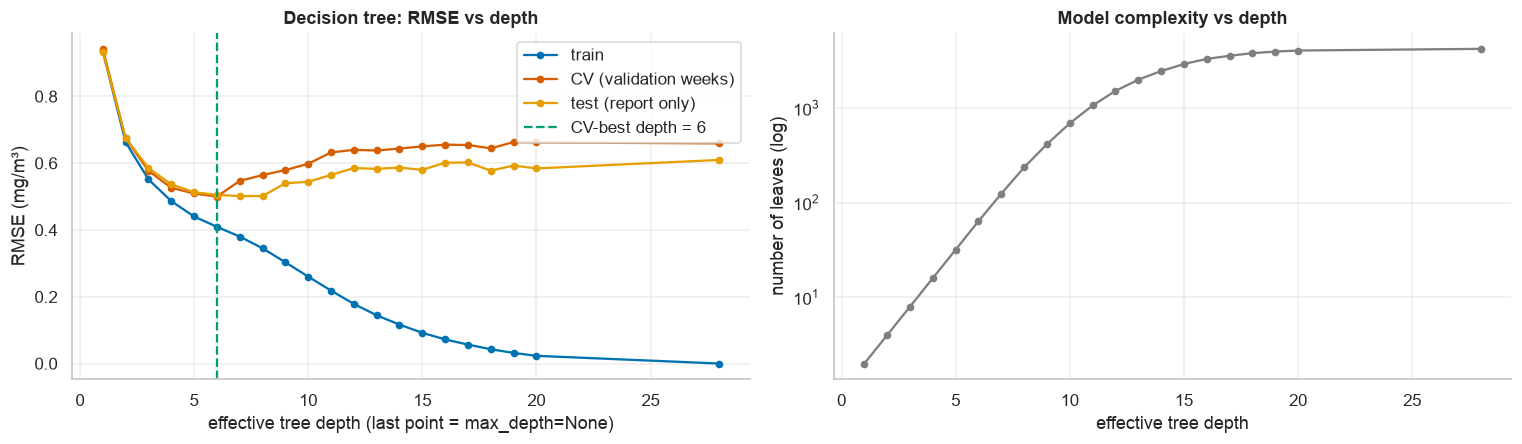

In [32]:
DEPTH_GRID = list(range(1, 21)) + [None]
rows = []
for d in DEPTH_GRID:
    m = DecisionTreeRegressor(max_depth=d, random_state=SEED).fit(X_train_s, y_train)
    r = {"max_depth": "None" if d is None else d, "depth_actual": m.get_depth(), "n_leaves": m.get_n_leaves()}
    for split, X_, y_ in (("train", X_train_s, y_train), ("test", X_test_s, y_test)):
        r.update({f"{split}_{k}": v for k, v in regression_metrics(y_, m.predict(X_)).items()})
    r.update(dict(cv_eval(DecisionTreeRegressor(max_depth=d, random_state=SEED))))
    rows.append(r)
TREE_SWEEP = pd.DataFrame(rows)
display(TREE_SWEEP[["max_depth", "depth_actual", "n_leaves", "train_rmse", "cv_rmse", "test_rmse", "train_r2", "cv_r2", "test_r2"]].style.format(precision=4)
        .highlight_min(subset=["cv_rmse"], color="#cfe8cf"))
d_best_cv = TREE_SWEEP.loc[TREE_SWEEP["cv_rmse"].idxmin(), "depth_actual"]
print("Depth with the lowest CV RMSE:", d_best_cv)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2)); x = TREE_SWEEP["depth_actual"]
ax[0].plot(x, TREE_SWEEP["train_rmse"], color=BLUE, marker="o", ms=4, label="train"); ax[0].plot(x, TREE_SWEEP["cv_rmse"], color=RED, marker="o", ms=4, label="CV (validation weeks)")
ax[0].plot(x, TREE_SWEEP["test_rmse"], color=ORANGE, marker="o", ms=4, label="test (report only)"); ax[0].axvline(d_best_cv, color=GREEN, ls="--", label=f"CV-best depth = {d_best_cv}")
ax[0].set_xlabel("effective tree depth (last point = max_depth=None)"); ax[0].set_ylabel("RMSE (mg/m³)"); ax[0].set_title("Decision tree: RMSE vs depth"); ax[0].legend()
ax[1].plot(x, TREE_SWEEP["n_leaves"], color=GREY, marker="o", ms=4); ax[1].set_yscale("log"); ax[1].set_xlabel("effective tree depth"); ax[1].set_ylabel("number of leaves (log)")
ax[1].set_title("Model complexity vs depth"); plt.tight_layout(); plt.show()

**Observations.** The fine sweep shows the classic U-shape: CV RMSE is lowest at **depth 6 (0.500)** and rises steadily afterwards, while training RMSE keeps falling to 0 and the leaf count explodes past 10³. The test curve is flat around depths 6–8 (≈ 0.50) and degrades beyond. (The test curve is displayed for the later evaluation plots only; selection uses the CV curve.)

Lowest CV RMSE : depth=6, min_samples_leaf=20  CV RMSE=0.4926
1-SE choice    : {'max_depth': 5, 'min_samples_leaf': 50}  CV RMSE=0.5134 (threshold 0.5143)


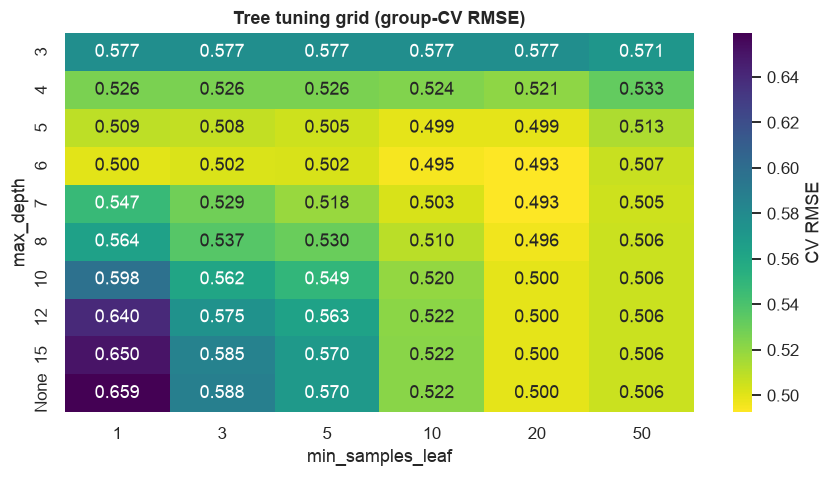

Best ccp_alpha = 0.00281  (leaves 21, CV RMSE 0.5212)


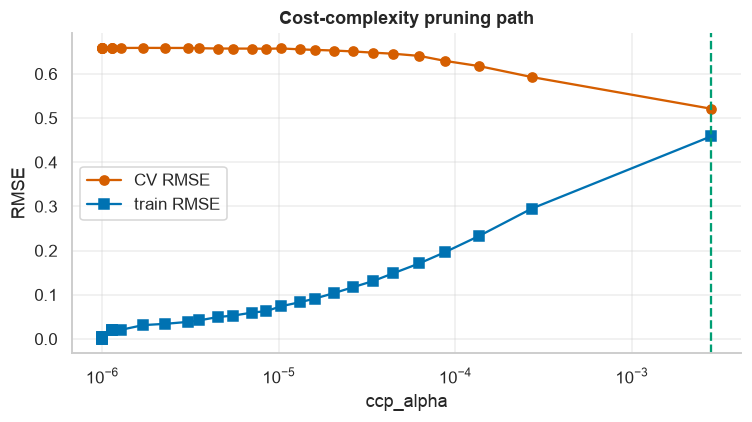

In [33]:
# --- joint tuning of max_depth x min_samples_leaf with group CV, then the 1-SE rule for a parsimonious tree
grid = {"max_depth": [3, 4, 5, 6, 7, 8, 10, 12, 15, None], "min_samples_leaf": [1, 3, 5, 10, 20, 50]}
gs = GridSearchCV(DecisionTreeRegressor(random_state=SEED), grid, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1, return_train_score=True)
gs.fit(X_train_s, y_train, groups=groups)
P_ = gs.cv_results_["params"]
G = pd.DataFrame({"max_depth": pd.Series([p["max_depth"] for p in P_], dtype=object), "min_samples_leaf": [p["min_samples_leaf"] for p in P_],
                  "train_rmse": -gs.cv_results_["mean_train_score"], "cv_rmse": -gs.cv_results_["mean_test_score"], "cv_rmse_sd": gs.cv_results_["std_test_score"]})
G["cv_rmse_se"] = G["cv_rmse_sd"] / np.sqrt(len(folds)); G["_d"] = G["max_depth"].map(lambda v: 99 if v is None else int(v))
G["depth_lbl"] = G["max_depth"].map(lambda v: "None" if v is None else str(int(v)))
best = G.loc[G["cv_rmse"].idxmin()]
simple = G[G["cv_rmse"] <= best["cv_rmse"] + best["cv_rmse_se"]].sort_values(["_d", "min_samples_leaf"], ascending=[True, False]).iloc[0]
TREE_BEST = {"max_depth": None if simple["_d"] == 99 else int(simple["_d"]), "min_samples_leaf": int(simple["min_samples_leaf"])}
print(f"Lowest CV RMSE : depth={best['depth_lbl']}, min_samples_leaf={int(best['min_samples_leaf'])}  CV RMSE={best['cv_rmse']:.4f}")
print(f"1-SE choice    : {TREE_BEST}  CV RMSE={simple['cv_rmse']:.4f} (threshold {best['cv_rmse'] + best['cv_rmse_se']:.4f})")

piv = G.pivot(index="depth_lbl", columns="min_samples_leaf", values="cv_rmse").loc[["None" if v is None else str(v) for v in grid["max_depth"]]]
plt.figure(figsize=(8, 4.5)); sns.heatmap(piv, annot=True, fmt=".3f", cmap="viridis_r", cbar_kws={"label": "CV RMSE"}); plt.title("Tree tuning grid (group-CV RMSE)")
plt.xlabel("min_samples_leaf"); plt.ylabel("max_depth"); plt.tight_layout(); plt.show()

N_TREE_T = "Tree | tuned (CV, 1-SE)"
m, t = timed_fit(DecisionTreeRegressor(**TREE_BEST, random_state=SEED), X_train_s, y_train)
evaluate(N_TREE_T, m, "Decision Tree", str(TREE_BEST), t, complexity=m.get_n_leaves())
RESULTS[N_TREE_T].update({"depth_actual": m.get_depth(), "n_leaves": m.get_n_leaves(), **dict(cv_eval(DecisionTreeRegressor(**TREE_BEST, random_state=SEED)))})

# --- cost-complexity pruning as an alternative regulariser
full = DecisionTreeRegressor(random_state=SEED).fit(X_train_s, y_train)
path = full.cost_complexity_pruning_path(X_train_s, y_train)
cand = np.unique(np.quantile(path.ccp_alphas[:-1], np.linspace(0, 0.995, 30)))
ccp = pd.DataFrame([{"ccp_alpha": a, **cv_eval(DecisionTreeRegressor(ccp_alpha=a, random_state=SEED)),
                     "n_leaves": DecisionTreeRegressor(ccp_alpha=a, random_state=SEED).fit(X_train_s, y_train).get_n_leaves()} for a in cand])
best_c = ccp.loc[ccp["cv_rmse"].idxmin()]; CCP_BEST = float(best_c["ccp_alpha"])
print(f"Best ccp_alpha = {CCP_BEST:.5f}  (leaves {int(best_c['n_leaves'])}, CV RMSE {best_c['cv_rmse']:.4f})")
fig, ax = plt.subplots(figsize=(7, 4)); ax.semilogx(ccp["ccp_alpha"].clip(lower=1e-6), ccp["cv_rmse"], marker="o", color=RED, label="CV RMSE")
ax.semilogx(ccp["ccp_alpha"].clip(lower=1e-6), ccp["cv_train_rmse"], marker="s", color=BLUE, label="train RMSE"); ax.axvline(max(CCP_BEST, 1e-6), color=GREEN, ls="--")
ax.set_xlabel("ccp_alpha"); ax.set_ylabel("RMSE"); ax.set_title("Cost-complexity pruning path"); ax.legend(); plt.tight_layout(); plt.show()
N_TREE_P = "Tree | pruned (ccp, CV)"
m, t = timed_fit(DecisionTreeRegressor(ccp_alpha=CCP_BEST, random_state=SEED), X_train_s, y_train)
evaluate(N_TREE_P, m, "Decision Tree", f"ccp_alpha={CCP_BEST:.5f}", t, complexity=m.get_n_leaves())
RESULTS[N_TREE_P].update({"depth_actual": m.get_depth(), "n_leaves": m.get_n_leaves(), **dict(cv_eval(DecisionTreeRegressor(ccp_alpha=CCP_BEST, random_state=SEED)))})

**Observations.**
- The lowest CV RMSE (0.4926) is at depth 6 with `min_samples_leaf = 20`. The **1-SE rule** picks the simpler **depth 5, `min_samples_leaf = 50`** (CV 0.5134), giving 29 leaves and a better-regularised tree (train–test gap 0.046 vs. 0.073 for the plain depth-5 tree).
- Cost-complexity pruning reaches a similar optimum (21 leaves, CV 0.521): the two regularisers agree that the useful structure of this problem is captured by roughly 20–30 leaves.
- Tuned and pruned trees do **not** beat the plain depth-5 tree on test RMSE (0.516 / 0.530 vs. 0.513) — differences of this size are within the fold noise (CV sd ≈ 0.05) — but they are more stable (smaller gap) and cheaper to interpret.

### 2.5 Master results table (all models, train and test) and the from-scratch vs scikit-learn verdict
CV scores are added for the models whose hyper-parameters were chosen by CV, so that Stage 5 can compare on *selection-safe* numbers as well as on the test set.

In [34]:
# add group-CV scores for the remaining headline models (cheap closed-form / sklearn fits)
for nm, est in {N_MEAN: DummyRegressor(), N_LIN_NE: LinearRegressionScratch(), N_POLY_NE: PolyRegressionScratch(DEG_STAR),
                N_PR_SC: PolyRegressionScratch(DEG_R, alpha=ALPHA_R)}.items():
    RESULTS[nm].update(dict(cv_eval(est)))

ORDER = [N_MEAN, N_LIN_NE, N_LIN_GD, N_LIN_SK, N_POLY_NE, N_POLY_GD, N_POLY_SK, N_PR_SC, N_PR_SK,
         tree_names[3], tree_names[5], tree_names[10], tree_names[None], N_TREE_T, N_TREE_P]
MASTER = pd.DataFrame(RESULTS).T.loc[ORDER].drop(columns=["depth_actual"], errors="ignore")
num = [c for c in MASTER.columns if c not in ("model", "family", "config", "complexity")]
MASTER[num] = MASTER[num].astype(float)
show = ["family", "config", "complexity", "train_mse", "train_rmse", "train_r2", "test_mse", "test_rmse", "test_r2", "rmse_gap (test-train)", "cv_rmse", "cv_r2"]
display(MASTER[show].style.format(precision=4, na_rep="–").background_gradient(subset=["test_rmse"], cmap="RdYlGn_r")
        .background_gradient(subset=["test_r2"], cmap="RdYlGn"))

# scratch-vs-sklearn verdict
pairs = [("Linear", N_LIN_NE, N_LIN_SK), ("Linear (GD)", N_LIN_GD, N_LIN_SK), (f"Poly d={DEG_STAR}", N_POLY_NE, N_POLY_SK),
         (f"Poly d={DEG_STAR} (Adam)", N_POLY_GD, N_POLY_SK), (f"Poly d={DEG_R}+Ridge", N_PR_SC, N_PR_SK)]
verdict = pd.DataFrame({lbl: {**compare_pair(a, b), "scratch test RMSE": RESULTS[a]["test_rmse"], "sklearn test RMSE": RESULTS[b]["test_rmse"],
                              "scratch test R²": RESULTS[a]["test_r2"], "sklearn test R²": RESULTS[b]["test_r2"]} for lbl, a, b in pairs}).T
display(verdict.style.format("{:.3e}", subset=["max |Δ test prediction|", "Δ test RMSE", "Δ test R²"]).format("{:.5f}", subset=["corr(test predictions)", "scratch test RMSE", "sklearn test RMSE", "scratch test R²", "sklearn test R²"]))

,family,config,complexity,train_mse,train_rmse,train_r2,test_mse,test_rmse,test_r2,rmse_gap (test-train),cv_rmse,cv_r2
Baseline | mean predictor,Baseline,predict train mean,1,2.0726,1.4397,0.0000,2.0255,1.4232,-0.0001,-0.0165,1.4378,-0.0100
Linear | scratch (normal eq.),Linear,"OLS, lstsq",9,0.2303,0.4799,0.8889,0.2433,0.4933,0.8799,0.0134,0.4882,0.8827
Linear | scratch (GD),Linear,"batch GD, lr=0.15, 1000 epochs",9,0.2303,0.4799,0.8889,0.2433,0.4933,0.8799,0.0134,–,–
Linear | sklearn,Linear,sklearn.LinearRegression,9,0.2303,0.4799,0.8889,0.2433,0.4933,0.8799,0.0134,–,–
Poly(d=2) | scratch (normal eq.),Polynomial,"degree 2, OLS lstsq",45,0.1691,0.4112,0.9184,0.1998,0.4470,0.9013,0.0359,0.4530,0.8988
Poly(d=2) | scratch (Adam GD),Polynomial,"degree 2, Adam lr=0.03, 3000 epochs",45,0.1691,0.4112,0.9184,0.1998,0.4470,0.9013,0.0359,–,–
Poly(d=2) | sklearn,Polynomial,"degree 2, sklearn pipeline",45,0.1691,0.4112,0.9184,0.1998,0.4470,0.9013,0.0359,–,–
Poly(d=2)+Ridge(α=1) | scratch,Polynomial+Ridge,"degree 2, alpha 1",45,0.1692,0.4113,0.9184,0.2001,0.4474,0.9012,0.0360,0.4516,0.8994
Poly(d=2)+Ridge(α=1) | sklearn,Polynomial+Ridge,"degree 2, alpha 1",45,0.1692,0.4113,0.9184,0.2001,0.4474,0.9012,0.0360,–,–
Tree | max_depth=3,Decision Tree,max_depth=3,8,0.3042,0.5515,0.8532,0.3427,0.5854,0.8308,0.0339,0.5773,0.8347


,max |Δ test prediction|,corr(test predictions),Δ test RMSE,Δ test R²,scratch test RMSE,sklearn test RMSE,scratch test R²,sklearn test R²
Linear,7.105e-15,1.00000,1.110e-16,0.000e+00,0.49327,0.49327,0.87986,0.87986
Linear (GD),1.091e-05,1.00000,1.248e-07,6.079e-08,0.49327,0.49327,0.87986,0.87986
Poly d=2,2.220e-14,1.00000,1.110e-16,1.110e-16,0.44702,0.44702,0.90134,0.90134
Poly d=2 (Adam),1.294e-03,1.00000,2.980e-06,1.316e-06,0.44702,0.44702,0.90134,0.90134
Poly d=2+Ridge,3.144e-13,1.00000,1.221e-15,5.551e-16,0.44737,0.44737,0.90118,0.90118


**Observations.**
- **Scratch ≡ scikit-learn.** For every model family and solver, the from-scratch implementations reproduce scikit-learn to numerical precision (Δ test RMSE ≈ 0, correlation of predictions = 1.0), which validates the from-scratch code.
- **Ranking by test RMSE:** Poly d=2 (0.447) < Linear (0.493) < Tree depth 5 (0.513) ≈ tuned tree (0.516) < pruned tree (0.530) < depth 10 (0.544) < depth 3 (0.585) < unrestricted tree (0.610) ≪ mean baseline (1.423). The **CV ranking is identical in order for the headline models**, so the ordering is not a test-set artefact.
- The polynomial model is the most accurate; the linear model is a strong, simple baseline (R² 0.88); trees are competitive only when depth-limited.

### 2.6 Model-interpretation artifacts (for Stages 3–4)
Three complementary importance views are stored, because impurity-based importances are known to be biased toward high-cardinality / correlated features and Stage 1 showed strong collinearity among the sensors:
1. tree **impurity (MDI) importances** for every required depth;
2. **permutation importance** on the test set (model-agnostic, in RMSE units) for the linear, polynomial and tree models;
3. **standardised linear coefficients with bootstrap 95 % CIs** (500 resamples of the training set).

,Tree | max_depth=3,Tree | max_depth=5,Tree | max_depth=10,Tree | max_depth=None,"Tree | tuned (CV, 1-SE)","Tree | pruned (ccp, CV)"
PT08.S1(CO),0.000,0.003,0.013,0.017,0.002,0.002
PT08.S2(NMHC),1.000,0.958,0.904,0.880,0.970,0.959
PT08.S3(NOx),0.000,0.007,0.014,0.016,0.000,0.007
PT08.S4(NO2),0.000,0.004,0.011,0.014,0.000,0.004
PT08.S5(O3),0.000,0.000,0.008,0.012,0.000,0.000
T,0.000,0.027,0.036,0.039,0.028,0.027
RH,0.000,0.000,0.007,0.011,0.000,0.000
AH,0.000,0.000,0.007,0.011,0.000,0.000


,PT08.S2(NMHC),T,PT08.S1(CO),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),RH,AH
mean,1.418,0.092,0.003,0.000,0.000,0.000,0.000,0.000
std,0.029,0.007,0.001,0.000,0.000,0.000,0.000,0.000


,coef,ci_low,ci_high,significant (CI excludes 0)
PT08.S1(CO),0.394,0.354,0.437,True
PT08.S2(NMHC),1.366,1.242,1.484,True
PT08.S3(NOx),0.199,0.156,0.244,True
PT08.S4(NO2),-0.174,-0.241,-0.101,True
PT08.S5(O3),-0.077,-0.121,-0.031,True
T,-0.244,-0.281,-0.206,True
RH,-0.030,-0.061,0.003,False
AH,0.087,0.047,0.125,True


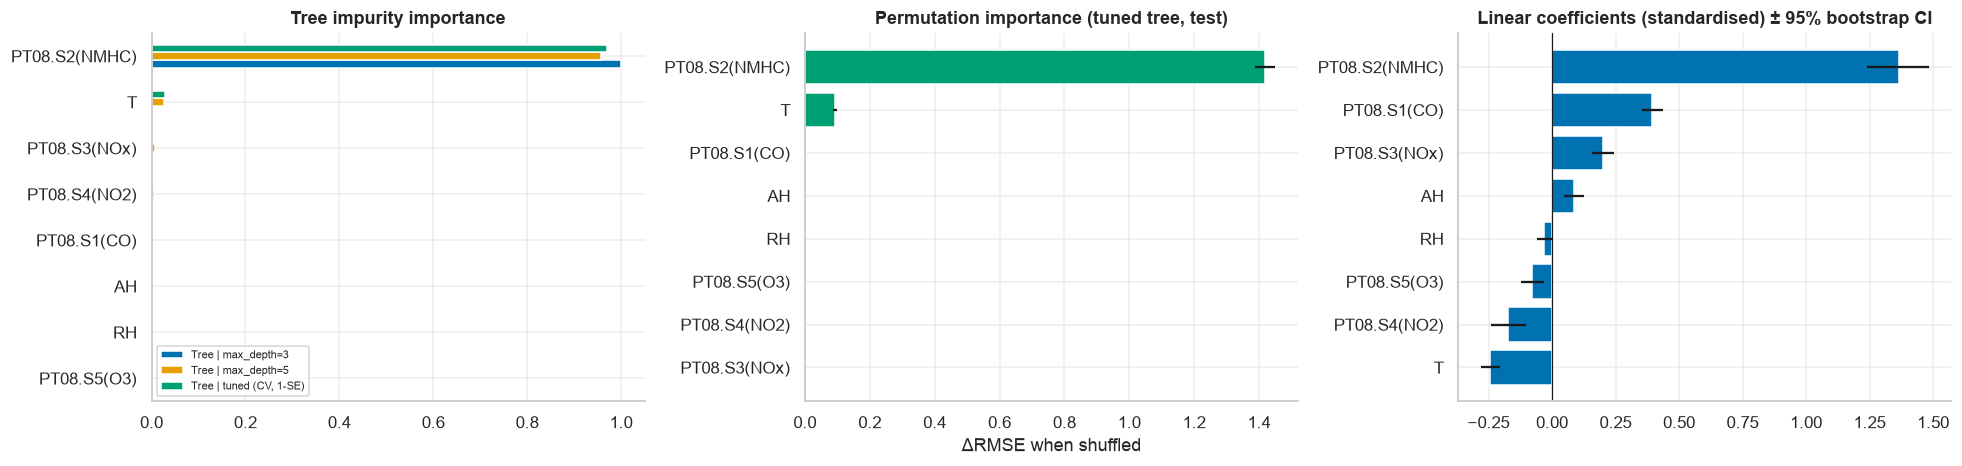

In [35]:
# 1) impurity importances
IMP_TREE = pd.DataFrame({nm: FITTED[nm].feature_importances_ for nm in [tree_names[3], tree_names[5], tree_names[10], tree_names[None], N_TREE_T, N_TREE_P]}, index=FEATURES)
# 2) permutation importance on the test set (increase in RMSE when a feature is shuffled)
PERM = {}
for nm in [N_LIN_NE, N_POLY_NE, tree_names[3], tree_names[5], N_TREE_T]:
    pi = permutation_importance(FITTED[nm], X_test_s, y_test, scoring="neg_root_mean_squared_error", n_repeats=20, random_state=SEED)
    PERM[nm] = pd.DataFrame({"mean": pi.importances_mean, "std": pi.importances_std}, index=FEATURES)
# 3) bootstrap CIs of the standardised linear coefficients
rb = np.random.default_rng(SEED); B = []
for _ in range(500):
    idx = rb.integers(0, len(X_train_s), len(X_train_s)); B.append(LinearRegressionScratch().fit(X_train_s.values[idx], y_train.values[idx]).coef_)
B = np.array(B)
COEF_BOOT = pd.DataFrame({"coef": FITTED[N_LIN_NE].coef_, "ci_low": np.percentile(B, 2.5, 0), "ci_high": np.percentile(B, 97.5, 0)}, index=FEATURES)
COEF_BOOT["significant (CI excludes 0)"] = (COEF_BOOT["ci_low"] > 0) | (COEF_BOOT["ci_high"] < 0)

display(IMP_TREE.style.format("{:.3f}").background_gradient(cmap="Blues", axis=0))
display(PERM[N_TREE_T].sort_values("mean", ascending=False).T.style.format("{:.3f}"))
display(COEF_BOOT.style.format({"coef": "{:.3f}", "ci_low": "{:.3f}", "ci_high": "{:.3f}"}))

fig, ax = plt.subplots(1, 3, figsize=(18, 4.4))
IMP_TREE[[tree_names[3], tree_names[5], N_TREE_T]].sort_values(tree_names[5]).plot.barh(ax=ax[0], color=[BLUE, ORANGE, GREEN]); ax[0].set_title("Tree impurity importance"); ax[0].legend(fontsize=7)
pn = PERM[N_TREE_T]["mean"].sort_values(); ax[1].barh(pn.index, pn.values, xerr=PERM[N_TREE_T].loc[pn.index, "std"], color=GREEN); ax[1].set_title("Permutation importance (tuned tree, test)"); ax[1].set_xlabel("ΔRMSE when shuffled")
cb = COEF_BOOT.sort_values("coef"); ax[2].barh(cb.index, cb["coef"], xerr=[cb["coef"] - cb["ci_low"], cb["ci_high"] - cb["coef"]], color=BLUE); ax[2].axvline(0, color="k", lw=.8)
ax[2].set_title("Linear coefficients (standardised) ± 95% bootstrap CI"); plt.tight_layout(); plt.show()

**Observations — feature importance (three views agree).**
- **`PT08.S2(NMHC)` dominates everywhere:** 97 % of the tuned tree's impurity importance, a permutation importance of +1.42 mg/m³ RMSE when shuffled (the next feature, `T`, is only +0.09), and the largest linear coefficient (1.37, CI 1.24–1.48). The depth-3 tree splits **only** on this sensor.
- `T` is the clear second feature for the tree (≈ 3 %) and the third-largest linear effect (−0.24, CI excludes 0). `PT08.S1(CO)` matters linearly (+0.39) but almost never in the tree: it is redundant with `PT08.S2` (r = 0.89, Stage 1), so the tree gives it ~0 importance even though it is individually predictive — a collinearity effect, not irrelevance.
- Only `RH` has a coefficient whose 95 % bootstrap CI includes zero.
- Caveat: with highly collinear sensors, importance is shared/arbitrarily assigned among them; the drop-one ablation below is the more reliable check.

### 2.7 Ablation studies
All ablations are scored with the **group-CV on the training set** (the test set is not used to make any choice here). They feed the Stage 5 baseline comparison.

**2.7.1 Feature ablation** — which inputs does each model family actually need? (all features, sensors only, weather only, one best sensor, and leave-one-feature-out.)

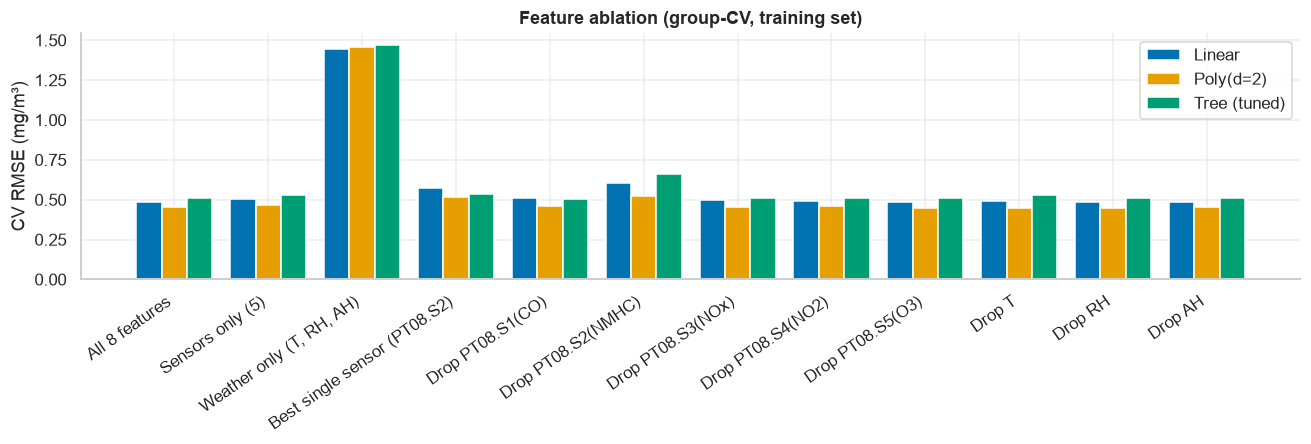

In [36]:
def make_linear(): return LinearRegressionScratch()
def make_poly():   return PolyRegressionScratch(DEG_STAR)
def make_tree():   return DecisionTreeRegressor(**TREE_BEST, random_state=SEED)
FACT = {"Linear": make_linear, f"Poly(d={DEG_STAR})": make_poly, "Tree (tuned)": make_tree}

subsets = {"All 8 features": FEATURES, "Sensors only (5)": SENSOR_COLS, "Weather only (T, RH, AH)": WEATHER_COLS, "Best single sensor (PT08.S2)": ["PT08.S2(NMHC)"]}
subsets.update({f"Drop {f}": [c for c in FEATURES if c != f] for f in FEATURES})
rows = []
for sname, cols_ in subsets.items():
    for mname, mk in FACT.items():
        r = cv_eval(mk(), X=X_train_s[cols_]); rows.append({"feature set": sname, "model": mname, "n_features": len(cols_), "cv_rmse": r["cv_rmse"], "cv_rmse_sd": r["cv_rmse_sd"], "cv_r2": r["cv_r2"]})
ABL_FEAT = pd.DataFrame(rows)
tbl = ABL_FEAT.pivot(index="feature set", columns="model", values="cv_rmse").loc[list(subsets)]
base = tbl.loc["All 8 features"]; delta = (tbl - base)
display(pd.concat({"CV RMSE": tbl, "Δ vs all features": delta}, axis=1).style.format(precision=4).background_gradient(cmap="RdYlGn_r", subset=pd.IndexSlice[:, "Δ vs all features"]))

fig, ax = plt.subplots(figsize=(12, 4.2)); w = 0.27; xi = np.arange(len(tbl))
for i, (mname, c) in enumerate(zip(tbl.columns, [BLUE, ORANGE, GREEN])): ax.bar(xi + (i - 1) * w, tbl[mname], w, color=c, label=mname)
ax.set_xticks(xi); ax.set_xticklabels(tbl.index, rotation=35, ha="right"); ax.set_ylabel("CV RMSE (mg/m³)"); ax.set_title("Feature ablation (group-CV, training set)"); ax.legend()
plt.tight_layout(); plt.show()

**Observations — feature ablation (CV RMSE).**
- **Weather alone is useless** (≈ 1.44–1.47, i.e. the same as the mean predictor, 1.44): the weather variables carry almost no *direct* information about CO.
- **Sensors alone are almost as good as everything** (+0.014–0.016 RMSE): weather adds only a small correction (mostly via `T`, as the linear coefficient suggests).
- **`PT08.S2` is the one indispensable feature**: dropping it hurts every model (+0.12 linear, +0.07 polynomial, **+0.15 tree**), whereas dropping any other single feature changes CV RMSE by ≤ 0.02 (and sometimes improves it slightly): the sensors are mutually redundant.
- A **single feature (`PT08.S2`) already gets RMSE 0.52–0.58**, and the tree is least dependent on the other features (0.534 with S2 only).
- Dropping `T` hurts the tree (+0.017) but not the polynomial (−0.003): a possible reason (not tested) is that the polynomial can recover part of that information through sensor interaction terms.

**2.7.2 Preprocessing ablations** — (a) is standardisation really needed for gradient descent? (b) does a log-transformed target help (Stage 1 flagged the skew)? (c) does the tree split criterion matter?

,stable lr,train RMSE @ end,gap to OLS optimum
raw features,8.04578e-08,0.620901,0.141017
standardised,0.15,0.479884,6.93362e-12


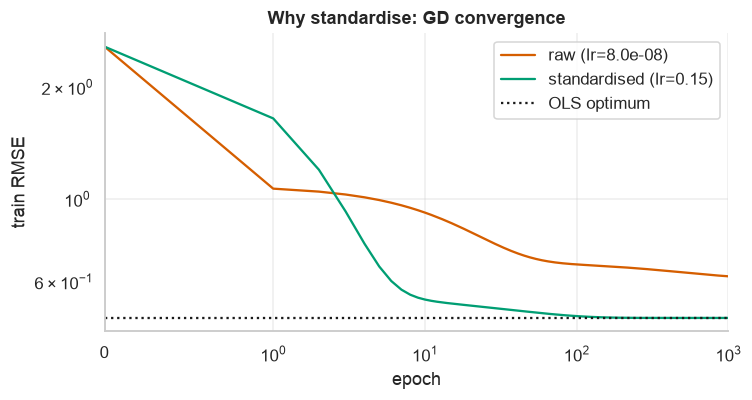

,CV RMSE (raw target),CV RMSE (log1p target),CV R² raw,CV R² log
model,,,,
Linear,0.4882,0.5237,0.8827,0.8623
Poly(d=2),0.4530,0.4488,0.8988,0.9002
Tree (tuned),0.5134,0.5121,0.8709,0.8707


,cv_rmse,cv_rmse_sd,cv_r2,cv_train_rmse
criterion,,,,
squared_error,0.5134,0.0478,0.8709,0.4687
friedman_mse,0.5134,0.0478,0.8709,0.4687
absolute_error,0.5019,0.0472,0.8762,0.4711
poisson,0.5060,0.0438,0.8744,0.4631


In [37]:
# (a) GD on RAW (unscaled) features vs standardised features, same epoch budget; lr = half the stability limit of each design matrix
Xr = LinearRegressionScratch._design(X_train.values); lam_r = np.linalg.eigvalsh(Xr.T @ Xr / len(Xr)).max(); lr_raw = 0.5 * 2 / (2 * lam_r)
raw = LinearRegressionScratch(solver="gd", lr=lr_raw, epochs=EPOCHS_LIN, track=True).fit(X_train, y_train)
sc = LinearRegressionScratch(solver="gd", lr=LR_LIN, epochs=EPOCHS_LIN, track=True).fit(X_train_s, y_train)
opt_rmse = RESULTS[N_LIN_NE]["train_rmse"]
ABL_SCALE = pd.DataFrame({"raw features": {"stable lr": lr_raw, "train RMSE @ end": raw.history_["train_rmse"].iloc[-1], "gap to OLS optimum": raw.history_["train_rmse"].iloc[-1] - opt_rmse},
                          "standardised": {"stable lr": LR_LIN, "train RMSE @ end": sc.history_["train_rmse"].iloc[-1], "gap to OLS optimum": sc.history_["train_rmse"].iloc[-1] - opt_rmse}}).T
display(ABL_SCALE.style.format("{:.6g}"))
fig, ax = plt.subplots(figsize=(7, 3.8)); ax.plot(raw.history_["epoch"], raw.history_["train_rmse"], color=RED, label=f"raw (lr={lr_raw:.1e})")
ax.plot(sc.history_["epoch"], sc.history_["train_rmse"], color=GREEN, label=f"standardised (lr={LR_LIN})"); ax.axhline(opt_rmse, color="k", ls=":", label="OLS optimum")
ax.set_yscale("log"); ax.set_xscale("symlog", linthresh=1); ax.set_xlim(0, EPOCHS_LIN); ax.set_xlabel("epoch"); ax.set_ylabel("train RMSE"); ax.set_title("Why standardise: GD convergence"); ax.legend(); plt.tight_layout(); plt.show()

# (b) log-target
log_models = {"Linear": make_linear, f"Poly(d={DEG_STAR})": make_poly, "Tree (tuned)": make_tree}
rows = []
for mname, mk in log_models.items():
    base_ = cv_eval(mk()); logd = cv_eval(TransformedTargetRegressor(regressor=mk(), func=np.log1p, inverse_func=np.expm1))
    rows.append({"model": mname, "CV RMSE (raw target)": base_["cv_rmse"], "CV RMSE (log1p target)": logd["cv_rmse"], "CV R² raw": base_["cv_r2"], "CV R² log": logd["cv_r2"]})
ABL_LOG = pd.DataFrame(rows).set_index("model"); display(ABL_LOG.style.format(precision=4))

# (c) split criterion (tuned tree, CV)
rows = [{"criterion": c, **cv_eval(DecisionTreeRegressor(**TREE_BEST, criterion=c, random_state=SEED))} for c in ["squared_error", "friedman_mse", "absolute_error", "poisson"]]
ABL_CRIT = pd.DataFrame(rows).set_index("criterion")[["cv_rmse", "cv_rmse_sd", "cv_r2", "cv_train_rmse"]]; display(ABL_CRIT.style.format(precision=4))

**Observations — preprocessing ablations.**
- **Scaling is essential for gradient descent.** On raw features the largest stable learning rate is tiny, and after the same 1,000 epochs the training RMSE is 0.621 versus 0.480 for standardised inputs (the optimum): the badly scaled directions of the loss surface converge very slowly. This empirically supports the Stage 1 decision.
- **Log-target:** worse for the linear model (CV RMSE 0.488 → 0.524; a plausible cause is that the back-transform amplifies errors on the peaks, though this was not tested separately), neutral for the polynomial (0.453 → 0.449, within noise) and no effect for the tree. The raw target is retained.
- **Split criterion:** `absolute_error` (0.502) and `poisson` (0.506) are about 0.01 better than `squared_error`/`friedman_mse` (0.513, which are identical here), i.e. within one standard error (≈ 0.021) of each other. Since the assignment's metrics are MSE-based, `squared_error` is kept.

**2.7.3 Regularisation path for the linear model** — how do the coefficients (and the CV error) respond to L2 shrinkage under multicollinearity?

Best ridge alpha (linear) = 21.5; CV RMSE 0.4877 vs OLS 0.4882


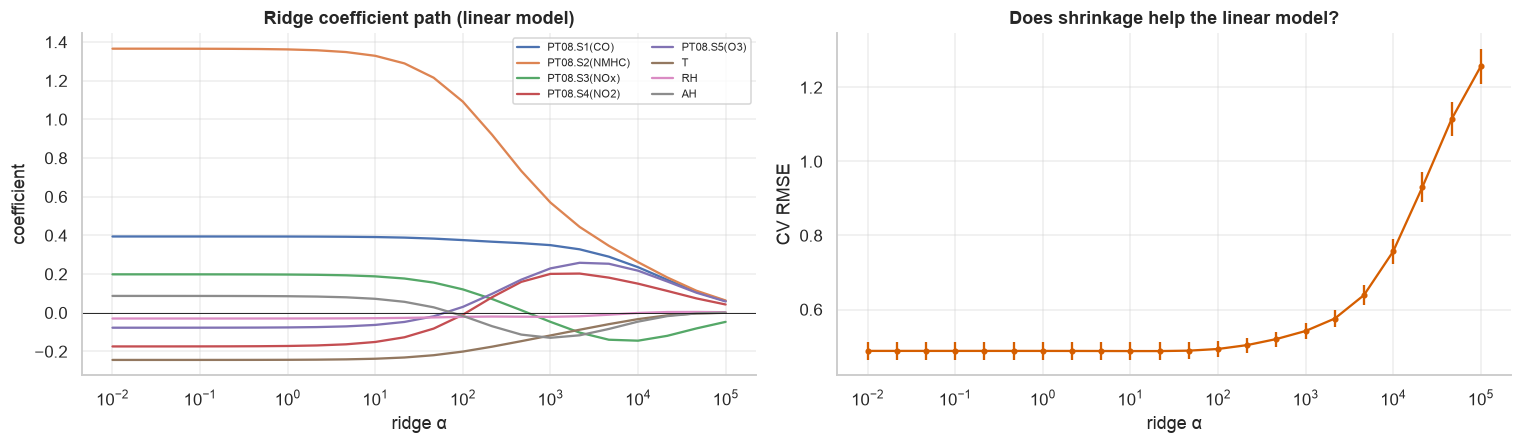

In [38]:
RIDGE_ALPHAS = np.logspace(-2, 5, 22)
path_rows, cv_rows = [], []
for a in RIDGE_ALPHAS:
    mdl = LinearRegressionScratch(alpha=a).fit(X_train_s, y_train); path_rows.append(pd.Series(mdl.coef_, index=FEATURES, name=a))
    cv_rows.append({"alpha": a, **cv_eval(LinearRegressionScratch(alpha=a))})
RIDGE_PATH, RIDGE_CV = pd.DataFrame(path_rows), pd.DataFrame(cv_rows).set_index("alpha")
a_best = RIDGE_CV["cv_rmse"].idxmin(); print(f"Best ridge alpha (linear) = {a_best:.3g}; CV RMSE {RIDGE_CV.loc[a_best, 'cv_rmse']:.4f} vs OLS {RIDGE_CV.iloc[0]['cv_rmse']:.4f}")
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for f in FEATURES: ax[0].plot(RIDGE_PATH.index, RIDGE_PATH[f], label=f)
ax[0].set_xscale("log"); ax[0].axhline(0, color="k", lw=.6); ax[0].set_xlabel("ridge α"); ax[0].set_ylabel("coefficient"); ax[0].set_title("Ridge coefficient path (linear model)"); ax[0].legend(fontsize=7, ncol=2)
ax[1].errorbar(RIDGE_CV.index, RIDGE_CV["cv_rmse"], yerr=RIDGE_CV["cv_rmse_sd"] / np.sqrt(len(folds)), color=RED, marker="o", ms=3); ax[1].set_xscale("log")
ax[1].set_xlabel("ridge α"); ax[1].set_ylabel("CV RMSE"); ax[1].set_title("Does shrinkage help the linear model?"); plt.tight_layout(); plt.show()

**Observation.** Ridge shrinkage does **not** improve the linear model (best α ≈ 21: CV RMSE 0.4877 vs. 0.4882 for OLS) and large α quickly hurts. The multicollinearity found in Stage 1 therefore affects the *interpretation* of individual coefficients (the coefficient paths of the correlated sensors cross and change sign as α grows), but **not the predictive accuracy**.

### 2.8 Learning curves, per-regime errors and out-of-time robustness
* **Learning curves** (group-CV): is more data likely to help each model, or is it bias-limited?
* **Per-regime errors** on the test set: where (Low … Very-high CO) does each model fail? (Stage 1 flagged the 8:1 imbalance.)
* **Out-of-time check**: refit with *fixed* hyper-parameters on the first 80 % of the timeline and test on the last 20 % — the chronological protocol rejected as the default in Stage 1.

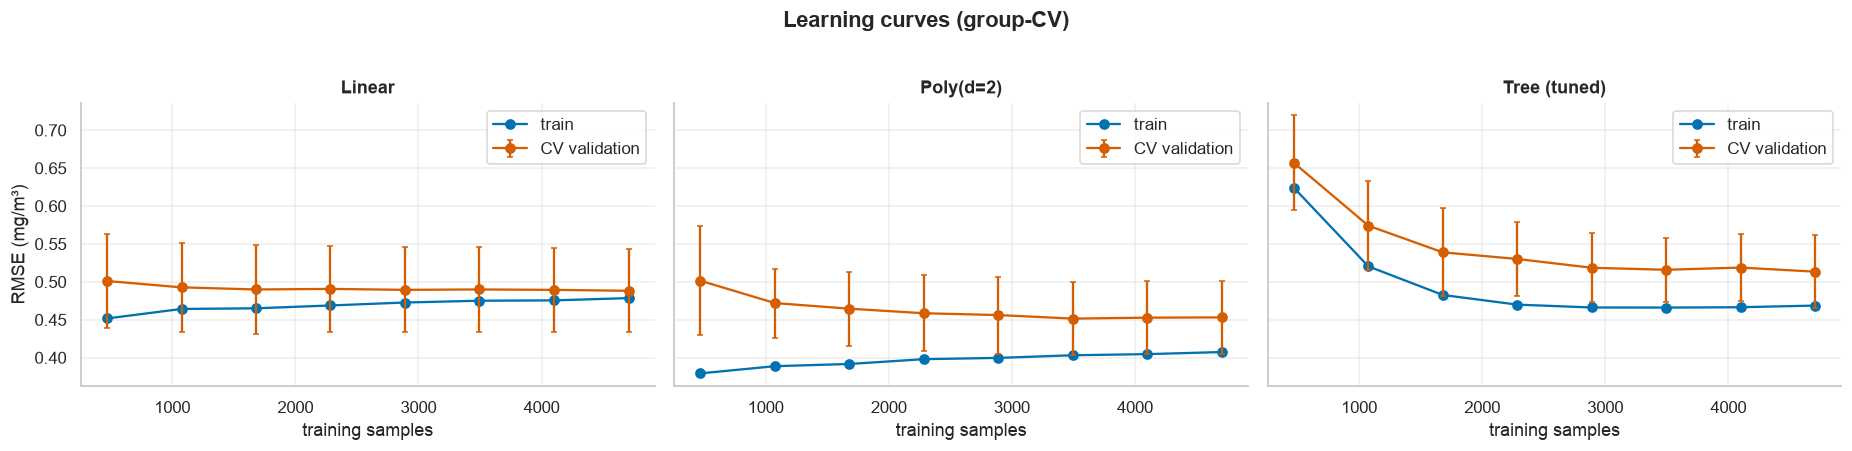

In [39]:
LC = {}
sizes = np.linspace(0.1, 1.0, 8)
for mname, mk in FACT.items():
    ts, trs, vas = learning_curve(mk(), X_train_s, y_train, groups=groups, cv=cv, train_sizes=sizes, scoring="neg_root_mean_squared_error", shuffle=True, random_state=SEED)[0:3]
    LC[mname] = pd.DataFrame({"n_train": ts, "train_rmse": -trs.mean(1), "val_rmse": -vas.mean(1), "val_rmse_sd": vas.std(1)}).set_index("n_train")
fig, ax = plt.subplots(1, 3, figsize=(17, 4), sharey=True)
for a, (mname, df_) in zip(ax, LC.items()):
    a.plot(df_.index, df_["train_rmse"], color=BLUE, marker="o", label="train"); a.errorbar(df_.index, df_["val_rmse"], yerr=df_["val_rmse_sd"], color=RED, marker="o", capsize=2, label="CV validation")
    a.set_title(mname); a.set_xlabel("training samples"); a.legend()
ax[0].set_ylabel("RMSE (mg/m³)"); plt.suptitle("Learning curves (group-CV)", y=1.02, fontweight="bold"); plt.tight_layout(); plt.show()
display(pd.concat({k: v.iloc[[0, 3, -1]] for k, v in LC.items()}).style.format(precision=4))

**Observations.**
- **Linear:** training and validation RMSE are flat and almost equal (0.478 vs. 0.488) already from ~500 samples → high bias; **more data will not help**, a more flexible model might.
- **Poly d=2:** a small, shrinking gap (0.407 vs. 0.453) and a validation curve that is nearly flat from ~3,000 samples: close to its capacity.
- **Tuned tree:** the largest data hunger — validation error falls from 0.657 (n=470) to ≈ 0.52 at n ≈ 2,900 and then plateaus.
- Fold-to-fold spread (error bars, ≈ ±0.05) is of the same order as the differences between the models, so differences below ~0.03 RMSE should not be over-interpreted.

In [40]:
FINAL = [N_MEAN, N_LIN_NE, N_POLY_NE, N_PR_SC, tree_names[3], tree_names[5], tree_names[10], tree_names[None], N_TREE_T]
bt_test = pd.cut(y_test, bands_edges, labels=bands_labels, right=False)
rows = []
for nm in FINAL:
    err = PRED[nm]["test"] - y_test.values
    for b in bands_labels:
        mk_ = (bt_test == b).values; rows.append({"model": nm, "regime": b, "n": int(mk_.sum()), "rmse": np.sqrt(np.mean(err[mk_] ** 2)), "mae": np.mean(np.abs(err[mk_])), "bias (pred-true)": err[mk_].mean()})
REGIME = pd.DataFrame(rows)
display(REGIME.pivot(index="model", columns="regime", values="rmse")[bands_labels].loc[FINAL].style.format(precision=3).background_gradient(cmap="RdYlGn_r", axis=None).set_caption("Test RMSE by CO regime"))
display(REGIME.pivot(index="model", columns="regime", values="bias (pred-true)")[bands_labels].loc[FINAL].style.format(precision=3).background_gradient(cmap="coolwarm", axis=None, vmin=-3, vmax=3).set_caption("Mean error (pred − true) by CO regime: negative = under-prediction"))

# residual artefacts for Stage 3
RESID = {nm: {"train": y_train.values - PRED[nm]["train"], "test": y_test.values - PRED[nm]["test"]} for nm in PRED}

regime,Low (<1.5),Moderate (1.5-3),High (3-5),Very high (>=5)
model,,,,
Baseline | mean predictor,1.302,0.427,1.731,3.984
Linear | scratch (normal eq.),0.384,0.433,0.519,1.173
Poly(d=2) | scratch (normal eq.),0.326,0.391,0.559,0.946
Poly(d=2)+Ridge(α=1) | scratch,0.326,0.391,0.561,0.949
Tree | max_depth=3,0.405,0.508,0.725,1.327
Tree | max_depth=5,0.361,0.437,0.646,1.152
Tree | max_depth=10,0.356,0.441,0.771,1.149
Tree | max_depth=None,0.386,0.515,0.886,1.190
"Tree | tuned (CV, 1-SE)",0.361,0.437,0.653,1.161


regime,Low (<1.5),Moderate (1.5-3),High (3-5),Very high (>=5)
model,,,,
Baseline | mean predictor,1.256,0.047,-1.637,-3.878
Linear | scratch (normal eq.),0.012,0.101,-0.085,-0.927
Poly(d=2) | scratch (normal eq.),0.089,-0.007,-0.114,-0.555
Poly(d=2)+Ridge(α=1) | scratch,0.090,-0.007,-0.114,-0.557
Tree | max_depth=3,0.166,-0.008,-0.220,-0.710
Tree | max_depth=5,0.119,-0.016,-0.133,-0.660
Tree | max_depth=10,0.089,-0.011,-0.190,-0.503
Tree | max_depth=None,0.076,-0.009,-0.197,-0.414
"Tree | tuned (CV, 1-SE)",0.119,-0.016,-0.126,-0.556


**Observations — where do the models fail?**
- **All models under-predict the rare *Very high* hours** (mean error −0.93 linear, −0.56 polynomial, −0.56 tuned tree, −0.41 unrestricted tree) and their RMSE is 2–3× larger there than in the other regimes (0.95–1.19 vs. 0.33–0.65). This is the consequence of the 8:1 imbalance flagged in Stage 1: the squared-error objective is dominated by the bulk of the data.
- The polynomial model is best in the Low (0.326), Moderate (0.391) and Very-high (0.946) regimes; the **linear model is best in the High regime** (0.519 vs. 0.559 polynomial, 0.653 tuned tree).
- Overall RMSE therefore hides substantial regime-dependent differences; Stage 3 will use these tables.

In [41]:
cut = int(len(data) * 0.8); Xo_tr, Xo_te, yo_tr, yo_te = data[FEATURES].iloc[:cut], data[FEATURES].iloc[cut:], data[TARGET].iloc[:cut], data[TARGET].iloc[cut:]
OOT_MODELS = {"Mean baseline": lambda: DummyRegressor(), "Linear": make_linear, f"Poly(d={DEG_STAR})": make_poly,
              f"Poly(d={DEG_R})+Ridge": lambda: PolyRegressionScratch(DEG_R, alpha=ALPHA_R), "Tree max_depth=5": lambda: DecisionTreeRegressor(max_depth=5, random_state=SEED),
              "Tree (tuned)": make_tree}
rows = []
for mname, mk in OOT_MODELS.items():
    pipe = Pipeline([("scale", StandardScaler()), ("m", mk())]).fit(Xo_tr, yo_tr)
    rows.append({"model": mname, "oot_train_rmse": rmse(yo_tr, pipe.predict(Xo_tr)), "oot_test_rmse": rmse(yo_te, pipe.predict(Xo_te)), "oot_test_r2": r2(yo_te, pipe.predict(Xo_te)), "oot_test_mae": mae(yo_te, pipe.predict(Xo_te))})
OOT = pd.DataFrame(rows).set_index("model")
OOT["random-split test RMSE"] = [RESULTS[n]["test_rmse"] for n in [N_MEAN, N_LIN_NE, N_POLY_NE, N_PR_SC, tree_names[5], N_TREE_T]]
OOT["degradation (oot - random)"] = OOT["oot_test_rmse"] - OOT["random-split test RMSE"]
print(f"Out-of-time split: train {Xo_tr.index.min():%d %b %Y} – {Xo_tr.index.max():%d %b %Y}, test {Xo_te.index.min():%d %b %Y} – {Xo_te.index.max():%d %b %Y}")
display(OOT.style.format(precision=4))

Out-of-time split: train 10 Mar 2004 – 28 Jan 2005, test 28 Jan 2005 – 04 Apr 2005


,oot_train_rmse,oot_test_rmse,oot_test_r2,oot_test_mae,random-split test RMSE,degradation (oot - random)
model,,,,,,
Mean baseline,1.4650,1.3197,-0.0299,1.0677,1.4232,-0.1035
Linear,0.4845,0.4836,0.8617,0.3437,0.4933,-0.0097
Poly(d=2),0.4140,0.4460,0.8824,0.3020,0.4470,-0.0011
Poly(d=2)+Ridge,0.4144,0.4427,0.8841,0.2980,0.4474,-0.0047
Tree max_depth=5,0.4493,0.5276,0.8354,0.3600,0.5131,0.0145
Tree (tuned),0.4651,0.5126,0.8446,0.3544,0.5157,-0.0031


**Observations — out-of-time robustness (hyper-parameters fixed, *not* re-tuned).**
- Contrary to the concern raised in Stage 1, the chronological split is **not materially harder** in RMSE: linear 0.484 (vs. 0.493 random), polynomial 0.446 (0.447), tuned tree 0.513 (0.516). Despite the clear covariate shift in `T`, `AH` and `PT08.S4`, the CO ↔ sensor relationship (dominated by `PT08.S2`) is stable across seasons.
- The ranking is unchanged: **polynomial < linear < trees**; the plain depth-5 tree degrades slightly (0.513 → 0.528) while the tuned tree does not.
- R² is lower out-of-time for the linear model (0.862 vs. 0.880) because the later test period has lower CO variance (the mean predictor scores RMSE 1.32 there).
- This is one split, so it supports the conclusion but is not a precise estimate of forecasting error.

### 2.9 Hand-off to Stages 3–6 and sanity checks

In [42]:
art = pd.DataFrame({"artifact": ["RESULTS / MASTER", "FITTED", "PRED", "RESID", "HISTORY", "TREE_SWEEP", "POLY_CV (agg)", "IMP_TREE", "PERM", "COEF_BOOT",
                                 "ABL_FEAT", "ABL_SCALE / ABL_LOG / ABL_CRIT", "RIDGE_PATH / RIDGE_CV", "LC", "REGIME", "OOT"],
                    "content": ["train/test MSE, RMSE, R², MAE (+CV) for 15 models", "fitted estimators (trees can be plotted)", "train/test predictions per model",
                                "train/test residuals per model", "per-epoch train/test metrics for the 2 gradient-based models",
                                "train/CV/test metrics for depth 1-20 and None", "degree × α CV grid", "impurity importances per tree",
                                "permutation importances on test", "linear coefficients with bootstrap CIs", "feature-group and drop-one ablation",
                                "scaling, log-target and criterion ablations", "ridge coefficient path and CV", "learning curves", "per-regime RMSE/MAE/bias", "out-of-time results"]}).set_index("artifact")
display(art)
assert set(HISTORY) == {N_LIN_GD, N_POLY_GD} and all(np.isfinite(HISTORY[k].values).all() for k in HISTORY)
assert all(np.isfinite(MASTER[["train_rmse", "test_rmse"]].values).ravel())
print("Registry holds", len(RESULTS), "models; histories:", {k: len(v) for k, v in HISTORY.items()}, "epochs")

,content
artifact,
RESULTS / MASTER,"train/test MSE, RMSE, R², MAE (+CV) for 15 models"
FITTED,fitted estimators (trees can be plotted)
PRED,train/test predictions per model
RESID,train/test residuals per model
HISTORY,per-epoch train/test metrics for the 2 gradien...
TREE_SWEEP,train/CV/test metrics for depth 1-20 and None
POLY_CV (agg),degree × α CV grid
IMP_TREE,impurity importances per tree
PERM,permutation importances on test


Registry holds 15 models; histories: {'Linear | scratch (GD)': 1001, 'Poly(d=2) | scratch (Adam GD)': 3001} epochs


**Stage 2 take-aways (feeding the later stages)**
1. All from-scratch models match scikit-learn; selection used leakage-safe group-CV only.
2. Polynomial degree 2 is the CV-optimal and 1-SE degree; linear is bias-limited; trees are best at depth ≈ 5–6 with ≈ 20–30 leaves.
3. `PT08.S2(NMHC)` is the dominant feature in every model and ablation; weather alone is uninformative but adds a small correction.
4. All models under-predict the rare high-CO episodes.
5. Results are stable under an out-of-time split.

✅ **Stage 2 complete** — models trained, verified against scikit-learn, tuned with leakage-safe CV, and every artifact needed for the evaluation, visualisation, comparison and discussion stages is stored.

---
## Stage 3 — Model Evaluation

This stage reports the three required metrics — **MSE, RMSE and R²** — for *every* model, and then goes further than point estimates because Stage 1–2 showed that (i) hourly samples are autocorrelated and (ii) many model differences are small compared with the fold-to-fold noise (≈ ±0.05 RMSE).

| Section | Content |
|---|---|
| 3.1 | Required metrics table (train and test) for all 15 models |
| 3.2 | Uncertainty: **week-clustered bootstrap** CIs on test metrics and paired model differences; fold-wise CV comparison |
| 3.3 | **Performance metrics vs. epoch** (gradient-trained regression models) |
| 3.4 | **Performance metrics vs. tree depth** |
| 3.5 | Residual diagnostics (fit quality, bias, heteroscedasticity, normality) |
| 3.6 | Where do errors occur? CO regime, hour of day, month |
| 3.7 | Evaluation summary: accuracy vs. complexity vs. cost |

### 3.1 Required metrics for all models (MSE, RMSE, R²)

In [43]:
REQ_COLS = ["train_mse", "train_rmse", "train_r2", "test_mse", "test_rmse", "test_r2"]
REQUIRED = MASTER[REQ_COLS].astype(float).copy()
assert REQUIRED.notna().all().all() and len(REQUIRED) == 15
REQUIRED.columns = pd.MultiIndex.from_tuples([("Train", "MSE"), ("Train", "RMSE"), ("Train", "R²"), ("Test", "MSE"), ("Test", "RMSE"), ("Test", "R²")])
display(REQUIRED.style.format(precision=4).background_gradient(subset=[("Test", "RMSE")], cmap="RdYlGn_r")
        .background_gradient(subset=[("Test", "R²")], cmap="RdYlGn").set_caption("MSE and RMSE in (mg/m³)² and mg/m³; R² unitless"))
print("Extra reported measures (not required): MAE, CV scores and the train–test RMSE gap:")
display(MASTER[["train_mae", "test_mae", "cv_rmse", "cv_r2", "rmse_gap (test-train)"]].astype(float).style.format(precision=4, na_rep="–"))

Extra reported measures (not required): MAE, CV scores and the train–test RMSE gap:


,train_mae,test_mae,cv_rmse,cv_r2,rmse_gap (test-train)
Baseline | mean predictor,1.1058,1.1125,1.4378,-0.0100,-0.0165
Linear | scratch (normal eq.),0.3199,0.3334,0.4882,0.8827,0.0134
Linear | scratch (GD),0.3199,0.3334,–,–,0.0134
Linear | sklearn,0.3199,0.3334,–,–,0.0134
Poly(d=2) | scratch (normal eq.),0.2669,0.2860,0.4530,0.8988,0.0359
Poly(d=2) | scratch (Adam GD),0.2669,0.2860,–,–,0.0359
Poly(d=2) | sklearn,0.2669,0.2860,–,–,0.0359
Poly(d=2)+Ridge(α=1) | scratch,0.2666,0.2861,0.4516,0.8994,0.0360
Poly(d=2)+Ridge(α=1) | sklearn,0.2666,0.2861,–,–,0.0360
Tree | max_depth=3,0.3949,0.4228,0.5773,0.8347,0.0339


**Observations.**
- The required metrics are reported for all 15 models. The scikit-learn and from-scratch versions of the same model are identical to 4 decimals, so the table really contains **9 distinct models** (mean baseline, linear, polynomial d=2, polynomial d=2 + ridge, and 5 trees).
- Best test scores: **Poly d=2 (RMSE 0.447, R² 0.901)**, then Linear (0.493, 0.880), then Tree depth 5 (0.513, 0.870). The mean predictor has R² ≈ 0 and RMSE 1.423.
- Overfitting is visible only in the trees: the train–test RMSE gap grows from 0.034 (depth 3) to 0.073 (depth 5), 0.284 (depth 10) and 0.610 (depth `None`), while for linear it is 0.013.
- MAE shows the same ordering as RMSE (polynomial 0.286 < linear 0.333 ≈ depth-10 tree 0.338 < depth-5 tree 0.346); the unrestricted tree has the largest MAE among the trees (0.379).

### 3.2 How certain are these numbers?
A single test RMSE hides sampling noise. We therefore resample the **test set by calendar week** (cluster bootstrap, 1,000 replicates): hours inside a week are strongly correlated, so resampling individual hours would give intervals that are too narrow. All models are evaluated on the *same* resamples, so **paired differences** between models are meaningful.

57 test weeks resampled with replacement (cluster bootstrap)


,test RMSE,RMSE 95% CI low,RMSE 95% CI high,test R²,R² 95% CI low,R² 95% CI high
Baseline | mean predictor,1.4232,1.3116,1.5342,-0.0001,-0.0163,-0.0000
Linear | scratch (normal eq.),0.4933,0.4154,0.5774,0.8799,0.8479,0.9084
Linear | scratch (GD),0.4933,0.4154,0.5774,0.8799,0.8479,0.9084
Linear | sklearn,0.4933,0.4154,0.5774,0.8799,0.8479,0.9084
Poly(d=2) | scratch (normal eq.),0.4470,0.3679,0.5320,0.9013,0.8707,0.9292
Poly(d=2) | scratch (Adam GD),0.4470,0.3679,0.5320,0.9013,0.8707,0.9292
Poly(d=2) | sklearn,0.4470,0.3679,0.5320,0.9013,0.8707,0.9292
Poly(d=2)+Ridge(α=1) | scratch,0.4474,0.3685,0.5326,0.9012,0.8705,0.9293
Poly(d=2)+Ridge(α=1) | sklearn,0.4474,0.3685,0.5326,0.9012,0.8705,0.9293
Tree | max_depth=3,0.5854,0.5103,0.6690,0.8308,0.7944,0.8630


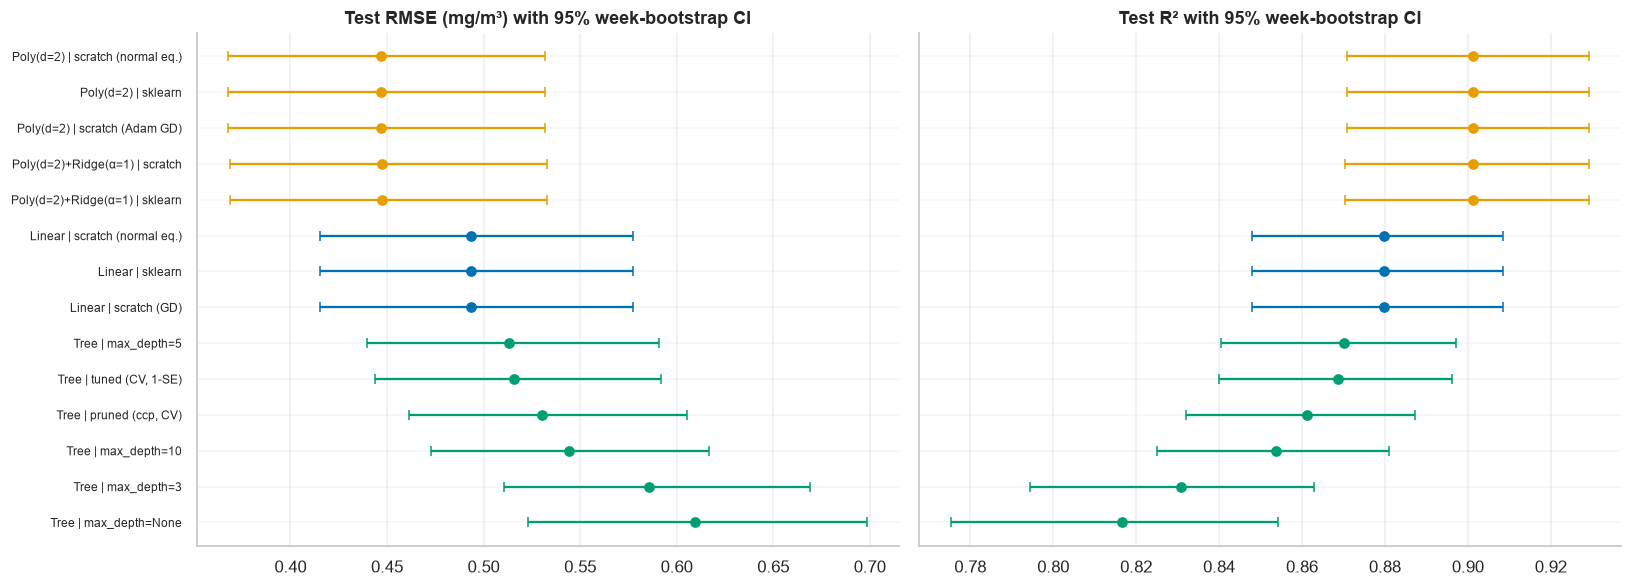

In [44]:
test_weeks = pd.factorize(X_test.index.to_period("W").astype(str))[0]
members = [np.where(test_weeks == w)[0] for w in np.unique(test_weeks)]
rb = np.random.default_rng(SEED)
BOOT_IDX = [np.concatenate([members[i] for i in rb.integers(0, len(members), len(members))]) for _ in range(1000)]
yt_all = y_test.values

def boot_dist(name):
    e = yt_all - PRED[name]["test"]; rm, rr = [], []
    for idx in BOOT_IDX:
        s_res = np.sum(e[idx] ** 2); rm.append(np.sqrt(s_res / len(idx))); rr.append(1 - s_res / np.sum((yt_all[idx] - yt_all[idx].mean()) ** 2))
    return np.array(rm), np.array(rr)

BOOT = {nm: boot_dist(nm) for nm in ORDER}
ci = lambda a: np.percentile(a, [2.5, 97.5])
BOOT_TBL = pd.DataFrame({nm: {"test RMSE": RESULTS[nm]["test_rmse"], "RMSE 95% CI low": ci(BOOT[nm][0])[0], "RMSE 95% CI high": ci(BOOT[nm][0])[1],
                              "test R²": RESULTS[nm]["test_r2"], "R² 95% CI low": ci(BOOT[nm][1])[0], "R² 95% CI high": ci(BOOT[nm][1])[1]} for nm in ORDER}).T
print(f"{len(members)} test weeks resampled with replacement (cluster bootstrap)")
display(BOOT_TBL.style.format(precision=4))

# forest plot (mean baseline omitted: it is ~3x worse and would compress the scale)
fam_col = {"Linear": BLUE, "Polynomial": ORANGE, "Polynomial+Ridge": ORANGE, "Decision Tree": GREEN}
sub = BOOT_TBL.drop(index=N_MEAN).sort_values("test RMSE", ascending=False)
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for a, (m_, lo, hi, ttl) in zip(ax, [("test RMSE", "RMSE 95% CI low", "RMSE 95% CI high", "Test RMSE (mg/m³) with 95% week-bootstrap CI"),
                                       ("test R²", "R² 95% CI low", "R² 95% CI high", "Test R² with 95% week-bootstrap CI")]):
    for i, (nm, r) in enumerate(sub.iterrows()):
        a.errorbar(r[m_], i, xerr=[[r[m_] - r[lo]], [r[hi] - r[m_]]], fmt="o", color=fam_col[RESULTS[nm]["family"]], capsize=3)
    a.set_yticks(range(len(sub))); a.set_yticklabels(sub.index, fontsize=8); a.set_title(ttl); a.grid(axis="y", alpha=.2)
plt.tight_layout(); plt.show()

**Observations.**
- The 95 % week-bootstrap intervals are wide (≈ ±0.08 RMSE) and overlap heavily across models, so **individual intervals cannot separate the models** — the paired differences below are the proper comparison.
- Even so, the intervals confirm that every model is clearly better than the mean baseline (RMSE 1.31–1.53) and that the unrestricted tree (RMSE up to 0.70) and depth 3 (up to 0.67) are the weakest.

In [45]:
# paired differences on identical bootstrap resamples: delta = RMSE(A) - RMSE(B)   (negative -> A better)
cmp_pairs = [("Poly d=2 vs Linear", N_POLY_NE, N_LIN_NE), ("Linear vs Tree depth 5", N_LIN_NE, tree_names[5]), ("Linear vs Tree tuned", N_LIN_NE, N_TREE_T),
             ("Poly d=2 vs Tree tuned", N_POLY_NE, N_TREE_T), ("Tree depth 5 vs depth 3", tree_names[5], tree_names[3]),
             ("Tree depth 5 vs depth 10", tree_names[5], tree_names[10]), ("Tree depth 5 vs None", tree_names[5], tree_names[None]),
             ("Linear vs Poly(d=2)+Ridge", N_LIN_NE, N_PR_SC)]
rows = []
for lbl, a, b in cmp_pairs:
    d = BOOT[a][0] - BOOT[b][0]; lo, hi = ci(d)
    rows.append({"comparison (A vs B)": lbl, "ΔRMSE point": RESULTS[a]["test_rmse"] - RESULTS[b]["test_rmse"], "ΔRMSE 95% CI low": lo, "ΔRMSE 95% CI high": hi,
                 "P(A better)": np.mean(d < 0), "CI excludes 0": bool(lo > 0 or hi < 0)})
PAIRED = pd.DataFrame(rows).set_index("comparison (A vs B)"); display(PAIRED.style.format(precision=4))

# fold-wise CV RMSE (identical group folds) -> paired comparison independent of the test set
FOLD_FACT = {"Mean baseline": lambda: DummyRegressor(), "Linear": make_linear, f"Poly(d={DEG_STAR})": make_poly,
             "Tree depth 3": lambda: DecisionTreeRegressor(max_depth=3, random_state=SEED), "Tree depth 5": lambda: DecisionTreeRegressor(max_depth=5, random_state=SEED),
             "Tree depth 10": lambda: DecisionTreeRegressor(max_depth=10, random_state=SEED), "Tree depth None": lambda: DecisionTreeRegressor(random_state=SEED), "Tree (tuned)": make_tree}
FOLD_RMSE = pd.DataFrame({nm: [rmse(y_train.values[va], mk().fit(X_train_s.values[tr], y_train.values[tr]).predict(X_train_s.values[va])) for tr, va in folds]
                          for nm, mk in FOLD_FACT.items()}, index=[f"fold {i + 1}" for i in range(len(folds))])
FOLD_RMSE.loc["mean"] = FOLD_RMSE.mean(); FOLD_RMSE.loc["sd"] = FOLD_RMSE.iloc[:5].std()
display(FOLD_RMSE.style.format(precision=4))
wins = {c: int((FOLD_RMSE.iloc[:5]["Linear"] < FOLD_RMSE.iloc[:5][c]).sum()) for c in FOLD_RMSE.columns if c.startswith("Tree")}
print("Folds (out of 5) in which Linear beats each tree:", wins)
print("Folds in which Poly beats Linear:", int((FOLD_RMSE.iloc[:5][f'Poly(d={DEG_STAR})'] < FOLD_RMSE.iloc[:5]['Linear']).sum()))

,ΔRMSE point,ΔRMSE 95% CI low,ΔRMSE 95% CI high,P(A better),CI excludes 0
comparison (A vs B),,,,,
Poly d=2 vs Linear,-0.0463,-0.0622,-0.0323,1.0000,True
Linear vs Tree depth 5,-0.0198,-0.0393,0.0006,0.9730,False
Linear vs Tree tuned,-0.0224,-0.0443,-0.0001,0.9750,True
Poly d=2 vs Tree tuned,-0.0686,-0.0914,-0.0437,1.0000,True
Tree depth 5 vs depth 3,-0.0723,-0.1011,-0.0427,1.0000,True
Tree depth 5 vs depth 10,-0.0311,-0.0675,0.0018,0.9650,False
Tree depth 5 vs None,-0.0965,-0.1389,-0.0559,1.0000,True
Linear vs Poly(d=2)+Ridge,0.0459,0.0321,0.0620,0.0000,True


,Mean baseline,Linear,Poly(d=2),Tree depth 3,Tree depth 5,Tree depth 10,Tree depth None,Tree (tuned)
fold 1,1.3566,0.4331,0.3876,0.5289,0.4426,0.5273,0.5646,0.4576
fold 2,1.3765,0.5244,0.5017,0.6302,0.5272,0.6104,0.6715,0.5349
fold 3,1.3205,0.4161,0.4020,0.5448,0.4548,0.5866,0.6432,0.4544
fold 4,1.5136,0.5581,0.4913,0.6106,0.5665,0.6500,0.7300,0.5568
fold 5,1.6215,0.5090,0.4826,0.5719,0.5548,0.6160,0.6872,0.5631
mean,1.4378,0.4882,0.4530,0.5773,0.5092,0.5981,0.6593,0.5134
sd,0.1261,0.0610,0.0538,0.0428,0.0572,0.0456,0.0616,0.0534


Folds (out of 5) in which Linear beats each tree: {'Tree depth 3': 5, 'Tree depth 5': 5, 'Tree depth 10': 5, 'Tree depth None': 5, 'Tree (tuned)': 4}
Folds in which Poly beats Linear: 5


**Observations — paired comparisons (negative Δ ⇒ A better).**
- **Polynomial d=2 beats Linear**: ΔRMSE = −0.046, 95 % CI [−0.062, −0.032], better in 100 % of resamples, and in **5 / 5 CV folds**.
- **Linear beats the Decision Tree, but only modestly**: vs. depth 5 ΔRMSE = −0.020 (CI [−0.039, +0.001], P = 0.97 — borderline, CI just touches 0); vs. the tuned tree −0.022 (CI [−0.044, −0.0001]). In CV, linear is better in **5 / 5 folds against every fixed-depth tree and 4 / 5 against the tuned tree**.
- **Polynomial d=2 beats the tuned tree clearly** (Δ = −0.069, CI excludes 0).
- Within the trees, depth 5 is clearly better than depth 3 and than `None`, but **not significantly better than depth 10** (CI [−0.068, +0.002]).
- The ridge-regularised polynomial is statistically indistinguishable from the unregularised one (Δ test RMSE 0.0004).

### 3.3 Performance metrics vs. epoch (regression models)
Per-epoch train/test **MSE, RMSE and R²** of the two gradient-trained models. Dotted lines mark the closed-form optimum. The number of epochs was fixed beforehand from the *training* loss; the test curve is displayed purely as a diagnostic (it would reveal over-training, i.e. early stopping, if there were any).

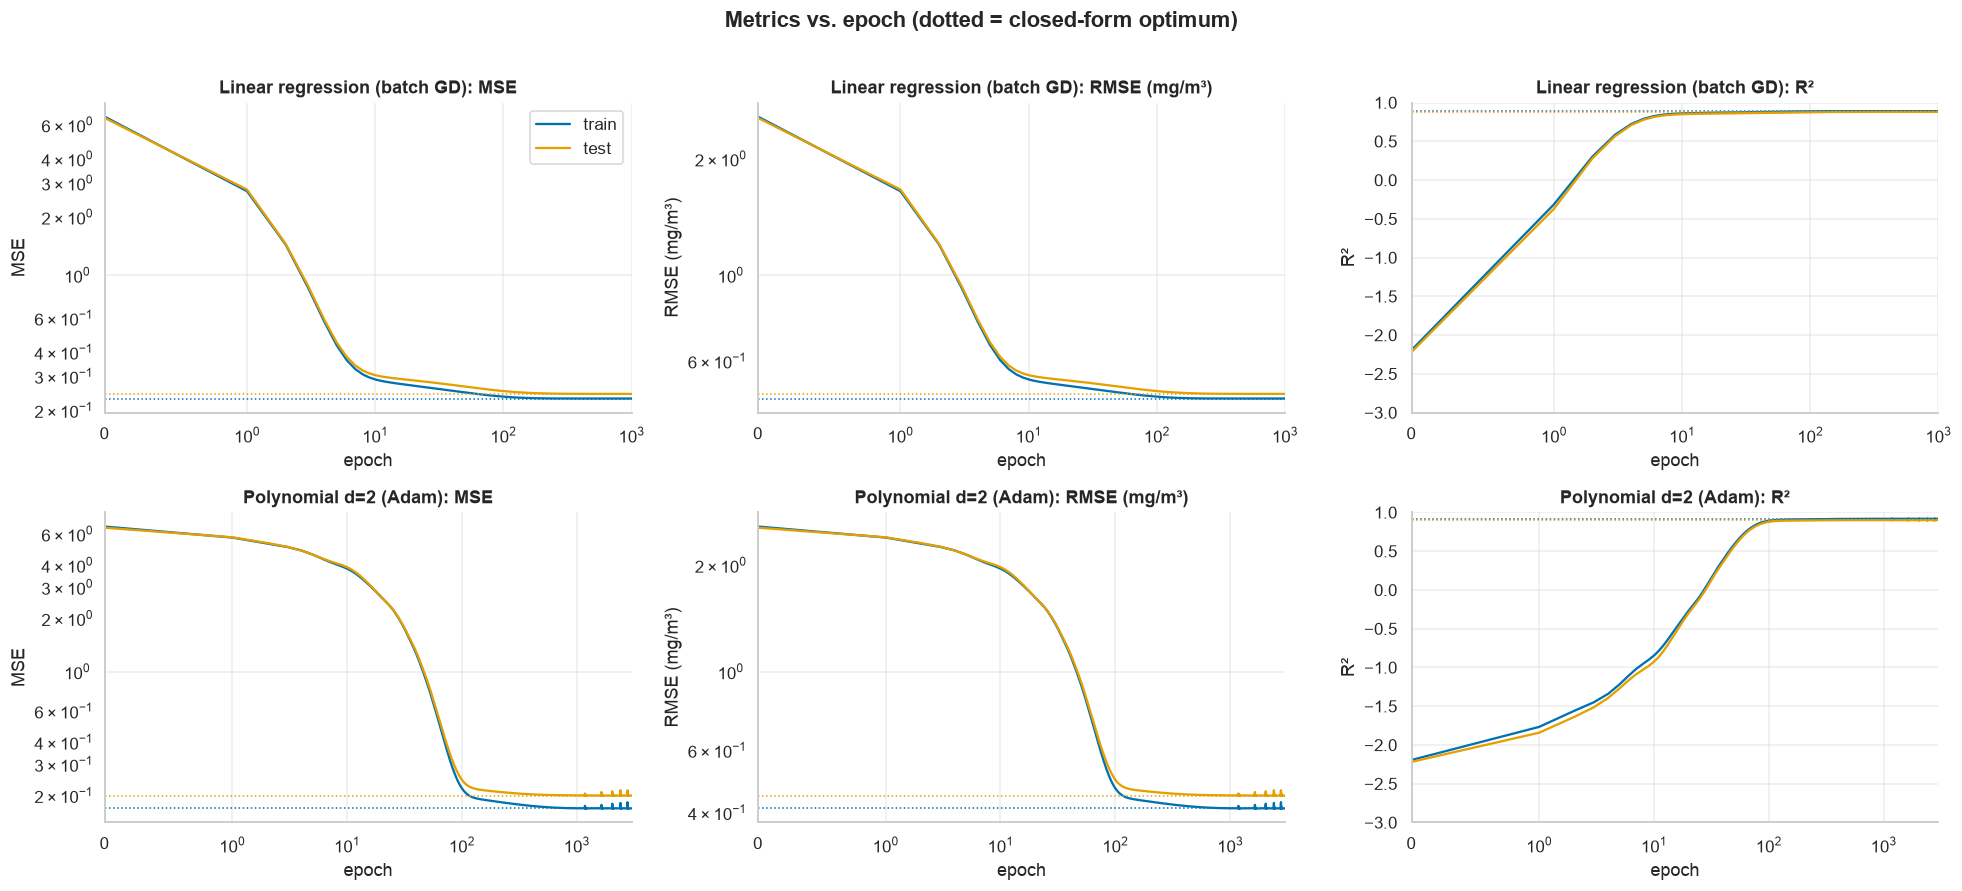

,epochs to 1% of final train MSE,epochs to 0.1%,epoch of minimum TEST RMSE,final epoch,final test RMSE,minimum test RMSE
Linear | scratch (GD),135.0000,233.0000,1000.0000,1000.0000,0.4933,0.4933
Poly(d=2) | scratch (Adam GD),638.0000,1065.0000,2794.0000,3000.0000,0.4470,0.4469


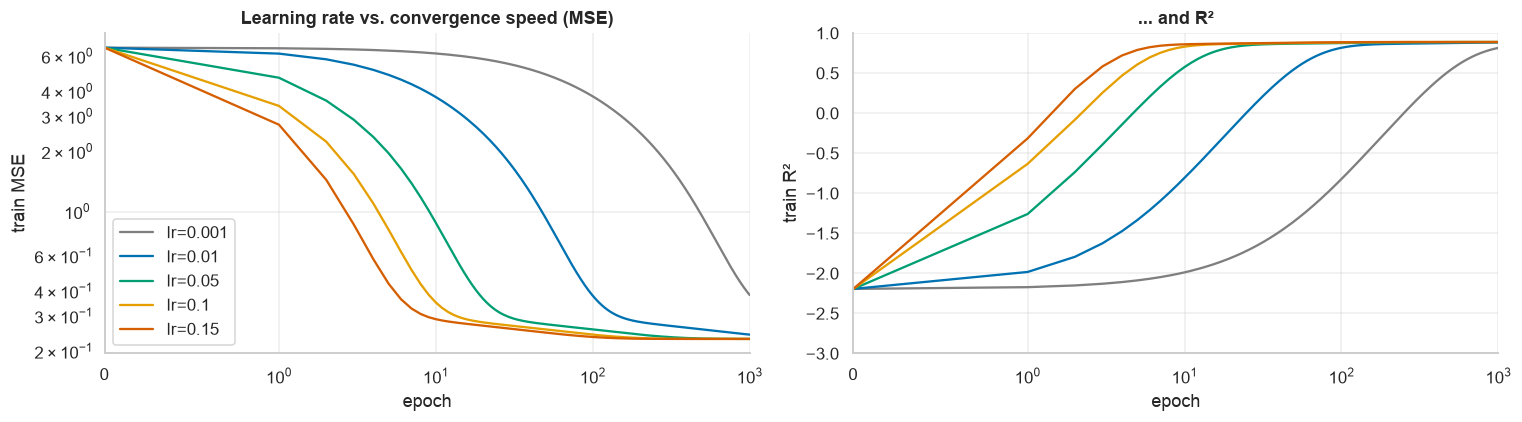

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for r, (nm, ttl, opt) in enumerate([(N_LIN_GD, "Linear regression (batch GD)", N_LIN_NE), (N_POLY_GD, f"Polynomial d={DEG_STAR} (Adam)", N_POLY_NE)]):
    h = HISTORY[nm]
    for c, (met, lab) in enumerate([("mse", "MSE"), ("rmse", "RMSE (mg/m³)"), ("r2", "R²")]):
        a = axes[r, c]
        a.plot(h["epoch"], h[f"train_{met}"], color=BLUE, label="train"); a.plot(h["epoch"], h[f"test_{met}"], color=ORANGE, label="test")
        a.axhline(RESULTS[opt][f"train_{met}"], color=BLUE, ls=":", lw=1); a.axhline(RESULTS[opt][f"test_{met}"], color=ORANGE, ls=":", lw=1)
        a.set_xscale("symlog", linthresh=1); a.set_xlim(0, h["epoch"].max()); a.set_xlabel("epoch"); a.set_ylabel(lab); a.set_title(f"{ttl}: {lab}")
        if met == "r2": a.set_ylim(-3, 1)
        else: a.set_yscale("log")
        if r == 0 and c == 0: a.legend()
plt.suptitle("Metrics vs. epoch (dotted = closed-form optimum)", y=1.01, fontweight="bold"); plt.tight_layout(); plt.show()

chk = [0, 1, 5, 10, 50, 100, 200, 500, 1000, 3000]
rows = []
for nm in (N_LIN_GD, N_POLY_GD):
    h = HISTORY[nm].set_index("epoch")
    for e in [c for c in chk if c in h.index]:
        rows.append({"model": nm, "epoch": e, **{f"{s}_{m_}": h.loc[e, f"{s}_{m_}"] for s in ("train", "test") for m_ in ("mse", "rmse", "r2")}})
display(pd.DataFrame(rows).set_index(["model", "epoch"]).style.format(precision=4))
conv = pd.DataFrame({nm: {"epochs to 1% of final train MSE": epochs_to_tol(HISTORY[nm], tol=0.01), "epochs to 0.1%": epochs_to_tol(HISTORY[nm], tol=0.001),
                          "epoch of minimum TEST RMSE": int(HISTORY[nm].loc[HISTORY[nm]["test_rmse"].idxmin(), "epoch"]), "final epoch": int(HISTORY[nm]["epoch"].max()),
                          "final test RMSE": HISTORY[nm]["test_rmse"].iloc[-1], "minimum test RMSE": HISTORY[nm]["test_rmse"].min()} for nm in (N_LIN_GD, N_POLY_GD)}).T
display(conv.style.format(precision=4))

# effect of the learning rate on the per-epoch curves (training metrics, linear model)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for lr, c in zip([0.001, 0.01, 0.05, 0.1, 0.15], [GREY, BLUE, GREEN, ORANGE, RED]):
    h = lr_hist[lr]; ax[0].plot(h["epoch"], h["train_mse"], color=c, label=f"lr={lr}"); ax[1].plot(h["epoch"], h["train_r2"], color=c, label=f"lr={lr}")
for a, lab in zip(ax, ["train MSE", "train R²"]): a.set_xscale("symlog", linthresh=1); a.set_xlim(0, EPOCHS_LIN); a.set_xlabel("epoch"); a.set_ylabel(lab)
ax[0].set_yscale("log"); ax[1].set_ylim(-3, 1); ax[0].legend(); ax[0].set_title("Learning rate vs. convergence speed (MSE)"); ax[1].set_title("... and R²")
plt.tight_layout(); plt.show()

**Observations — metrics vs. epoch.**
- **Linear (batch GD):** MSE falls from 6.62 to within 1 % of its final value in **135 epochs** (0.1 % in 233) and then follows the closed-form optimum exactly (train RMSE 0.4799, test 0.4933). Train and test curves move together at every epoch, so there is **no over-training** — the test minimum is at the last epoch and early stopping would not help.
- **Polynomial (Adam):** much slower start (R² still −0.85 after 10 epochs; it needs ≈ 100 epochs to reach R² ≈ 0.88) and ≈ 640 epochs to settle within 1 %; it ends at the closed-form optimum (test RMSE 0.4470). The train–test gap is slightly larger than for the linear model, in line with its extra capacity. The small transient spikes after epoch ~1,000 are typical of Adam's adaptive steps; the loss recovers immediately.
- The learning-rate plot shows the expected trade-off: `lr = 0.001` has barely begun to converge after 1,000 epochs while `lr = 0.15` converges in about 100.

### 3.4 Performance metrics vs. tree depth
Train, CV and test **MSE, RMSE and R²** for depths 1–20 and `None` (plotted at its effective depth, 28). The four depths required by the assignment (3, 5, 10, `None`) are marked.

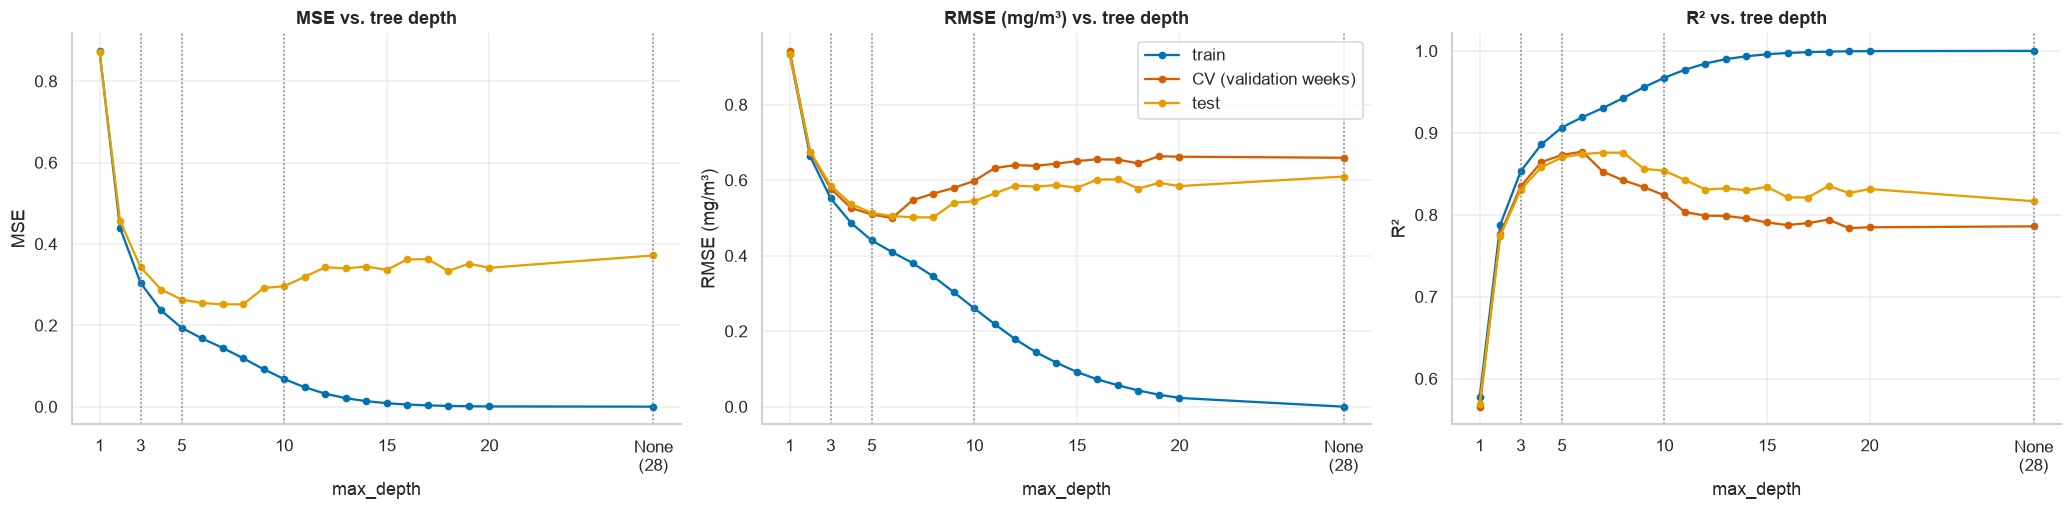

,depth_actual,n_leaves,train_mse,train_rmse,train_r2,test_mse,test_rmse,test_r2,cv_rmse,cv_r2
max_depth,,,,,,,,,,
3,3,8,0.3042,0.5515,0.8532,0.3427,0.5854,0.8308,0.5773,0.8347
5,5,32,0.1938,0.4403,0.9065,0.2633,0.5131,0.8700,0.5092,0.8730
10,10,693,0.0678,0.2603,0.9673,0.2961,0.5442,0.8538,0.5981,0.8236
None,28,4245,0.0000,0.0000,1.0000,0.3716,0.6096,0.8165,0.6593,0.7859


CV-optimal depth: 6 (CV RMSE 0.4998, test RMSE 0.5049) | test-optimal depth (hindsight only): 7 (test RMSE 0.5014)


In [47]:
TS = TREE_SWEEP.copy(); x = TS["depth_actual"]
TS["cv_mse"] = TS["cv_rmse"] ** 2                       # (mean-of-RMSE)^2: a close proxy for CV MSE
fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))
for a, (met, lab) in zip(axes, [("mse", "MSE"), ("rmse", "RMSE (mg/m³)"), ("r2", "R²")]):
    a.plot(x, TS[f"train_{met}"], color=BLUE, marker="o", ms=4, label="train")
    if met != "mse": a.plot(x, TS[f"cv_{met}"], color=RED, marker="o", ms=4, label="CV (validation weeks)")
    a.plot(x, TS[f"test_{met}"], color=ORANGE, marker="o", ms=4, label="test")
    for d in (3, 5, 10, 28): a.axvline(d, color=GREY, ls=":", lw=1)
    a.set_xticks([1, 3, 5, 10, 15, 20, 28]); a.set_xticklabels(["1", "3", "5", "10", "15", "20", "None\n(28)"]); a.set_xlabel("max_depth"); a.set_ylabel(lab); a.set_title(f"{lab} vs. tree depth")
axes[1].legend(); plt.tight_layout(); plt.show()

req_tbl = TS[TS["max_depth"].astype(str).isin(["3", "5", "10", "None"])].set_index("max_depth")[["depth_actual", "n_leaves", "train_mse", "train_rmse", "train_r2", "test_mse", "test_rmse", "test_r2", "cv_rmse", "cv_r2"]]
display(req_tbl.style.format(precision=4).set_caption("Required depths"))
opt_cv = TS.loc[TS["cv_rmse"].idxmin()]; opt_te = TS.loc[TS["test_rmse"].idxmin()]
print(f"CV-optimal depth: {int(opt_cv['depth_actual'])} (CV RMSE {opt_cv['cv_rmse']:.4f}, test RMSE {opt_cv['test_rmse']:.4f}) | "
      f"test-optimal depth (hindsight only): {int(opt_te['depth_actual'])} (test RMSE {opt_te['test_rmse']:.4f})")

**Observations — metrics vs. tree depth.**
- Training error decreases monotonically to exactly 0 (R² = 1) at `None`; test/CV error is **U-shaped**: it drops quickly until depth ≈ 5–6 and then rises as the tree starts to memorise noise.
- Required depths: **3 → under-fit** (test RMSE 0.585), **5 → good** (0.513, R² 0.870), **10 → over-fit** (0.544, train RMSE 0.260), **`None` → worst** (0.610, 4,245 leaves).
- The CV-optimal depth is 6 (CV RMSE 0.500, test 0.505); the test-optimal depth in hindsight is 7 (0.501), but the difference between depths 5–8 on test is negligible, so the choice of ≈ 5–6 is robust. The CV curve is a little sharper than the test curve because validation folds are whole weeks and therefore harder than interleaved test hours.

### 3.5 Residual diagnostics
For the three main model families (Linear, Polynomial d=2, Tree depth 5) on the **test set**: predicted vs. actual, residuals vs. fitted, residual distribution and Q-Q plot, and residuals over time. Residual = actual − predicted (positive ⇒ under-prediction).

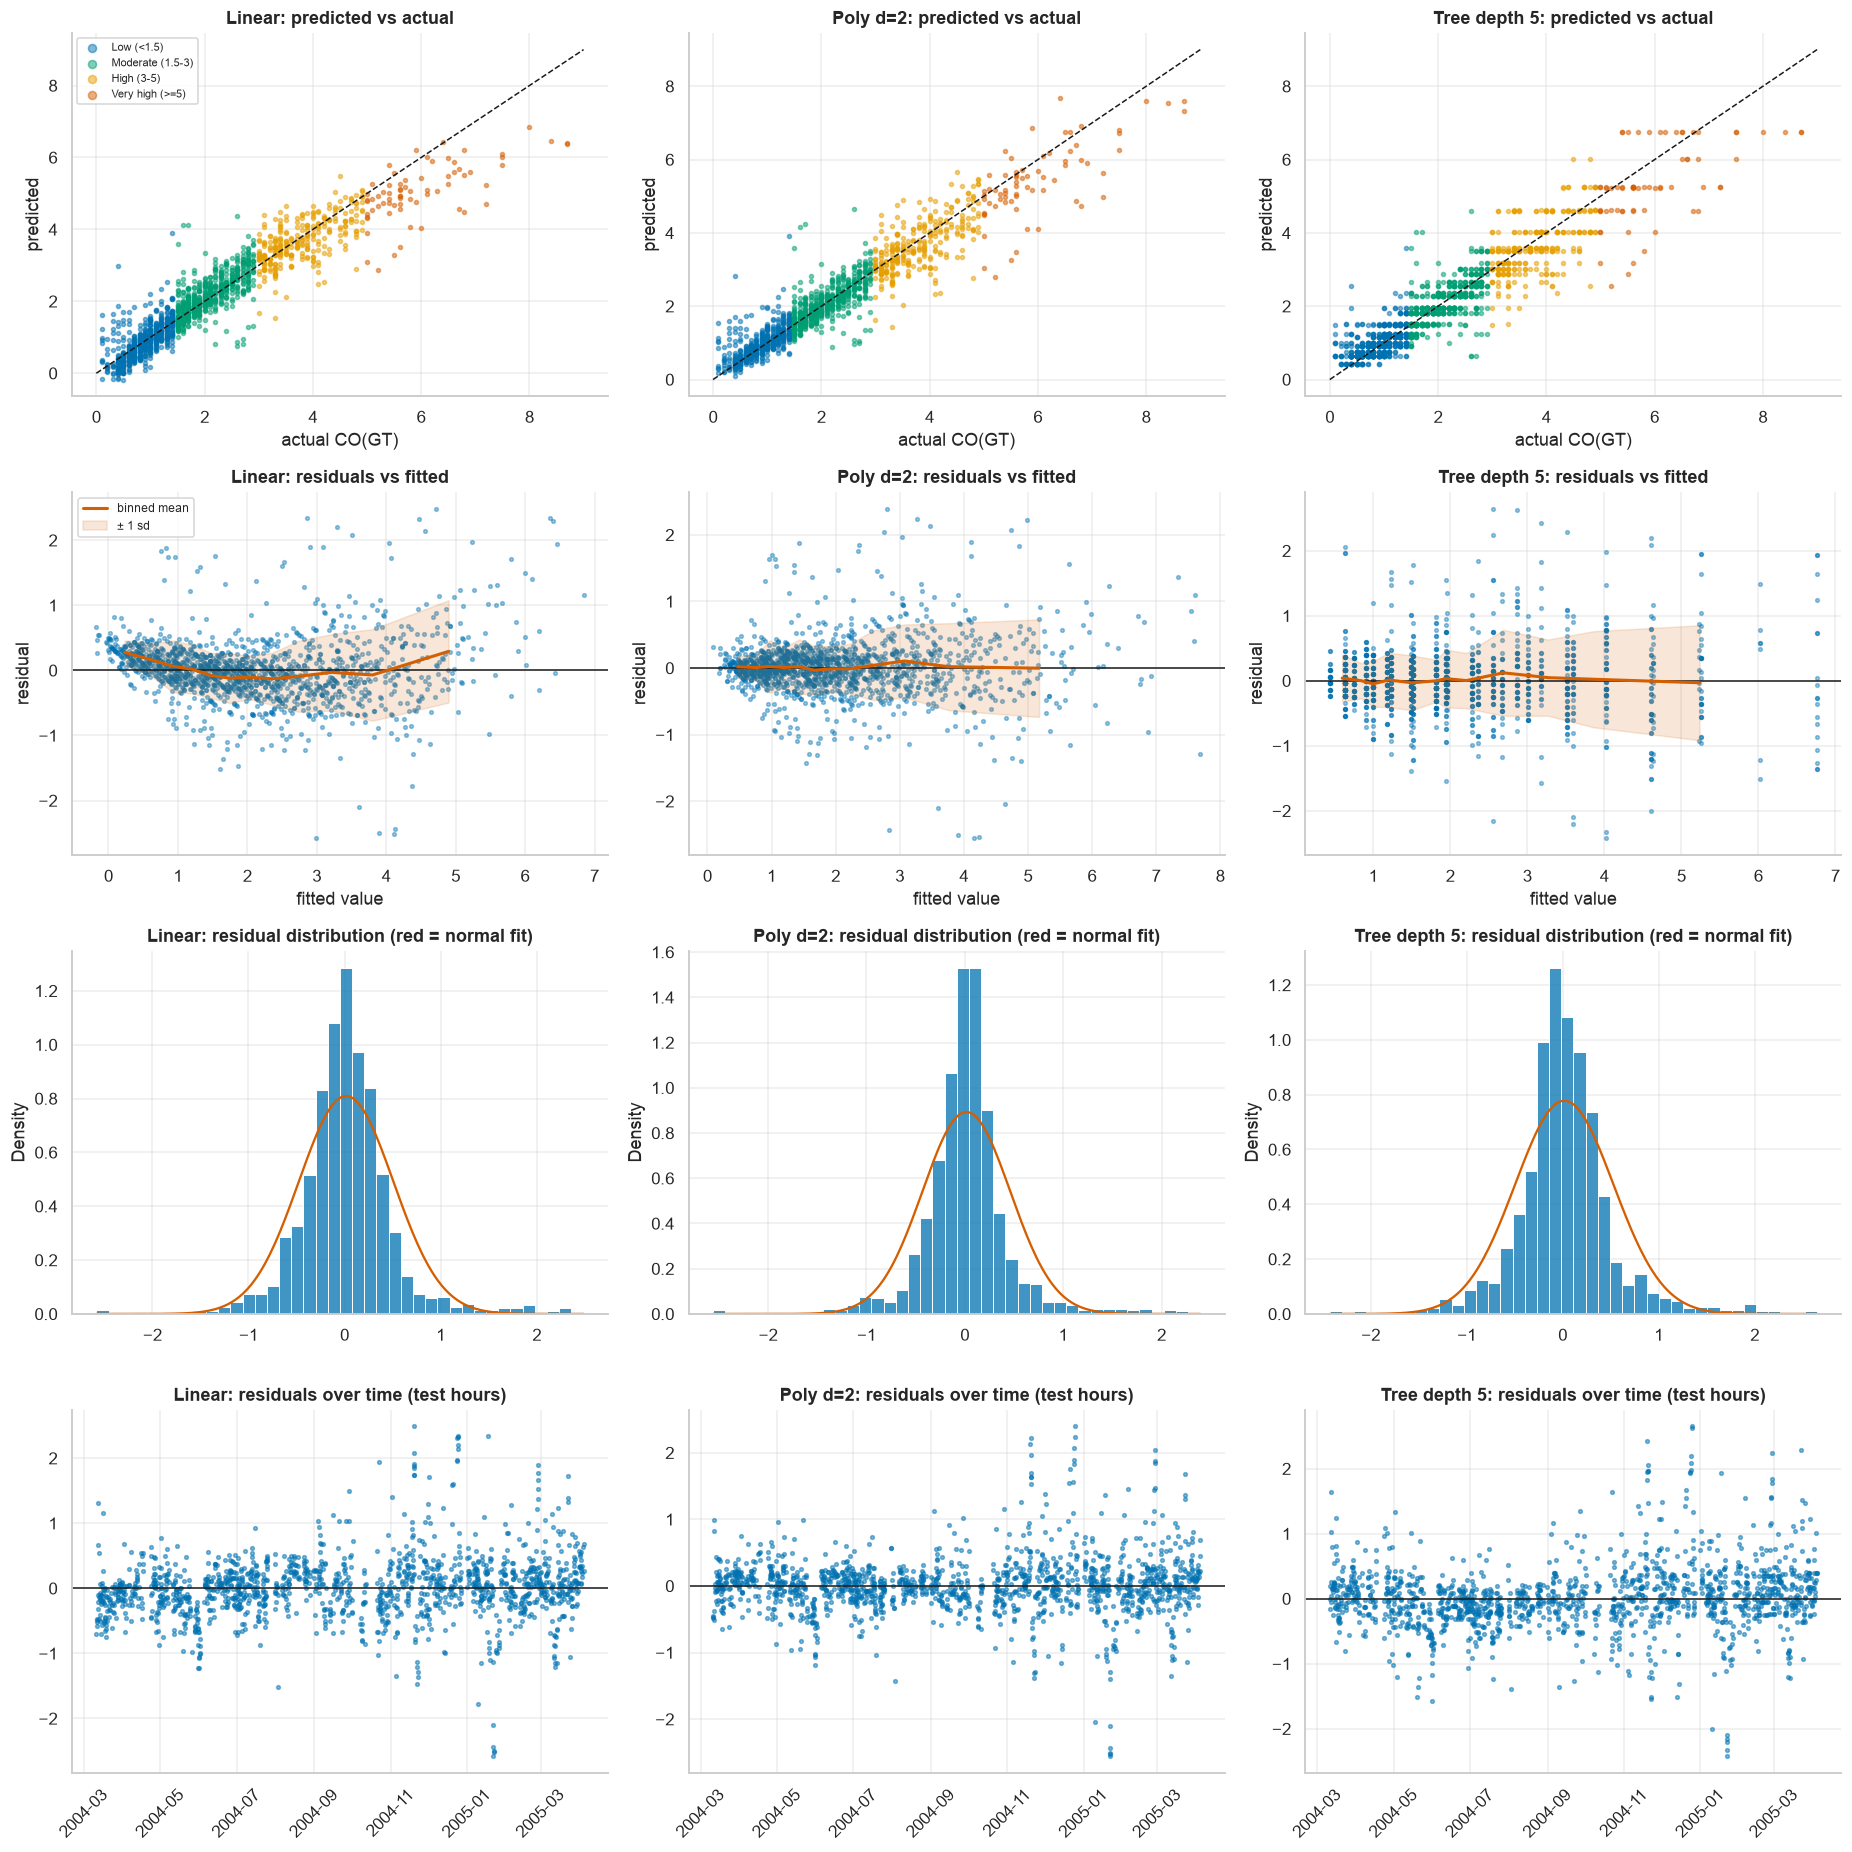

,mean residual,sd,skew,excess kurtosis,Shapiro p,"ρ(|res|, fitted)",sd low/mid/high fitted,max |res|
model,,,,,,,,
Linear,0.016,0.493,0.483,5.407,4.6e-28,0.241,0.33 / 0.37 / 0.68,2.583
Poly d=2,0.016,0.447,0.259,7.146,3.4e-32,0.383,0.28 / 0.37 / 0.62,2.559
Tree depth 5,0.016,0.513,0.563,4.665,2.1e-27,0.296,0.35 / 0.41 / 0.72,2.649


In [48]:
DIAG = [(N_LIN_NE, "Linear"), (N_POLY_NE, f"Poly d={DEG_STAR}"), (tree_names[5], "Tree depth 5")]
reg_col = dict(zip(bands_labels, [BLUE, GREEN, ORANGE, RED]))
bt = pd.cut(y_test, bands_edges, labels=bands_labels, right=False)
fig, axes = plt.subplots(4, 3, figsize=(17, 17))
for j, (nm, ttl) in enumerate(DIAG):
    p, res = PRED[nm]["test"], yt_all - PRED[nm]["test"]
    for b in bands_labels:
        m_ = (bt == b).values; axes[0, j].scatter(yt_all[m_], p[m_], s=7, alpha=.5, color=reg_col[b], label=b)
    axes[0, j].plot([0, 9], [0, 9], "k--", lw=1); axes[0, j].set_xlabel("actual CO(GT)"); axes[0, j].set_ylabel("predicted"); axes[0, j].set_title(f"{ttl}: predicted vs actual")
    axes[1, j].scatter(p, res, s=6, alpha=.4, color=BLUE); axes[1, j].axhline(0, color="k", lw=1)
    q = pd.qcut(p, 12, duplicates="drop"); g = pd.DataFrame({"p": p, "r": res}).groupby(q, observed=True).agg(p=("p", "mean"), m=("r", "mean"), s=("r", "std"))
    axes[1, j].plot(g["p"], g["m"], color=RED, lw=2, label="binned mean"); axes[1, j].fill_between(g["p"], g["m"] - g["s"], g["m"] + g["s"], color=RED, alpha=.15, label="± 1 sd")
    axes[1, j].set_xlabel("fitted value"); axes[1, j].set_ylabel("residual"); axes[1, j].set_title(f"{ttl}: residuals vs fitted")
    sns.histplot(res, bins=40, stat="density", color=BLUE, ax=axes[2, j], edgecolor="white")
    xs = np.linspace(res.min(), res.max(), 200); axes[2, j].plot(xs, stats.norm.pdf(xs, res.mean(), res.std()), color=RED); axes[2, j].set_title(f"{ttl}: residual distribution (red = normal fit)")
    axes[3, j].scatter(y_test.index, res, s=6, alpha=.5, color=BLUE); axes[3, j].axhline(0, color="k", lw=1); axes[3, j].set_title(f"{ttl}: residuals over time (test hours)"); axes[3, j].tick_params(axis="x", rotation=45)
axes[0, 0].legend(fontsize=7, markerscale=2); axes[1, 0].legend(fontsize=8)
plt.tight_layout(); plt.show()

rows = []
for nm, ttl in DIAG:
    p, res = PRED[nm]["test"], yt_all - PRED[nm]["test"]; terc = pd.qcut(p, 3, labels=["low", "mid", "high"], duplicates="drop")
    sd_t = pd.Series(res).groupby(terc, observed=True).std()
    rows.append({"model": ttl, "mean residual": res.mean(), "sd": res.std(), "skew": stats.skew(res), "excess kurtosis": stats.kurtosis(res),
                 "Shapiro p": stats.shapiro(res)[1], "ρ(|res|, fitted)": stats.spearmanr(np.abs(res), p)[0],
                 "sd low/mid/high fitted": " / ".join(f"{v:.2f}" for v in sd_t.values), "max |res|": np.abs(res).max()})
RESID_STATS = pd.DataFrame(rows).set_index("model"); display(RESID_STATS.style.format({c: "{:.3f}" for c in RESID_STATS.columns if c not in ("sd low/mid/high fitted", "Shapiro p")} | {"Shapiro p": "{:.1e}"}))

**Observations — residual diagnostics.**
- **Linear model:** the residuals-vs-fitted plot shows a **curved (U-shaped) bias** — positive residuals (under-prediction) at low *and* high fitted values, negative in the middle. This is direct evidence of **non-linearity** that a straight line cannot capture; the polynomial model's binned mean residual is essentially flat around zero.
- **Tree:** predictions form horizontal bands (a piecewise-constant function, only 32 distinct values), so it cannot reproduce the smooth relation and its predicted-vs-actual plot is visibly stair-stepped; it also **flattens at ≈ 6.8 mg/m³**, never predicting the highest values.
- **All models are heteroscedastic**: the residual spread roughly doubles from low to high fitted values (e.g. linear sd 0.33 → 0.68), and |residual| correlates positively with the fitted value (ρ = 0.24–0.38).
- Residuals are **heavy-tailed and right-skewed** (excess kurtosis 4.7–7.1, skew 0.26–0.56; the Shapiro test rejects normality), so confidence statements that assume Gaussian errors would be unreliable — one more reason for using the bootstrap above.
- Mean residuals are +0.016 for all models (i.e. unbiased overall); the problem is in the tails, not the centre.
- Residuals over time show clusters of large errors in winter (Nov–Feb) rather than a drift.

### 3.6 Where do the errors occur? — CO regime, hour of day and month
The brief only restricts the *features*, so hour-of-day is not a model input; plotting the residuals against it is a diagnostic that tells us what structure the sensor/weather features do **not** capture.

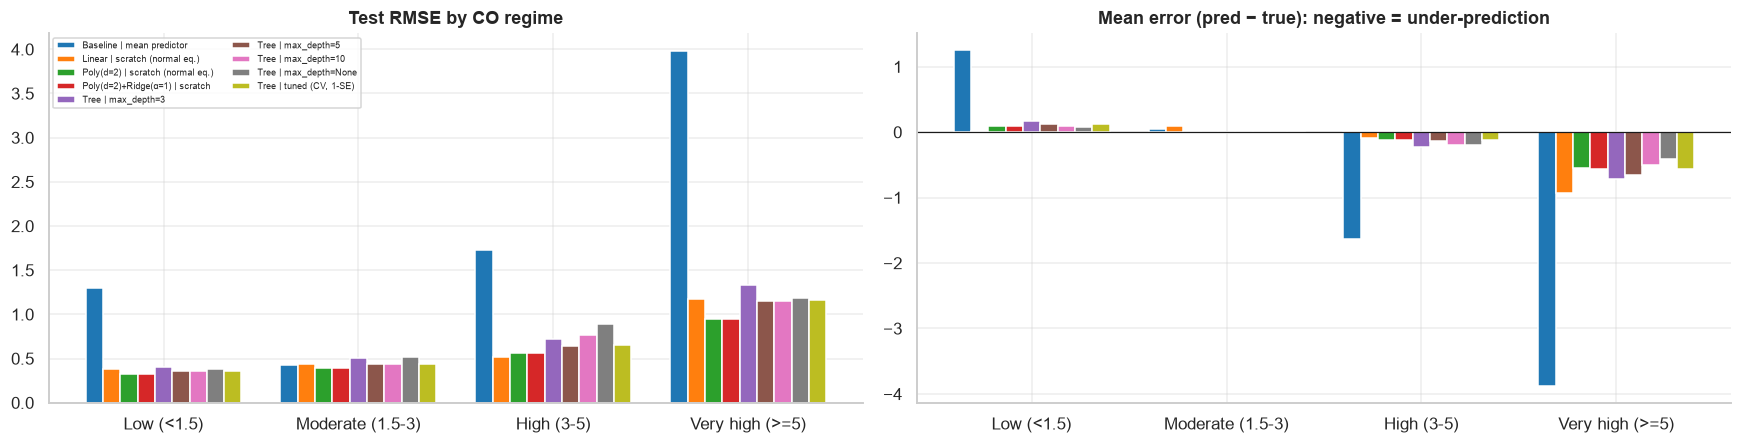

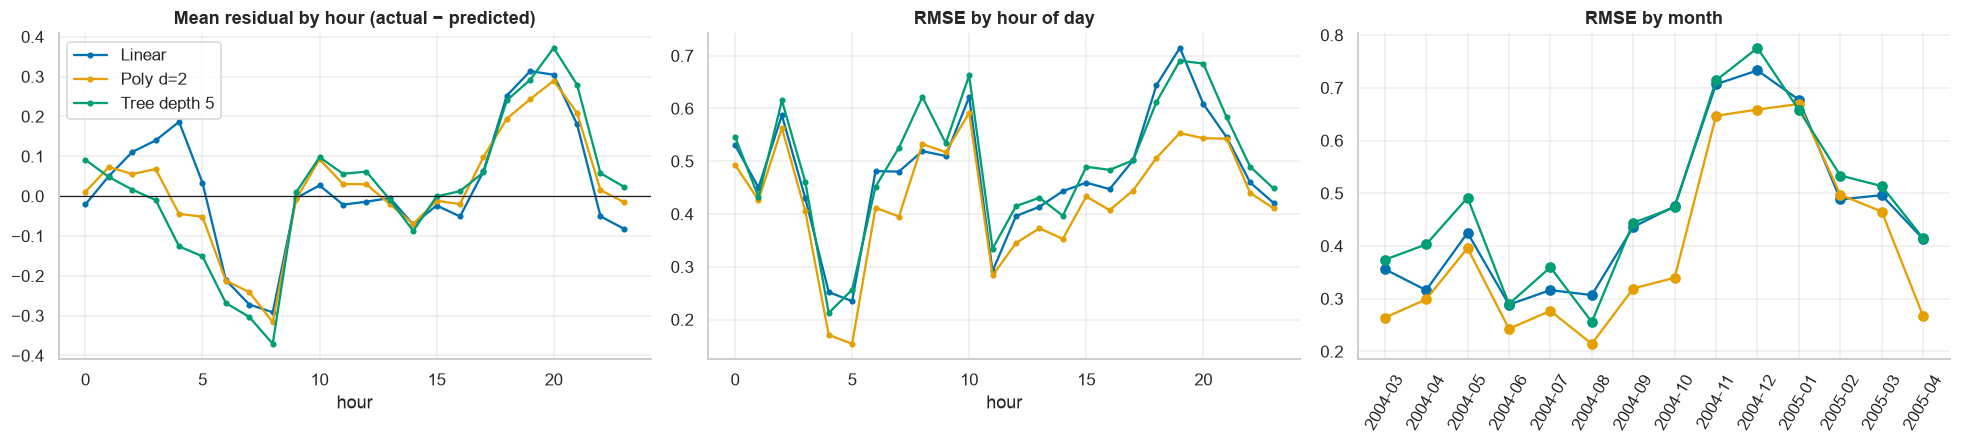

Largest mean residual by hour (rush hours)  -> {8: 0.326, 20: 0.322, 19: 0.283, 7: 0.272, 6: 0.231}


In [49]:
# (a) per-regime test RMSE and bias (from Stage 2)
fig, ax = plt.subplots(1, 2, figsize=(16, 4.2)); w = 0.8 / len(FINAL)
pr = REGIME.pivot(index="model", columns="regime", values="rmse")[bands_labels].loc[FINAL]; pb = REGIME.pivot(index="model", columns="regime", values="bias (pred-true)")[bands_labels].loc[FINAL]
pal = sns.color_palette("tab10", len(FINAL))
for i, nm in enumerate(FINAL):
    ax[0].bar(np.arange(4) + i * w, pr.loc[nm], w, color=pal[i], label=nm); ax[1].bar(np.arange(4) + i * w, pb.loc[nm], w, color=pal[i])
for a, t in zip(ax, ["Test RMSE by CO regime", "Mean error (pred − true): negative = under-prediction"]): a.set_xticks(np.arange(4) + 0.4 - w / 2); a.set_xticklabels(bands_labels); a.set_title(t)
ax[1].axhline(0, color="k", lw=.8); ax[0].legend(fontsize=6, ncol=2); plt.tight_layout(); plt.show()

# (b) residuals by hour of day and by month (test set)
sel = [(N_LIN_NE, "Linear", BLUE), (N_POLY_NE, f"Poly d={DEG_STAR}", ORANGE), (tree_names[5], "Tree depth 5", GREEN)]
fig, ax = plt.subplots(1, 3, figsize=(18, 4.2))
for nm, ttl, c in sel:
    r_ = pd.Series(yt_all - PRED[nm]["test"], index=y_test.index)
    ax[0].plot(r_.groupby(r_.index.hour).mean(), color=c, marker="o", ms=3, label=ttl)
    ax[1].plot(r_.groupby(r_.index.hour).apply(lambda s: np.sqrt((s ** 2).mean())), color=c, marker="o", ms=3, label=ttl)
    mo = r_.groupby(r_.index.to_period("M")).apply(lambda s: np.sqrt((s ** 2).mean())); ax[2].plot(mo.index.astype(str), mo.values, color=c, marker="o", label=ttl)
ax[0].axhline(0, color="k", lw=.8); ax[0].set_title("Mean residual by hour (actual − predicted)"); ax[1].set_title("RMSE by hour of day"); ax[2].set_title("RMSE by month"); ax[2].tick_params(axis="x", rotation=60)
for a in ax[:2]: a.set_xlabel("hour")
ax[0].legend(); plt.tight_layout(); plt.show()
hr = pd.DataFrame({ttl: pd.Series(yt_all - PRED[nm]["test"], index=y_test.index).groupby(y_test.index.hour).mean() for nm, ttl, _ in sel})
print("Largest mean residual by hour (rush hours)  ->", hr.abs().mean(axis=1).sort_values(ascending=False).head(5).round(3).to_dict())

**Observations.**
- **Regime:** the RMSE rises from ≈ 0.33–0.40 (Low) to ≈ 0.95–1.33 (Very high), and every model has a large negative bias for *Very high* hours (under-prediction) — see Stage 2; the bias is −0.93 for linear versus about −0.56 for the polynomial and tuned tree (the deeper trees are less biased there, −0.41 to −0.50, at the cost of overfitting elsewhere).
- **Hour of day:** all three models share the same systematic pattern — they **under-predict in the evening (18–21 h; mean residual up to +0.3 mg/m³)** and **over-predict in the early morning rush (06–08 h; down to −0.3)**. Because hour-of-day is not a feature, this is structure the sensor/weather variables cannot explain (for example lagged sensor response or traffic that the sensors see only later). RMSE peaks at 19 h (0.55–0.72) and is smallest at 04–05 h and 11 h.
- **Month:** RMSE is 2–3× larger in **Nov–Jan (0.65–0.77)** than in summer (0.21–0.36), tracking the higher and more variable CO of the cold season; the polynomial model is the most stable.
- Together with the heteroscedasticity above, this suggests that an hour-of-day feature or a model of the error variance would be the first extensions (outside the scope of the brief).

### 3.7 Evaluation summary — accuracy vs. complexity vs. cost

,family,complexity,fit_time_s,test_rmse,test_r2,cv_rmse,rmse_gap (test-train),RMSE 95% CI,rank (test RMSE)
Poly(d=2) | scratch (normal eq.),Polynomial,45.0000,0.0046,0.4470,0.9013,0.4530,0.0359,"[0.368, 0.532]",1
Poly(d=2) | sklearn,Polynomial,45.0000,0.0058,0.4470,0.9013,–,0.0359,"[0.368, 0.532]",2
Poly(d=2) | scratch (Adam GD),Polynomial,45.0000,0.7215,0.4470,0.9013,–,0.0359,"[0.368, 0.532]",3
Poly(d=2)+Ridge(α=1) | scratch,Polynomial+Ridge,45.0000,0.0019,0.4474,0.9012,0.4516,0.0360,"[0.369, 0.533]",4
Poly(d=2)+Ridge(α=1) | sklearn,Polynomial+Ridge,45.0000,0.0037,0.4474,0.9012,–,0.0360,"[0.369, 0.533]",5
Linear | scratch (normal eq.),Linear,9.0000,0.0005,0.4933,0.8799,0.4882,0.0134,"[0.415, 0.577]",6
Linear | sklearn,Linear,9.0000,0.0026,0.4933,0.8799,–,0.0134,"[0.415, 0.577]",7
Linear | scratch (GD),Linear,9.0000,0.0710,0.4933,0.8799,–,0.0134,"[0.415, 0.577]",8
Tree | max_depth=5,Decision Tree,32.0000,0.0098,0.5131,0.8700,0.5092,0.0728,"[0.440, 0.591]",9
"Tree | tuned (CV, 1-SE)",Decision Tree,29.0000,0.0104,0.5157,0.8687,0.5134,0.0459,"[0.444, 0.592]",10


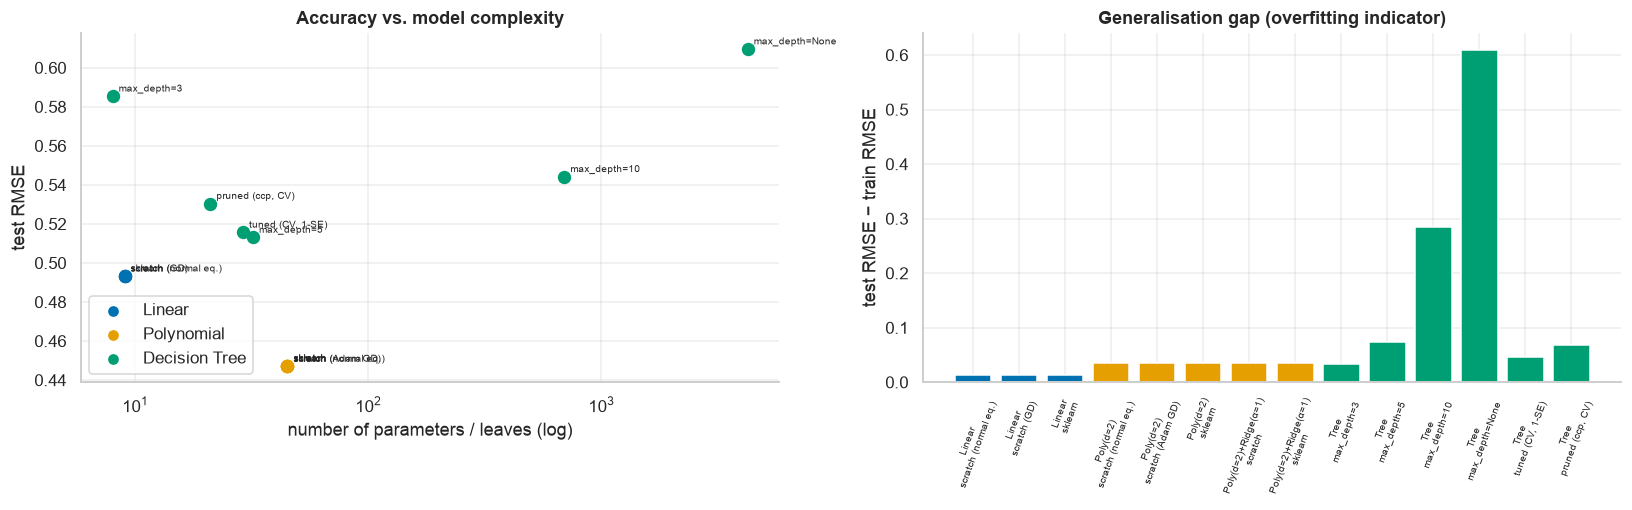

In [50]:
SUMMARY = MASTER[["family", "complexity", "fit_time_s", "test_rmse", "test_r2", "cv_rmse", "rmse_gap (test-train)"]].astype(
    {"complexity": float, "fit_time_s": float, "test_rmse": float, "test_r2": float, "cv_rmse": float, "rmse_gap (test-train)": float}, errors="ignore").copy()
SUMMARY["RMSE 95% CI"] = [f"[{BOOT_TBL.loc[n, 'RMSE 95% CI low']:.3f}, {BOOT_TBL.loc[n, 'RMSE 95% CI high']:.3f}]" for n in SUMMARY.index]
SUMMARY["rank (test RMSE)"] = SUMMARY["test_rmse"].rank(method="min").astype(int)
display(SUMMARY.sort_values("test_rmse").style.format(precision=4, na_rep="–"))

fig, ax = plt.subplots(1, 2, figsize=(15, 4.8))
s_ = SUMMARY.drop(index=N_MEAN)
for nm, r in s_.iterrows(): ax[0].scatter(r["complexity"], r["test_rmse"], s=60, color=fam_col[r["family"]]); ax[0].annotate(nm.split(" | ")[-1] if r["family"] != "Decision Tree" else nm.replace("Tree | ", ""), (r["complexity"], r["test_rmse"]), fontsize=6.5, xytext=(4, 3), textcoords="offset points")
ax[0].set_xscale("log"); ax[0].set_xlabel("number of parameters / leaves (log)"); ax[0].set_ylabel("test RMSE"); ax[0].set_title("Accuracy vs. model complexity")
for fam, c in [("Linear", BLUE), ("Polynomial", ORANGE), ("Decision Tree", GREEN)]: ax[0].scatter([], [], color=c, label=fam)
ax[0].legend()
ax[1].bar(range(len(s_)), s_["rmse_gap (test-train)"], color=[fam_col[f] for f in s_["family"]]); ax[1].set_xticks(range(len(s_))); ax[1].set_xticklabels([n.replace(" | ", "\n") for n in s_.index], rotation=70, fontsize=6.5)
ax[1].set_ylabel("test RMSE − train RMSE"); ax[1].set_title("Generalisation gap (overfitting indicator)"); plt.tight_layout(); plt.show()

**Observations.**
- **Accuracy vs. complexity:** the polynomial d=2 model is the most accurate with only 45 parameters; the linear model is next with 9 parameters; the best tree needs ≈ 30 leaves and is still behind. Beyond ≈ 30 leaves, extra complexity (693 and 4,245 leaves) *hurts*.
- **Generalisation gap:** linear 0.013, polynomial 0.036, trees 0.034–0.610 — it grows with tree depth.
- **Cost:** all closed-form fits take milliseconds; the from-scratch gradient-based fits cost ≈ 0.08 s (linear GD) and ≈ 0.66 s (polynomial Adam), i.e. roughly 150× slower than their closed forms for identical results, which is why the closed form is the practical choice here.
- **Ranking by test RMSE:** Poly d=2 (0.447) < Linear (0.493) < Tree depth 5 (0.513) ≈ tuned tree (0.516) < pruned tree (0.530) < depth 10 (0.544) < depth 3 (0.585) < `None` (0.610) ≪ mean predictor (1.423).

✅ **Stage 3 complete** — required metrics for all models, epoch and depth curves, uncertainty and residual analysis.

---
## Stage 4 — Model Visualization

| Section | Content |
|---|---|
| 4.1 | **Decision tree plot for `max_depth = 3`** (thresholds shown in original sensor units), rule list and leaf summary |
| 4.2 | **Feature importances** from four independent methods and their agreement |
| 4.3 | Grouped permutation importance (needed because the sensors are collinear — Stage 1) |
| 4.4 | Partial-dependence curves: how do the models use the top features? |
| 4.5 | A pollution episode reconstructed by the models |

### 4.1 The decision tree for `max_depth = 3`
Trees are scale-invariant (verified in Stage 2), so for readability the depth-3 tree is re-fitted on the **unscaled** features: its split thresholds are then in real sensor units. The assertion confirms that it makes exactly the same predictions as the tree trained on standardised data.

Raw-unit tree predictions == standardised-data tree ✔  | leaves: 8 | depth: 3


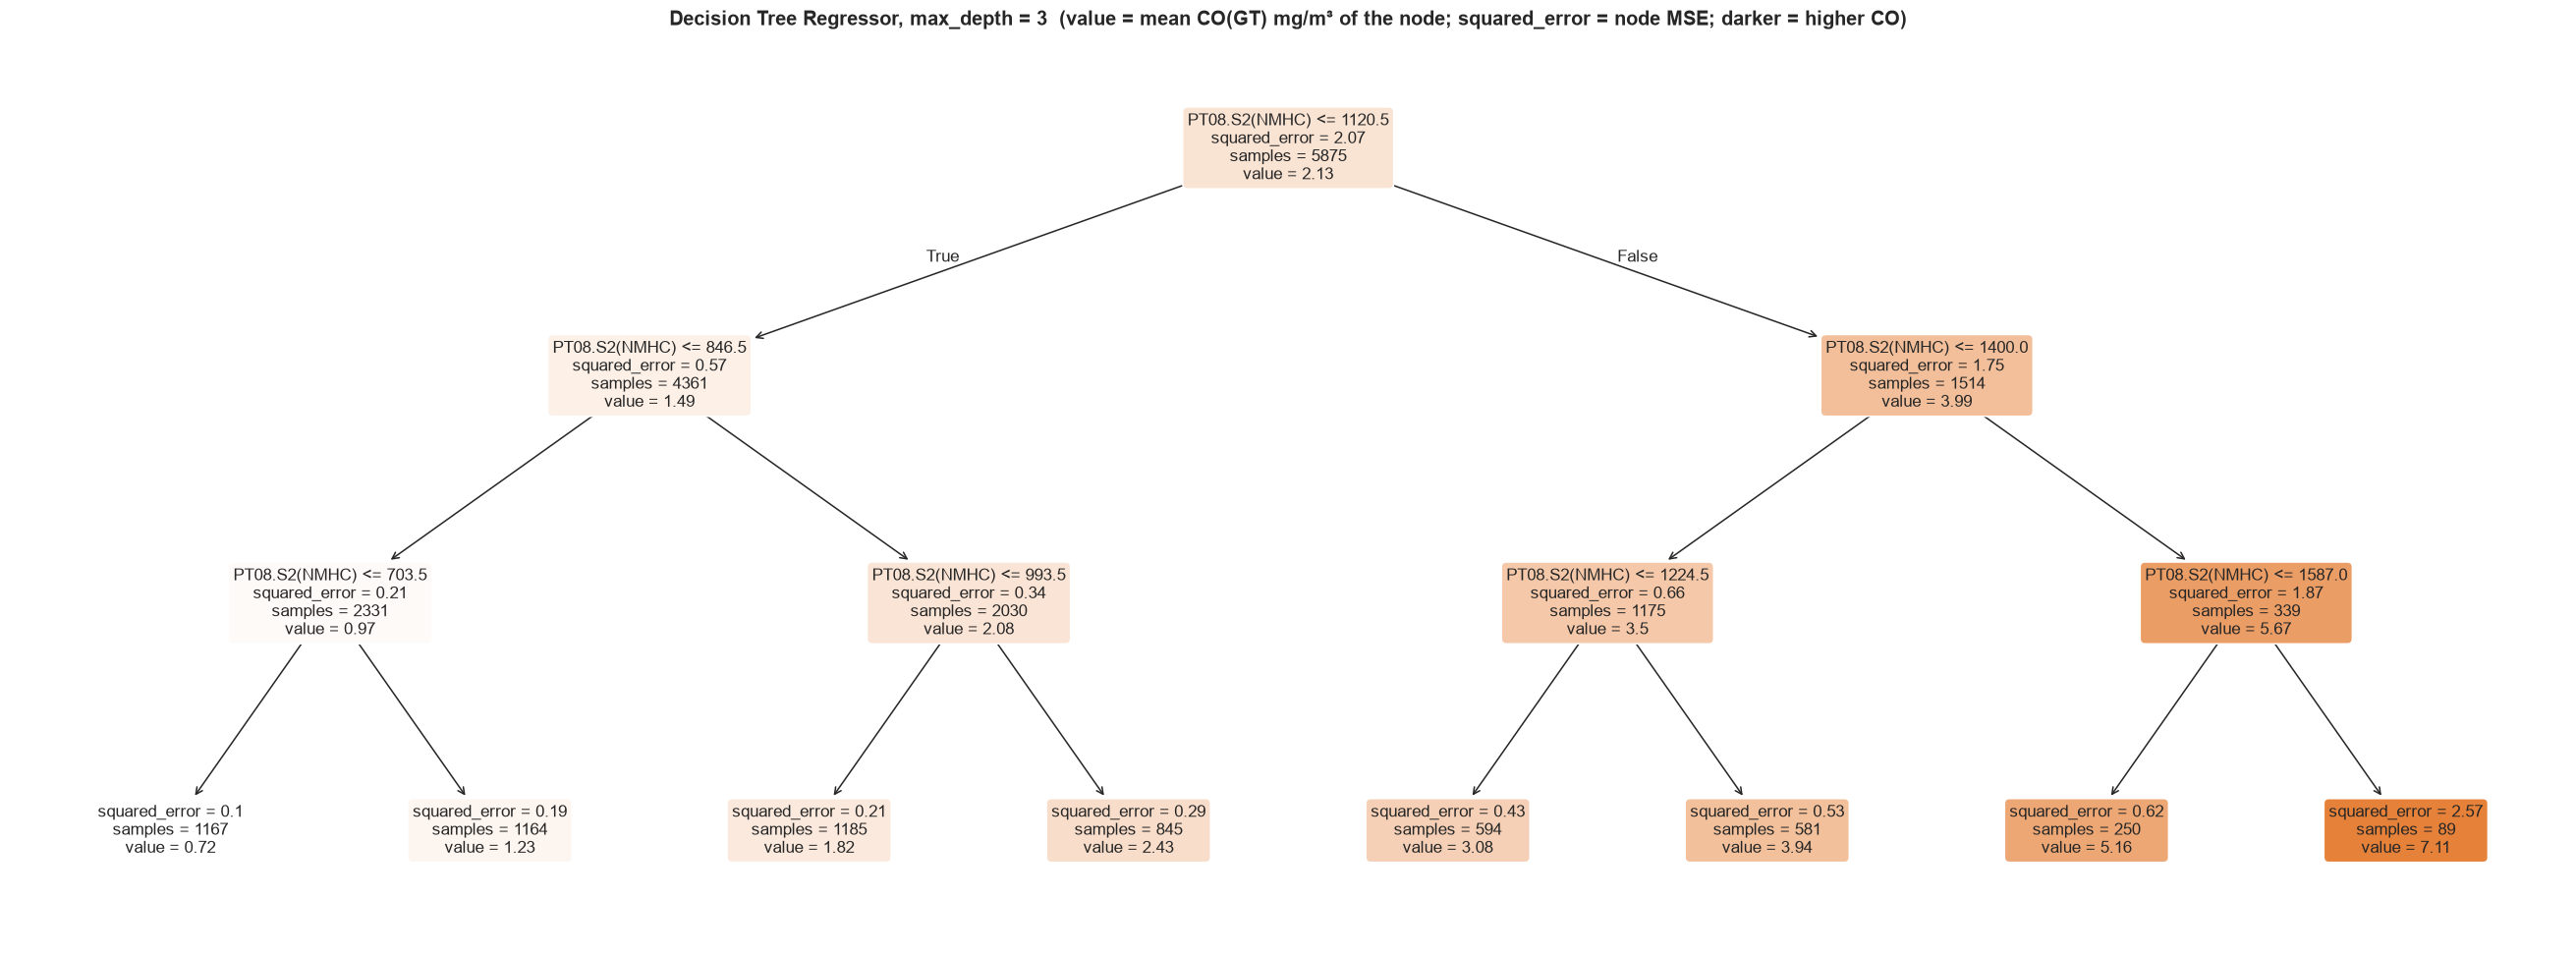

|--- PT08.S2(NMHC) <= 1120.5
|   |--- PT08.S2(NMHC) <= 846.5
|   |   |--- PT08.S2(NMHC) <= 703.5
|   |   |   |--- value: [0.7]
|   |   |--- PT08.S2(NMHC) >  703.5
|   |   |   |--- value: [1.2]
|   |--- PT08.S2(NMHC) >  846.5
|   |   |--- PT08.S2(NMHC) <= 993.5
|   |   |   |--- value: [1.8]
|   |   |--- PT08.S2(NMHC) >  993.5
|   |   |   |--- value: [2.4]
|--- PT08.S2(NMHC) >  1120.5
|   |--- PT08.S2(NMHC) <= 1400.0
|   |   |--- PT08.S2(NMHC) <= 1224.5
|   |   |   |--- value: [3.1]
|   |   |--- PT08.S2(NMHC) >  1224.5
|   |   |   |--- value: [3.9]
|   |--- PT08.S2(NMHC) >  1400.0
|   |   |--- PT08.S2(NMHC) <= 1587.0
|   |   |   |--- value: [5.2]
|   |   |--- PT08.S2(NMHC) >  1587.0
|   |   |   |--- value: [7.1]



In [51]:
from sklearn.tree import plot_tree, export_text
tree3 = DecisionTreeRegressor(max_depth=3, random_state=SEED).fit(X_train, y_train)
assert np.allclose(tree3.predict(X_test), PRED[tree_names[3]]["test"]); print("Raw-unit tree predictions == standardised-data tree ✔  | leaves:", tree3.get_n_leaves(), "| depth:", tree3.get_depth())

fig, ax = plt.subplots(figsize=(24, 9))
plot_tree(tree3, feature_names=FEATURES, filled=True, rounded=True, precision=2, fontsize=11, impurity=True, proportion=False, ax=ax)
ax.set_title("Decision Tree Regressor, max_depth = 3  (value = mean CO(GT) mg/m³ of the node; squared_error = node MSE; darker = higher CO)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()
print(export_text(tree3, feature_names=FEATURES, decimals=1))

**Observations — the depth-3 tree.**
- All **7 splits use a single feature, `PT08.S2(NMHC)`**; no other sensor or weather variable enters a depth-3 tree. The tree is simply a *step function of one sensor*.
- The thresholds (in sensor units) are 704, 846, 994, 1,121, 1,225, 1,400 and 1,587, and the predicted CO rises monotonically along them from 0.72 to 7.11 mg/m³ — a single dominant, monotone dose–response.
- The root split (S2 ≤ 1,120.5) already separates the data into a low-CO group (mean 1.49, MSE 0.57) and a high-CO group (mean 3.99, MSE 1.75).

,rule,n_train,mean CO (train),sd CO (train),n_test,test RMSE in leaf
leaf,,,,,,
3,PT08.S2(NMHC) <= 1120 & PT08.S2(NMHC) <= 846 & PT08.S2(NMHC) <= 704,1167,0.724,0.321,294,0.367
4,PT08.S2(NMHC) <= 1120 & PT08.S2(NMHC) <= 846 & PT08.S2(NMHC) > 704,1164,1.226,0.438,290,0.452
6,PT08.S2(NMHC) <= 1120 & PT08.S2(NMHC) > 846 & PT08.S2(NMHC) <= 994,1185,1.821,0.463,314,0.483
7,PT08.S2(NMHC) <= 1120 & PT08.S2(NMHC) > 846 & PT08.S2(NMHC) > 994,845,2.435,0.541,201,0.684
10,PT08.S2(NMHC) > 1120 & PT08.S2(NMHC) <= 1400 & PT08.S2(NMHC) <= 1224,594,3.083,0.653,144,0.681
11,PT08.S2(NMHC) > 1120 & PT08.S2(NMHC) <= 1400 & PT08.S2(NMHC) > 1224,581,3.935,0.727,148,0.820
13,PT08.S2(NMHC) > 1120 & PT08.S2(NMHC) > 1400 & PT08.S2(NMHC) <= 1587,250,5.162,0.792,60,0.895
14,PT08.S2(NMHC) > 1120 & PT08.S2(NMHC) > 1400 & PT08.S2(NMHC) > 1587,89,7.109,1.612,18,1.132


Features used for splitting in the depth-3 tree: {'PT08.S2(NMHC)': 7}


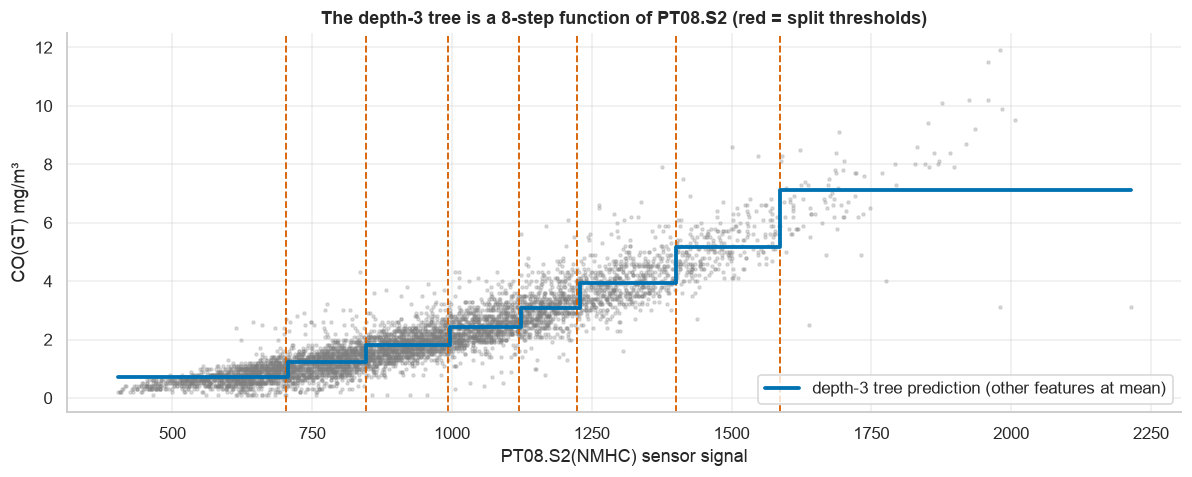

In [52]:
def leaf_rules(t, names):
    tr, out = t.tree_, {}
    def walk(n, conds):
        if tr.children_left[n] == -1: out[n] = " & ".join(conds) if conds else "(root)"; return
        f, th = names[tr.feature[n]], tr.threshold[n]
        walk(tr.children_left[n], conds + [f"{f} <= {th:.0f}" if th > 50 else f"{f} <= {th:.2f}"]); walk(tr.children_right[n], conds + [f"{f} > {th:.0f}" if th > 50 else f"{f} > {th:.2f}"])
    walk(0, []); return out

rules = leaf_rules(tree3, FEATURES); leaf_tr, leaf_te = tree3.apply(X_train), tree3.apply(X_test); rows = []
for lf, rule in rules.items():
    mt, me = leaf_tr == lf, leaf_te == lf
    rows.append({"leaf": lf, "rule": rule, "n_train": int(mt.sum()), "mean CO (train)": y_train[mt].mean(), "sd CO (train)": y_train[mt].std(),
                 "n_test": int(me.sum()), "test RMSE in leaf": rmse(y_test[me], np.full(me.sum(), tree3.tree_.value[lf].ravel()[0])) if me.sum() else np.nan})
LEAVES = pd.DataFrame(rows).set_index("leaf").sort_values("mean CO (train)"); display(LEAVES.style.format(precision=3))
used = pd.Series(tree3.tree_.feature[tree3.tree_.feature >= 0]).map(lambda i: FEATURES[i]).value_counts()
print("Features used for splitting in the depth-3 tree:", used.to_dict())

# the partition of the dominant sensor axis
fig, ax = plt.subplots(figsize=(11, 4.5)); sidx = FEATURES.index("PT08.S2(NMHC)")
ax.scatter(X_train["PT08.S2(NMHC)"], y_train, s=4, alpha=.25, color=GREY)
thr = sorted(set(tree3.tree_.threshold[tree3.tree_.feature == sidx]))
for th in thr: ax.axvline(th, color=RED, ls="--", lw=1.2)
gx = np.linspace(X_train["PT08.S2(NMHC)"].min(), X_train["PT08.S2(NMHC)"].max(), 400); gdf = pd.DataFrame(np.tile(X_train.mean().values, (400, 1)), columns=FEATURES); gdf["PT08.S2(NMHC)"] = gx
ax.step(gx, tree3.predict(gdf), color=BLUE, lw=2.5, where="post", label="depth-3 tree prediction (other features at mean)")
ax.set_xlabel("PT08.S2(NMHC) sensor signal"); ax.set_ylabel("CO(GT) mg/m³"); ax.set_title("The depth-3 tree is a 8-step function of PT08.S2 (red = split thresholds)"); ax.legend(); plt.tight_layout(); plt.show()

**Observations — leaf summary.**
- The eight leaves partition the training hours into groups of 89 to 1,185 samples with mean CO from 0.72 to 7.11 mg/m³; the test RMSE inside each leaf grows with CO (0.37 in the lowest leaf up to 1.13 in the highest), mirroring the heteroscedasticity found in Stage 3.
- The highest leaf (S2 > 1,587) contains only **89 training hours (1.5 %)** with a large spread (sd 1.61): it is the tree's weak spot, because a single constant has to represent the rare extreme episodes.

### 4.2 Feature importances — which sensor / environment variable contributes most?
Four independent methods are compared, because each has known blind spots (impurity importance is biased toward features used for early splits; permutation importance splits credit among correlated features; coefficients are only meaningful for linear models; drop-one retraining is expensive but direct):
1. **Impurity (MDI) importance** of the trees (depth 5 and tuned);
2. **Permutation importance** on the test set (increase in RMSE when a feature is shuffled) — tuned tree, linear, polynomial;
3. **Absolute standardised coefficients** of the linear model (with the bootstrap CIs from Stage 2);
4. **Drop-one ablation**: increase in CV RMSE when the feature is removed and the model re-trained (Stage 2).

In [53]:
fm = FEATURES; pk = f"Poly(d={DEG_STAR})"
IMP = pd.DataFrame({
    "MDI – tree depth 5": IMP_TREE[tree_names[5]], "MDI – tree tuned": IMP_TREE[N_TREE_T],
    "Permutation – tree tuned": PERM[N_TREE_T]["mean"], "Permutation – linear": PERM[N_LIN_NE]["mean"], f"Permutation – poly d={DEG_STAR}": PERM[N_POLY_NE]["mean"],
    "|std. coef| – linear": COEF_BOOT["coef"].abs(),
    "Drop-one ΔCV RMSE – linear": pd.Series({f: tbl.loc[f"Drop {f}", "Linear"] - base["Linear"] for f in fm}),
    "Drop-one ΔCV RMSE – tree": pd.Series({f: tbl.loc[f"Drop {f}", "Tree (tuned)"] - base["Tree (tuned)"] for f in fm})})
IMP_N = IMP.clip(lower=0); IMP_N = IMP_N / IMP_N.sum()                       # normalised to shares of the total
RANK = IMP.rank(ascending=False, method="min").astype(int)
print("Raw importance values:"); display(IMP.style.format(precision=3))
print("Normalised importance (share of the total, negatives clipped to 0):"); display(IMP_N.style.format("{:.1%}").background_gradient(cmap="Blues", axis=0))
print("Rank per method (1 = most important):"); display(RANK.assign(**{"mean rank": RANK.mean(axis=1)}).sort_values("mean rank").style.format(precision=1))
rho = IMP.corr(method="spearman"); print("Spearman rank agreement between methods: min = %.2f, median = %.2f" % (rho.values[np.triu_indices(len(rho), 1)].min(), np.median(rho.values[np.triu_indices(len(rho), 1)])))

Raw importance values:


,MDI – tree depth 5,MDI – tree tuned,Permutation – tree tuned,Permutation – linear,Permutation – poly d=2,|std. coef| – linear,Drop-one ΔCV RMSE – linear,Drop-one ΔCV RMSE – tree
PT08.S1(CO),0.003,0.002,0.003,0.247,0.418,0.394,0.022,-0.009
PT08.S2(NMHC),0.958,0.970,1.418,1.452,2.373,1.366,0.119,0.151
PT08.S3(NOx),0.007,0.000,0.000,0.075,0.088,0.199,0.007,-0.003
PT08.S4(NO2),0.004,0.000,0.000,0.067,1.073,0.174,0.001,0.000
PT08.S5(O3),0.000,0.000,0.000,0.010,0.063,0.077,-0.002,-0.001
T,0.027,0.028,0.092,0.119,0.953,0.244,0.004,0.017
RH,0.000,0.000,0.000,0.003,0.833,0.030,-0.000,0.000
AH,0.000,0.000,0.000,0.010,0.918,0.087,-0.001,0.000


Normalised importance (share of the total, negatives clipped to 0):


,MDI – tree depth 5,MDI – tree tuned,Permutation – tree tuned,Permutation – linear,Permutation – poly d=2,|std. coef| – linear,Drop-one ΔCV RMSE – linear,Drop-one ΔCV RMSE – tree
PT08.S1(CO),0.3%,0.2%,0.2%,12.5%,6.2%,15.3%,14.3%,0.0%
PT08.S2(NMHC),95.8%,97.0%,93.7%,73.2%,35.3%,53.1%,77.6%,89.8%
PT08.S3(NOx),0.7%,0.0%,0.0%,3.8%,1.3%,7.7%,4.4%,0.0%
PT08.S4(NO2),0.4%,0.0%,0.0%,3.4%,16.0%,6.8%,0.9%,0.0%
PT08.S5(O3),0.0%,0.0%,0.0%,0.5%,0.9%,3.0%,0.0%,0.0%
T,2.7%,2.8%,6.1%,6.0%,14.2%,9.5%,2.8%,10.2%
RH,0.0%,0.0%,0.0%,0.1%,12.4%,1.2%,0.0%,0.0%
AH,0.0%,0.0%,0.0%,0.5%,13.7%,3.4%,0.0%,0.0%


Rank per method (1 = most important):


,MDI – tree depth 5,MDI – tree tuned,Permutation – tree tuned,Permutation – linear,Permutation – poly d=2,|std. coef| – linear,Drop-one ΔCV RMSE – linear,Drop-one ΔCV RMSE – tree,mean rank
PT08.S2(NMHC),1,1,1,1,1,1,1,1,1.0
T,2,2,2,3,3,3,4,2,2.6
PT08.S1(CO),5,3,3,2,6,2,2,8,3.9
PT08.S4(NO2),4,4,4,5,2,5,5,4,4.1
PT08.S3(NOx),3,4,4,4,7,4,3,7,4.5
AH,6,4,4,7,4,6,7,4,5.2
RH,6,4,4,8,5,8,6,3,5.5
PT08.S5(O3),6,4,4,6,8,7,8,6,6.1


Spearman rank agreement between methods: min = 0.07, median = 0.73


**Observations — feature importance (answer to "which variable contributes most?").**
- **`PT08.S2(NMHC)` is rank 1 in all 8 methods**, with a mean share of **77 %** of total importance (tree methods 94–97 %, linear methods 53–78 %).
- The runner-ups are **`T` (mean share 6.8 %, rank 2–4)** and **`PT08.S1(CO)` (6.1 %)**; `PT08.S1` matters for the linear model (rank 2 in coefficients, permutation and drop-one) but **not for the trees** (≈ 0 %), since it is redundant with `PT08.S2` (r = 0.89).
- `PT08.S4(NO2)`, `PT08.S3(NOx)`, `AH`, `RH` and `PT08.S5(O3)` contribute little (≤ 3.4 % on average).
- **Agreement:** the median Spearman rank correlation between methods is 0.73, but the minimum is 0.07. The disagreement is almost entirely about the *minor* features; the top feature is unanimous.
- **A caveat on the polynomial permutation column:** it assigns surprisingly large importance to `RH`, `AH`, `T` and `PT08.S4` (0.8–1.1 mg/m³ ΔRMSE, more than the linear model gives to anything except S2), although retraining without any of them (drop-one, Stage 2) costs the polynomial *nothing*. Shuffling a single weather column creates physically impossible combinations (e.g. a humidity that does not match the temperature), and the degree-2 model — with its many cross-terms between collinear inputs — reacts violently to such unrealistic inputs. That is a sign of **fragility off the data manifold**, not of real predictive reliance, and it is why drop-one and the on-data plots below are the more trustworthy evidence.

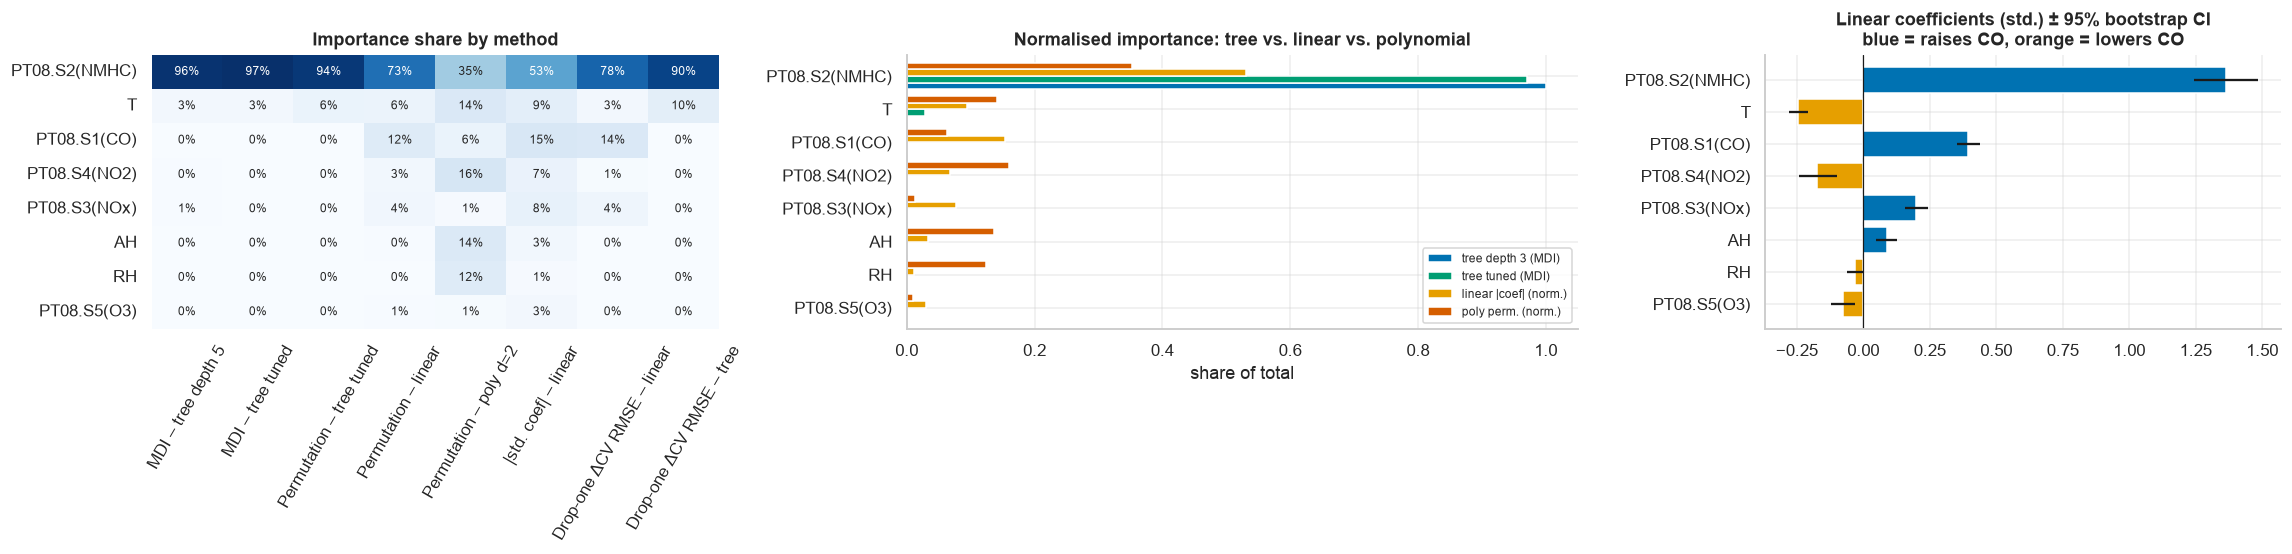

Mean share across the 8 methods: {'PT08.S2(NMHC)': '77.0%', 'T': '6.8%', 'PT08.S1(CO)': '6.1%', 'PT08.S4(NO2)': '3.4%', 'PT08.S3(NOx)': '2.2%', 'AH': '2.2%', 'RH': '1.7%', 'PT08.S5(O3)': '0.6%'}


In [54]:
order = IMP_N.mean(axis=1).sort_values().index
fig, ax = plt.subplots(1, 3, figsize=(21, 5.2), gridspec_kw={"width_ratios": [1.1, 1.3, 1]})
sns.heatmap(IMP_N.loc[order[::-1]], annot=True, fmt=".0%", cmap="Blues", cbar=False, ax=ax[0], annot_kws={"size": 8}); ax[0].set_title("Importance share by method"); ax[0].tick_params(axis="x", rotation=60)
pm = pd.DataFrame({"tree depth 3 (MDI)": IMP_TREE[tree_names[3]], "tree tuned (MDI)": IMP_TREE[N_TREE_T], "linear |coef| (norm.)": IMP_N["|std. coef| – linear"],
                   f"poly perm. (norm.)": IMP_N[f"Permutation – poly d={DEG_STAR}"]}).loc[order]
pm.plot.barh(ax=ax[1], color=[BLUE, GREEN, ORANGE, RED], width=.8); ax[1].set_title("Normalised importance: tree vs. linear vs. polynomial"); ax[1].set_xlabel("share of total"); ax[1].legend(fontsize=8)
cb = COEF_BOOT.loc[order]; ax[2].barh(cb.index, cb["coef"], xerr=[cb["coef"] - cb["ci_low"], cb["ci_high"] - cb["coef"]], color=[BLUE if c > 0 else ORANGE for c in cb["coef"]]); ax[2].axvline(0, color="k", lw=.8)
ax[2].set_title("Linear coefficients (std.) ± 95% bootstrap CI\nblue = raises CO, orange = lowers CO"); plt.tight_layout(); plt.show()
top = IMP_N.mean(axis=1).sort_values(ascending=False); print("Mean share across the 8 methods:", {k: f"{v:.1%}" for k, v in top.items()})

### 4.3 Grouped permutation importance (handling collinearity)
When correlated features are permuted one at a time the model can still lean on their twins, so single-feature importance *understates* groups of redundant sensors. Here, columns of a group are shuffled **jointly** (same permutation) on the test set and the RMSE increase is recorded (30 repeats).

,Linear,Poly d=2,Tree tuned
PT08.S2 (NMHC sensor) alone,1.458,2.394,1.424
PT08.S1 + S5 (CO / O3 sensors),0.177,0.242,0.003
PT08.S1 + S2 + S5 (correlated cluster),1.855,2.242,1.442
PT08.S3 + S4 (NOx / NO2 sensors),0.188,1.397,0.000
All 5 sensors,1.468,1.544,1.442
Temperature T,0.118,0.953,0.092
Humidity (RH + AH),0.011,1.264,0.000
"All weather (T, RH, AH)",0.063,0.238,0.092


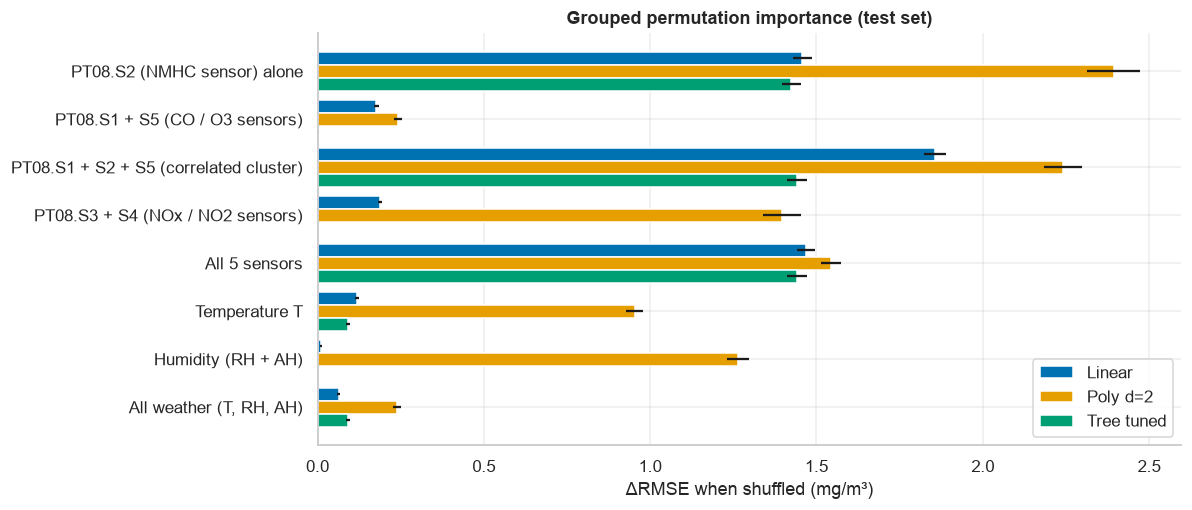

In [55]:
S1, S2, S3, S4, S5 = SENSOR_COLS
GROUPS = {"PT08.S2 (NMHC sensor) alone": [S2], "PT08.S1 + S5 (CO / O3 sensors)": [S1, S5], "PT08.S1 + S2 + S5 (correlated cluster)": [S1, S2, S5],
          "PT08.S3 + S4 (NOx / NO2 sensors)": [S3, S4], "All 5 sensors": SENSOR_COLS, "Temperature T": ["T"], "Humidity (RH + AH)": ["RH", "AH"], "All weather (T, RH, AH)": WEATHER_COLS}
def grouped_perm(model, cols, n_repeats=30, seed=SEED):
    rg = np.random.default_rng(seed); b0 = rmse(y_test, model.predict(X_test_s)); d = []
    for _ in range(n_repeats):
        Xp = X_test_s.copy(); Xp[cols] = X_test_s[cols].values[rg.permutation(len(Xp))]; d.append(rmse(y_test, model.predict(Xp)) - b0)
    return np.mean(d), np.std(d)
GP_MODELS = {"Linear": N_LIN_NE, f"Poly d={DEG_STAR}": N_POLY_NE, "Tree tuned": N_TREE_T}
GPERM = pd.DataFrame({m_: {g: grouped_perm(FITTED[nm], c)[0] for g, c in GROUPS.items()} for m_, nm in GP_MODELS.items()})
GPERM_SD = pd.DataFrame({m_: {g: grouped_perm(FITTED[nm], c)[1] for g, c in GROUPS.items()} for m_, nm in GP_MODELS.items()})
display(GPERM.style.format(precision=3).background_gradient(cmap="Reds", axis=None).set_caption("Increase in test RMSE (mg/m³) when the group is shuffled jointly"))
fig, ax = plt.subplots(figsize=(11, 4.8)); w = 0.27
for i, (m_, c) in enumerate(zip(GPERM.columns, [BLUE, ORANGE, GREEN])): ax.barh(np.arange(len(GPERM)) + (i - 1) * w, GPERM[m_], w, xerr=GPERM_SD[m_], color=c, label=m_)
ax.set_yticks(range(len(GPERM))); ax.set_yticklabels(GPERM.index); ax.invert_yaxis(); ax.set_xlabel("ΔRMSE when shuffled (mg/m³)"); ax.set_title("Grouped permutation importance (test set)"); ax.legend(); plt.tight_layout(); plt.show()

**Observations — grouped permutation.**
- **Sensors drive everything.** Shuffling all five sensors jointly costs the linear model +1.47 mg/m³ RMSE (tree +1.44) while shuffling all weather variables jointly costs only +0.06 (linear) / +0.09 (tree).
- For the linear model the correlated cluster `S1 + S2 + S5` (+1.86) is clearly more important than `S2` alone (+1.46): its twins add information that single-feature permutation hides. For the tree the cluster adds nothing beyond S2 (+1.44 vs. +1.42), because the tree only ever uses S2.
- `T` (+0.12 linear, +0.09 tree) is the only weather variable with a measurable effect; humidity (`RH + AH`) is negligible for the linear model and the tree (+0.011 and 0.000).
- The polynomial model again shows large values for non-S2 groups (e.g. `S3 + S4` +1.40, humidity +1.26): the same off-manifold fragility discussed above.

### 4.4 Partial dependence — how do the models *use* the important features?
Average model prediction as one feature is swept across its observed range (2nd–98th percentile) with all other features left at their observed values. This visualises the **shape** of each learnt relationship: a straight line (linear), a smooth curve (polynomial) or a staircase (tree). Axes are in original units; the shaded histogram shows where the data lie.

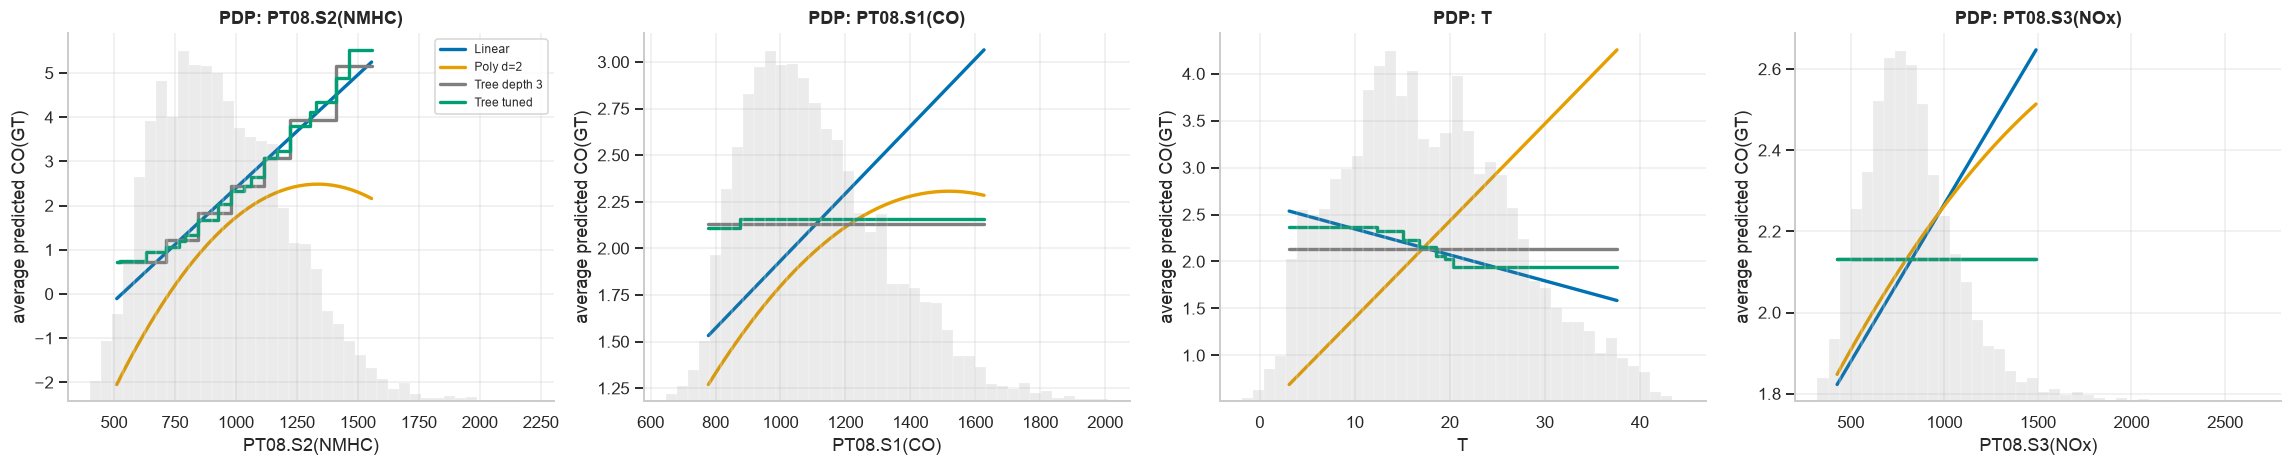

,Linear,Poly d=2,Tree depth 3,Tree tuned
PT08.S2(NMHC),5.355,4.535,4.439,4.812
PT08.S1(CO),1.533,1.037,0.000,0.048
T,0.953,3.565,0.000,0.417
PT08.S3(NOx),0.825,0.666,0.000,0.000


In [56]:
top4 = list(top.index[:2]) + [f for f in ["PT08.S1(CO)", "PT08.S3(NOx)"] if f not in top.index[:2]][:2]
top4 = ["PT08.S2(NMHC)", "PT08.S1(CO)", "T", "PT08.S3(NOx)"]
mu, sc_ = dict(zip(FEATURES, scaler.mean_)), dict(zip(FEATURES, scaler.scale_))
PDP_MODELS = {"Linear": (N_LIN_NE, BLUE), f"Poly d={DEG_STAR}": (N_POLY_NE, ORANGE), "Tree depth 3": (tree_names[3], GREY), "Tree tuned": (N_TREE_T, GREEN)}
def pdp_1d(model, feat, grid_s):
    out = []
    for g in grid_s:
        Xg = X_train_s.copy(); Xg[feat] = g; out.append(model.predict(Xg).mean())
    return np.array(out)

fig, axes = plt.subplots(1, 4, figsize=(21, 4.4)); PDP = {}
for a, f in zip(axes, top4):
    lo, hi = np.percentile(X_train_s[f], [2, 98]); gs_ = np.linspace(lo, hi, 40); xo = gs_ * sc_[f] + mu[f]
    for lbl, (nm, c) in PDP_MODELS.items():
        PDP[(f, lbl)] = pdp_1d(FITTED[nm], f, gs_); a.plot(xo, PDP[(f, lbl)], color=c, lw=2.2, label=lbl, drawstyle="steps-mid" if "Tree" in lbl else "default")
    a2 = a.twinx(); a2.hist(X_train[f], bins=40, color=GREY, alpha=.15); a2.set_yticks([]); a2.spines[["top", "right"]].set_visible(False)
    a.set_xlabel(f); a.set_ylabel("average predicted CO(GT)"); a.set_title(f"PDP: {f}")
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

# strength of each feature's average effect (range of the PDP)
display(pd.DataFrame({lbl: {f: np.ptp(PDP[(f, lbl)]) for f in top4} for lbl in PDP_MODELS}).style.format(precision=3).set_caption("Range of the partial-dependence curve (mg/m³ of average CO change across the feature's 2–98 % range)"))

**Observations — partial dependence.**
- **`PT08.S2`:** the linear model gives a straight line (≈ 5.4 mg/m³ rise across the central 96 % of the sensor range) and the trees follow the *same* line as a staircase (rise 4.4–4.8): the average effect of the dominant sensor is essentially **linear**, which is why the tree cannot beat the line.
- **`PT08.S1`, `PT08.S3`:** the tree ignores them (flat curves) while the linear model (and the polynomial, with some curvature) assigns a positive effect to both.
- **`T`:** the linear model gives a mild negative effect (−0.95 mg/m³ over the range), the tuned tree a small step down, depth 3 none.
- **Polynomial model — a warning:** its partial-dependence curves are concave and even negative (about −2 mg/m³ at low S2), which is physically implausible. A PDP evaluates the model at feature combinations that never occur (e.g. low S2 together with the observed values of the correlated S1, S5), where the degree-2 cross-terms do not cancel as they do on real data. The next plot shows that **on the actual data the polynomial model is the most accurate**, so this is a limitation of the PDP *and* a sign that the polynomial model should not be trusted for inputs that break the sensor correlations.

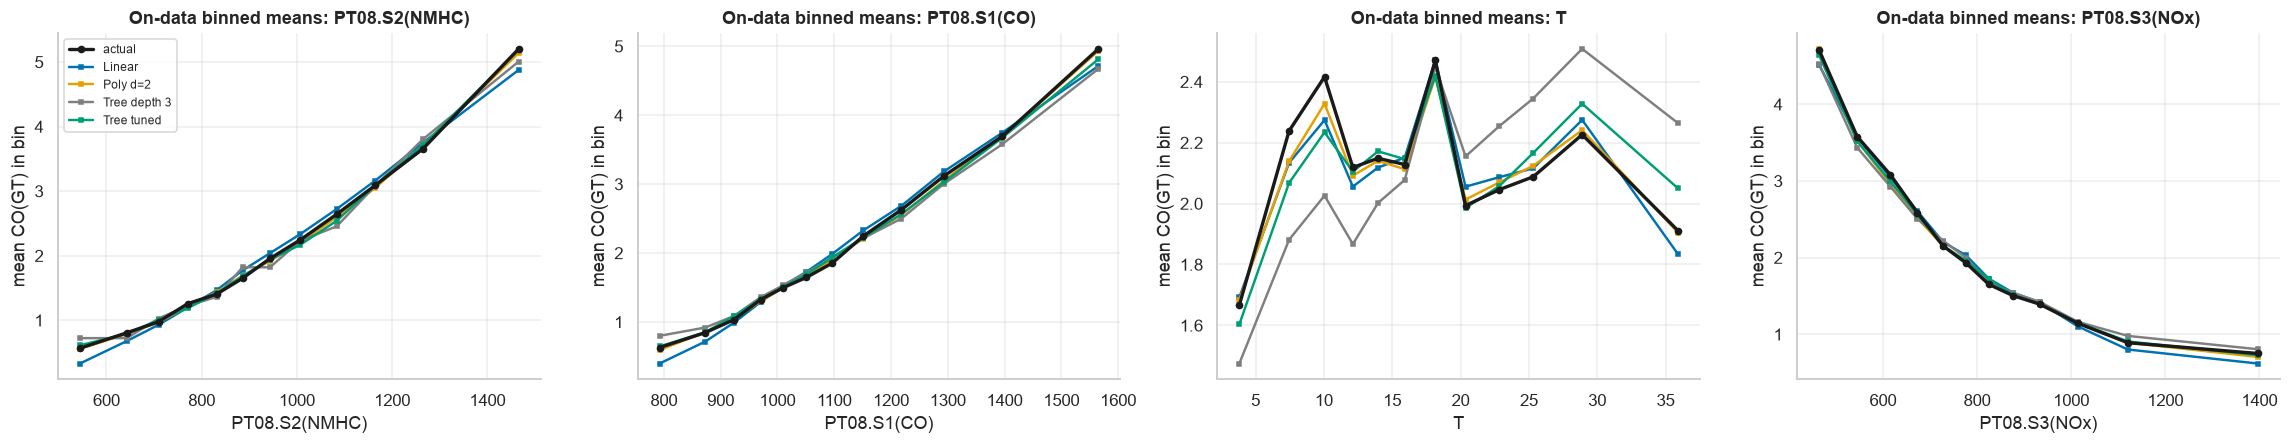

Max |binned mean prediction - binned mean actual| per model (mg/m³), averaged over the 4 features:
{'Linear': 0.227, 'Poly d=2': 0.09, 'Tree depth 3': 0.264, 'Tree tuned': 0.13}


In [57]:
# On-data view (binned means, a.k.a. M-plot): average ACTUAL and PREDICTED CO per quantile bin of each feature on the test set.
# Unlike the PDP it never evaluates a model at unrealistic feature combinations, so it shows how each model behaves where the data actually are.
fig, axes = plt.subplots(1, 4, figsize=(21, 4.2)); MPLOT = {}
for a, f in zip(axes, top4):
    bins = pd.qcut(X_test[f], 12, duplicates="drop"); xm = X_test[f].groupby(bins, observed=True).mean()
    act = y_test.groupby(bins, observed=True).mean(); a.plot(xm, act, "k-o", lw=2.2, ms=4, label="actual", zorder=5); MPLOT[(f, "actual")] = act.values
    for lbl, (nm, c) in PDP_MODELS.items():
        pm_ = pd.Series(PRED[nm]["test"], index=y_test.index).groupby(bins, observed=True).mean(); MPLOT[(f, lbl)] = pm_.values
        a.plot(xm, pm_, color=c, lw=1.6, marker="s", ms=3, label=lbl)
    a.set_xlabel(f); a.set_ylabel("mean CO(GT) in bin"); a.set_title(f"On-data binned means: {f}")
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()
print("Max |binned mean prediction - binned mean actual| per model (mg/m³), averaged over the 4 features:")
print({lbl: round(float(np.mean([np.abs(MPLOT[(f, lbl)] - MPLOT[(f, "actual")]).max() for f in top4])), 3) for lbl in PDP_MODELS})

**Observations — on-data binned means.** This view uses only realistic inputs. All models follow the actual mean CO closely along `PT08.S2` and `PT08.S1` (monotone, nearly straight) and `PT08.S3` (a convex decay, which the straight line misses at both ends). Averaged over the four features, the largest bin-wise deviation from the actual means is **0.09 mg/m³ for the polynomial, 0.13 for the tuned tree, 0.23 for the linear model and 0.26 for the depth-3 tree**. The linear model's errors are concentrated at the extremes of the sensor ranges, where it **under-estimates at both ends** (e.g. lowest `PT08.S2` bin 0.3 vs. 0.6 actual, highest 4.9 vs. 5.2), which is the curvature already seen in the Stage 3 residuals. For `T`, the actual relation is irregular (non-monotone), and only the polynomial and tuned tree follow its wiggles; the depth-3 tree, which ignores T, is the farthest off.

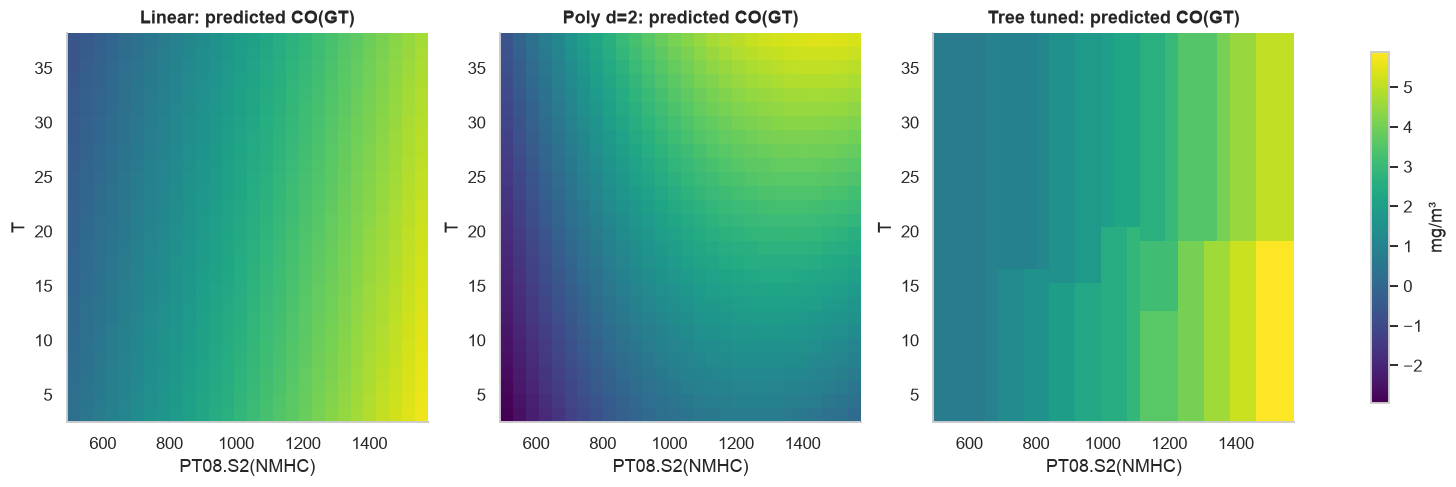

Mean |non-additive part| of each model's 2-D surface (0 = purely additive, no interaction): {'Linear': np.float64(0.0), 'Poly d=2': np.float64(0.1954), 'Tree tuned': np.float64(0.1311)}


In [58]:
# 2-D partial dependence of the two most important drivers: does a model capture their interaction?
f1, f2 = "PT08.S2(NMHC)", "T"; bg = X_train_s.sample(800, random_state=SEED)
g1 = np.linspace(*np.percentile(X_train_s[f1], [2, 98]), 28); g2 = np.linspace(*np.percentile(X_train_s[f2], [2, 98]), 28)
def pdp_2d(model):
    Z = np.zeros((len(g2), len(g1)))
    for i, b in enumerate(g2):
        for j, a_ in enumerate(g1):
            Xg = bg.copy(); Xg[f1], Xg[f2] = a_, b; Z[i, j] = model.predict(Xg).mean()
    return Z
fig, axes = plt.subplots(1, 3, figsize=(18, 4.6)); Zs = {l: pdp_2d(FITTED[PDP_MODELS[l][0]]) for l in ["Linear", f"Poly d={DEG_STAR}", "Tree tuned"]}
vmin, vmax = min(z.min() for z in Zs.values()), max(z.max() for z in Zs.values())
for a, (l, Z) in zip(axes, Zs.items()):
    im = a.pcolormesh(g1 * sc_[f1] + mu[f1], g2 * sc_[f2] + mu[f2], Z, cmap="viridis", vmin=vmin, vmax=vmax, shading="auto"); a.set_xlabel(f1); a.set_ylabel(f2); a.set_title(f"{l}: predicted CO(GT)")
fig.colorbar(im, ax=axes, label="mg/m³", shrink=.9); plt.show()
Zl = Zs["Linear"]; add_resid = {l: np.abs(Z - (Z.mean(0, keepdims=True) + Z.mean(1, keepdims=True) - Z.mean())).mean() for l, Z in Zs.items()}
print("Mean |non-additive part| of each model's 2-D surface (0 = purely additive, no interaction):", {k: round(v, 4) for k, v in add_resid.items()})

**Observations.** The linear surface is a plain tilted plane (no interaction by construction: non-additive part 0.000). The polynomial and the tuned tree both contain interactions (non-additive part 0.195 and 0.131 mg/m³), with the tree producing blocky regions where `T` modulates the effect of `PT08.S2` (higher CO at low temperature for high S2 values). The polynomial surface is smooth but, as noted above, partly extrapolates to unrealistic sensor/weather combinations (e.g. strongly negative predictions at low S2 and low T), so its absolute shape should not be over-interpreted.

### 4.5 A pollution episode as seen by the models

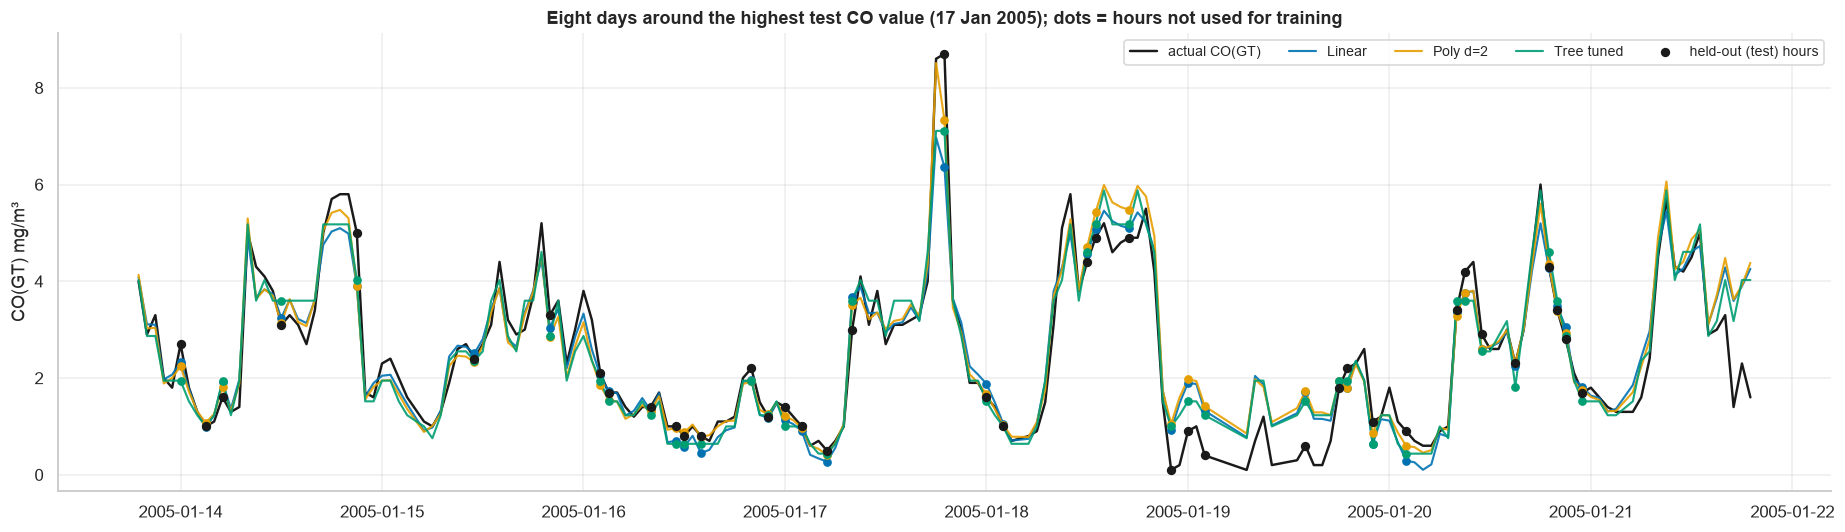

In [59]:
X_all_s = pd.DataFrame(scaler.transform(data[FEATURES]), columns=FEATURES, index=data.index)
peak = y_test.idxmax(); win = slice(peak - pd.Timedelta(days=4), peak + pd.Timedelta(days=4)); W = data.loc[win]; Xw = X_all_s.loc[win]
is_test = W.index.isin(y_test.index)
fig, ax = plt.subplots(figsize=(17, 5)); ax.plot(W.index, W[TARGET], color="k", lw=1.6, label="actual CO(GT)")
for lbl, (nm, c) in {"Linear": (N_LIN_NE, BLUE), f"Poly d={DEG_STAR}": (N_POLY_NE, ORANGE), "Tree tuned": (N_TREE_T, GREEN)}.items():
    p = FITTED[nm].predict(Xw); ax.plot(W.index, p, color=c, lw=1.4, alpha=.9, label=lbl); ax.scatter(W.index[is_test], p[is_test], s=22, color=c, zorder=3)
ax.scatter(W.index[is_test], W[TARGET][is_test], s=26, color="k", zorder=4, label="held-out (test) hours")
ax.set_ylabel("CO(GT) mg/m³"); ax.set_title(f"Eight days around the highest test CO value ({peak:%d %b %Y}); dots = hours not used for training"); ax.legend(ncol=5, fontsize=9); plt.tight_layout(); plt.show()

**Observations.** The models reproduce the timing and shape of the daily CO cycles and of the multi-hour pollution episodes well, including on held-out hours. At the highest peak of the test set (8.7 mg/m³ on 17 Jan 2005) **all models under-predict** (polynomial 7.3 is closest, tree 7.1, linear 6.4), in line with the under-prediction of extremes found in Stages 2–3. They also miss abrupt drops that are not visible in the sensors (e.g. the last hours on 21 Jan).

✅ **Stage 4 complete** — depth-3 tree plot, rules and leaf summary, consolidated feature-importance analysis, grouped permutation importance, partial dependence and an episode reconstruction.

---
## Stage 5 — Baseline Comparison: Linear Regression vs. Decision Tree

Linear regression is the **baseline**; the question is whether a Decision Tree (and, as an extra reference, the degree-2 polynomial) captures structure the line misses. The comparison combines accuracy, uncertainty, *where* each model wins, extrapolation behaviour and an overview of every ablation from Stage 2.

| Section | Content |
|---|---|
| 5.1 | Head-to-head: Linear vs. every Decision Tree configuration, with paired uncertainty |
| 5.2 | Is there non-linear structure? Statistical test, polynomial terms, a hybrid "linear + tree" probe |
| 5.3 | What each model family can represent (synthetic demonstration, clearly labelled) |
| 5.4 | Where does each model win? (by sensor level) and extrapolation to unseen conditions |
| 5.5 | Ablation ledger — every ablation in one table |
| 5.6 | Scorecard |

### 5.1 Head-to-head: Linear vs. Decision Tree

Reference — Linear regression: train RMSE 0.4799, test RMSE 0.4933, test R² 0.8799, CV RMSE 0.4882, 9 parameters


,leaves,train RMSE,test RMSE,test R²,CV RMSE,Δ test RMSE vs Linear,95% CI low,95% CI high,P(tree worse),folds Linear wins (of 5)
Decision Tree,,,,,,,,,,
max_depth=3,8,0.5515,0.5854,0.8308,0.5773,0.0922,0.0528,0.1279,1.0000,5.0000
max_depth=5,32,0.4403,0.5131,0.8700,0.5092,0.0198,-0.0006,0.0393,0.9730,5.0000
max_depth=10,693,0.2603,0.5442,0.8538,0.5981,0.0509,0.0168,0.0872,1.0000,5.0000
max_depth=None,4245,0.0000,0.6096,0.8165,0.6593,0.1163,0.0776,0.1537,1.0000,5.0000
"tuned (CV, 1-SE)",29,0.4698,0.5157,0.8687,0.5134,0.0224,0.0001,0.0443,0.9750,4.0000
"pruned (ccp, CV)",21,0.4625,0.5304,0.8611,0.5212,0.0371,0.0144,0.0604,1.0000,–


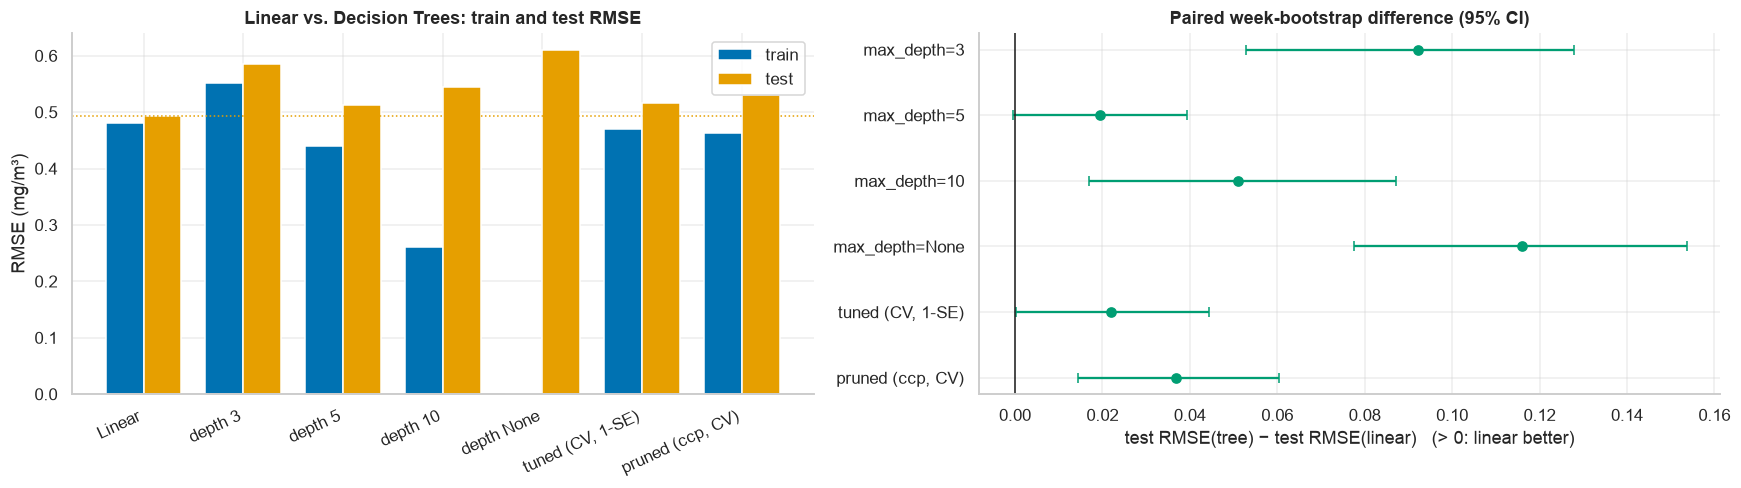

In [60]:
LIN = N_LIN_NE; TREES = [tree_names[3], tree_names[5], tree_names[10], tree_names[None], N_TREE_T, N_TREE_P]
rows = []
for nm in TREES:
    d = BOOT[nm][0] - BOOT[LIN][0]; lo, hi = ci(d)
    fold_wins = int((FOLD_RMSE.iloc[:5]["Linear"] < FOLD_RMSE.iloc[:5][{tree_names[3]: "Tree depth 3", tree_names[5]: "Tree depth 5", tree_names[10]: "Tree depth 10", tree_names[None]: "Tree depth None", N_TREE_T: "Tree (tuned)"}.get(nm, "Tree (tuned)")]).sum()) if nm != N_TREE_P else np.nan
    rows.append({"Decision Tree": nm.replace("Tree | ", ""), "leaves": RESULTS[nm]["n_leaves"], "train RMSE": RESULTS[nm]["train_rmse"], "test RMSE": RESULTS[nm]["test_rmse"], "test R²": RESULTS[nm]["test_r2"],
                 "CV RMSE": RESULTS[nm]["cv_rmse"], "Δ test RMSE vs Linear": RESULTS[nm]["test_rmse"] - RESULTS[LIN]["test_rmse"], "95% CI low": lo, "95% CI high": hi,
                 "P(tree worse)": np.mean(d > 0), "folds Linear wins (of 5)": fold_wins})
H2H = pd.DataFrame(rows).set_index("Decision Tree")
print(f"Reference — Linear regression: train RMSE {RESULTS[LIN]['train_rmse']:.4f}, test RMSE {RESULTS[LIN]['test_rmse']:.4f}, test R² {RESULTS[LIN]['test_r2']:.4f}, CV RMSE {RESULTS[LIN]['cv_rmse']:.4f}, 9 parameters")
display(H2H.style.format(precision=4, na_rep="–").background_gradient(subset=["Δ test RMSE vs Linear"], cmap="Reds"))

fig, ax = plt.subplots(1, 2, figsize=(16, 4.6)); names = ["Linear"] + [t.replace("Tree | ", "").replace("max_depth=", "depth ") for t in TREES]; vals = [LIN] + TREES; x = np.arange(len(vals)); w = .38
ax[0].bar(x - w / 2, [RESULTS[n]["train_rmse"] for n in vals], w, color=BLUE, label="train"); ax[0].bar(x + w / 2, [RESULTS[n]["test_rmse"] for n in vals], w, color=ORANGE, label="test")
ax[0].set_xticks(x); ax[0].set_xticklabels(names, rotation=25, ha="right"); ax[0].set_ylabel("RMSE (mg/m³)"); ax[0].set_title("Linear vs. Decision Trees: train and test RMSE"); ax[0].legend()
ax[0].axhline(RESULTS[LIN]["test_rmse"], color=ORANGE, ls=":", lw=1)
for i, nm in enumerate(TREES):
    d = BOOT[nm][0] - BOOT[LIN][0]; lo, hi = ci(d); ax[1].errorbar(d.mean(), i, xerr=[[d.mean() - lo], [hi - d.mean()]], fmt="o", color=GREEN, capsize=3)
ax[1].axvline(0, color="k", lw=1); ax[1].set_yticks(range(len(TREES))); ax[1].set_yticklabels([t.replace("Tree | ", "") for t in TREES]); ax[1].invert_yaxis()
ax[1].set_xlabel("test RMSE(tree) − test RMSE(linear)   (> 0: linear better)"); ax[1].set_title("Paired week-bootstrap difference (95% CI)"); plt.tight_layout(); plt.show()

**Observations — Linear vs. Decision Tree.**
- **Linear regression is more accurate than every Decision Tree configuration**, on every measure of the held-out error: test RMSE 0.493 (R² 0.880) versus 0.513–0.610 (R² 0.817–0.870).
- The gap is *small for the best tree and large for the others*: depth 5 is +0.020 RMSE worse (CI [−0.001, +0.039], borderline), the tuned tree +0.022 (CI [+0.0001, +0.044]), the pruned tree +0.037, depth 10 +0.051, depth 3 +0.092 and `None` +0.116 (the last four CIs exclude 0).
- Linear wins in **5 of 5 CV folds** against every fixed-depth tree and 4 of 5 against the tuned tree, so the ordering does not depend on the test split.
- The trees also generalise worse: train–test RMSE gap 0.046–0.610 versus 0.013 for linear, while the tree needs 21–4,245 leaves against 9 coefficients.

### 5.2 Is there non-linear structure for the Decision Tree to exploit?
Three probes: (a) a nested-model **F-test** of linear vs. degree-2 polynomial (training data), together with the biggest quadratic/interaction terms; (b) the **single-feature vs. all-feature** behaviour of the linear and tree models (Stage 2 ablation) — a tree can model a non-linear curve of *one* variable, but is inefficient at adding up *several* variables linearly; (c) a **hybrid** that fits the tree to the *residuals of the linear model* — if the tree finds structure there, the linear model is leaving non-linear signal on the table.

In [61]:
# (a) F-test: does the degree-2 expansion explain significantly more than the linear model?  (training data)
n_ = len(y_train); sse1 = np.sum((y_train.values - PRED[N_LIN_NE]["train"]) ** 2); sse2 = np.sum((y_train.values - PRED[N_POLY_NE]["train"]) ** 2); p1, p2 = len(FEATURES) + 1, nterms(DEG_STAR)
F = ((sse1 - sse2) / (p2 - p1)) / (sse2 / (n_ - p2)); pval = stats.f.sf(F, p2 - p1, n_ - p2)
print(f"Nested F-test linear (p={p1}) vs degree-2 (p={p2}):  F = {F:.1f},  p = {pval:.1e}   |  R² train {RESULTS[N_LIN_NE]['train_r2']:.4f} -> {RESULTS[N_POLY_NE]['train_r2']:.4f}, "
      f"test {RESULTS[N_LIN_NE]['test_r2']:.4f} -> {RESULTS[N_POLY_NE]['test_r2']:.4f}")
print("(p-value is optimistic because hourly residuals are autocorrelated; the held-out CV/test gains in Stages 2-3 are the more reliable evidence)")
pm_ = FITTED[N_POLY_NE]; tn = pm_.poly_.feature_names(FEATURES)
terms = pd.DataFrame({"term": tn, "std. coefficient": pm_.coef_}); terms["|coef|"] = terms["std. coefficient"].abs()
terms["order"] = terms["term"].map(lambda s: s.count("*") + 1); TOPTERMS = terms.sort_values("|coef|", ascending=False).head(10).set_index("term")
display(TOPTERMS.style.format(precision=3).set_caption("Ten largest terms of the degree-2 model (collinear terms trade off against each other: do not read individually)"))
q = terms[terms["order"] == 2]; print(f"Share of total |coef| carried by degree-2 terms: {q['|coef|'].sum() / terms['|coef|'].sum():.1%}")

# (b) one feature vs. all features
sf = ABL_FEAT[ABL_FEAT["feature set"].isin(["Best single sensor (PT08.S2)", "All 8 features"])].pivot(index="feature set", columns="model", values="cv_rmse")
sf = sf.loc[["Best single sensor (PT08.S2)", "All 8 features"]]; sf.loc["relative gain from adding the other 7 features"] = (sf.iloc[0] - sf.iloc[1]) / sf.iloc[0]
display(sf.style.format(precision=4).set_caption("CV RMSE with PT08.S2 only vs. all features (last row: relative improvement)"))

Nested F-test linear (p=9) vs degree-2 (p=45):  F = 58.7,  p = 0.0e+00   |  R² train 0.8889 -> 0.9184, test 0.8799 -> 0.9013
(p-value is optimistic because hourly residuals are autocorrelated; the held-out CV/test gains in Stages 2-3 are the more reliable evidence)


,std. coefficient,|coef|,order
term,,,
PT08.S2(NMHC),1.378,1.378,1
PT08.S2(NMHC)*PT08.S4(NO2),1.214,1.214,2
T,0.912,0.912,1
AH,-0.761,0.761,1
PT08.S1(CO)*PT08.S2(NMHC),0.755,0.755,2
RH,0.712,0.712,1
PT08.S2(NMHC)*PT08.S2(NMHC),-0.686,0.686,2
PT08.S2(NMHC)*AH,-0.656,0.656,2
PT08.S4(NO2)*PT08.S4(NO2),-0.592,0.592,2


Share of total |coef| carried by degree-2 terms: 65.1%


model,Linear,Poly(d=2),Tree (tuned)
feature set,,,
Best single sensor (PT08.S2),0.5750,0.5196,0.5341
All 8 features,0.4882,0.4530,0.5134
relative gain from adding the other 7 features,0.1511,0.1282,0.0389


**Observations — is there non-linear structure?**
- **Yes, but it is modest and smooth.** The nested F-test strongly rejects the linear model in favour of degree 2 (F = 58.7; the p-value underflows to 0, and is over-optimistic because of autocorrelation). The held-out evidence is more convincing: test R² 0.880 → 0.901 and CV RMSE 0.488 → 0.453. Degree-2 terms carry 65 % of the total absolute coefficient mass (largest: `S2 × S4`, `S1 × S2`, `S2²`, `S2 × AH`), but these terms are collinear, so individual coefficients should not be interpreted.
- **A tree is good at *one-variable* non-linearity and weak at *adding variables up*.** With `PT08.S2` alone, the tuned tree (CV RMSE 0.534) is better than the straight line (0.575) — it captures the curvature of that single relation. But when the other seven features are added, the linear model improves by 15.1 % (0.575 → 0.488) and the polynomial by 12.8 %, whereas the tree improves by only **3.9 %** (0.534 → 0.513): a staircase function needs very many splits to represent a weighted sum of several correlated sensors, and each split uses only one feature.
- **The hybrid probe confirms that the line leaves non-linear signal:** a shallow tree fitted on the linear residuals lowers CV RMSE from 0.488 to 0.471 and test RMSE from 0.493 to 0.470, so *combining* a linear backbone with tree corrections beats either alone — yet it still does not reach the smooth degree-2 polynomial (test 0.447). The remaining non-linearity is thus better described by smooth quadratic terms than by axis-aligned steps.

In [62]:
# (c) hybrid probe: linear model + shallow tree fitted on the linear model's residuals (extension, NOT one of the assignment models)
class LinearPlusTree(RegressorMixin, BaseEstimator):
    def __init__(self, max_depth=3, min_samples_leaf=50): self.max_depth, self.min_samples_leaf = max_depth, min_samples_leaf
    def fit(self, X, y):
        self.lin_ = LinearRegressionScratch().fit(X, y); self.tree_ = DecisionTreeRegressor(max_depth=self.max_depth, min_samples_leaf=self.min_samples_leaf, random_state=SEED).fit(X, np.asarray(y) - self.lin_.predict(X)); return self
    def predict(self, X): return self.lin_.predict(X) + self.tree_.predict(X)
rows = [{"hybrid depth": d, **cv_eval(LinearPlusTree(max_depth=d))} for d in (1, 2, 3, 4, 5)]
HYB = pd.DataFrame(rows).set_index("hybrid depth")[["cv_rmse", "cv_rmse_sd", "cv_r2", "cv_train_rmse"]]; d_h = int(HYB["cv_rmse"].idxmin())
display(HYB.style.format(precision=4).set_caption(f"Linear + tree-on-residuals, group-CV  (linear alone: {RESULTS[N_LIN_NE]['cv_rmse']:.4f}; polynomial d=2: {RESULTS[N_POLY_NE]['cv_rmse']:.4f})"))
hyb = LinearPlusTree(max_depth=d_h).fit(X_train_s, y_train); ph = hyb.predict(X_test_s)
HYBRID = {"depth": d_h, "test_rmse": rmse(y_test, ph), "test_r2": r2(y_test, ph), "cv_rmse": HYB.loc[d_h, "cv_rmse"]}
print(f"Hybrid (depth {d_h}): test RMSE {HYBRID['test_rmse']:.4f}, R² {HYBRID['test_r2']:.4f}  vs  Linear {RESULTS[N_LIN_NE]['test_rmse']:.4f} / Tree tuned {RESULTS[N_TREE_T]['test_rmse']:.4f} / Poly {RESULTS[N_POLY_NE]['test_rmse']:.4f}")

,cv_rmse,cv_rmse_sd,cv_r2,cv_train_rmse
hybrid depth,,,,
1,0.4852,0.0502,0.8841,0.4642
2,0.4757,0.0526,0.8884,0.4528
3,0.4718,0.0516,0.8903,0.4472
4,0.4717,0.0528,0.8903,0.4431
5,0.4707,0.0523,0.8908,0.4384


Hybrid (depth 5): test RMSE 0.4703, R² 0.8908  vs  Linear 0.4933 / Tree tuned 0.5157 / Poly 0.4470


### 5.3 What can each model family represent? — a synthetic demonstration
*Synthetic data (not the air-quality data)*: one input `x ~ U(0,1)`, noise sd 0.15, four known truths. Linear regression, the degree-2 polynomial and a depth-4 tree are fitted on 70 % and scored on the remaining 30 %. The second figure trains on `x ∈ [0,1]` and tests on `x ∈ [1,1.5]` to show **extrapolation**. This isolates the properties that explain the real-data results.

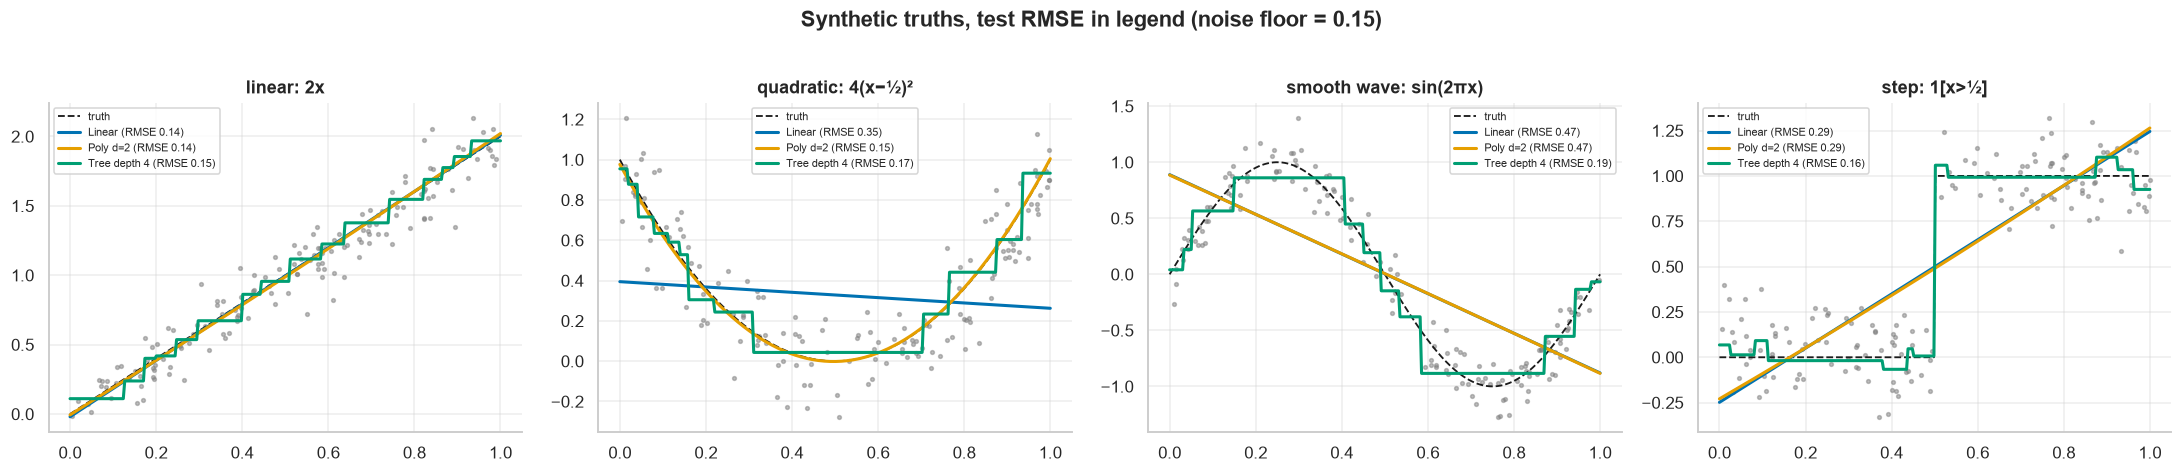

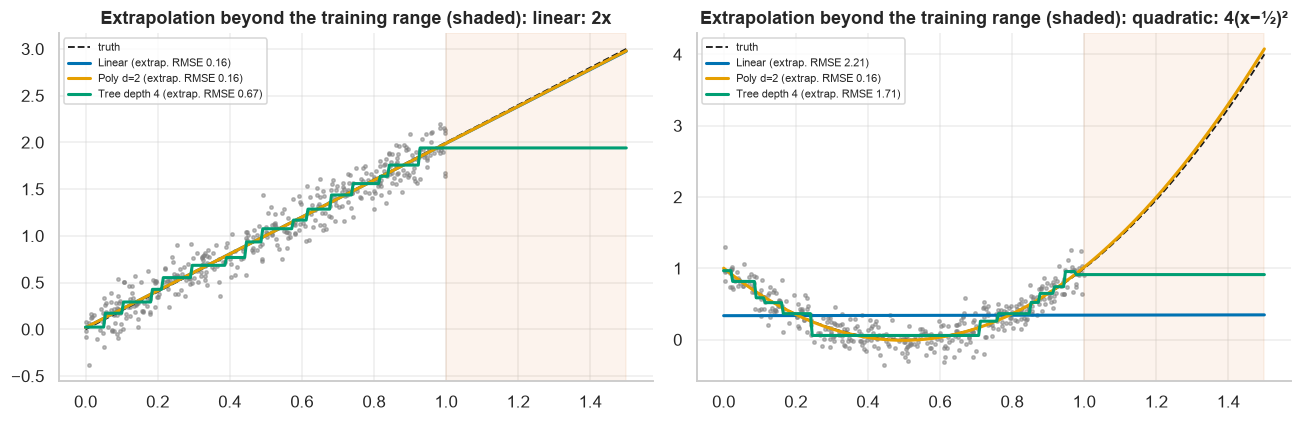

In [63]:
rs = np.random.default_rng(0)
truths = {"linear: 2x": lambda x: 2 * x, "quadratic: 4(x−½)²": lambda x: 4 * (x - .5) ** 2, "smooth wave: sin(2πx)": lambda x: np.sin(2 * np.pi * x), "step: 1[x>½]": lambda x: (x > .5).astype(float)}
mk = {"Linear": lambda: LinearRegressionScratch(), "Poly d=2": lambda: PolyRegressionScratch(2), "Tree depth 4": lambda: DecisionTreeRegressor(max_depth=4, min_samples_leaf=10, random_state=SEED)}
mc = {"Linear": BLUE, "Poly d=2": ORANGE, "Tree depth 4": GREEN}
fig, axes = plt.subplots(1, 4, figsize=(20, 4.2)); SYN = {}
for a, (tn_, f_) in zip(axes, truths.items()):
    x = rs.uniform(0, 1, 500); y = f_(x) + rs.normal(0, .15, 500); xtr, xte, ytr, yte = x[:350], x[350:], y[:350], y[350:]
    a.scatter(xte, yte, s=6, color=GREY, alpha=.5); gx = np.linspace(0, 1, 300); a.plot(gx, f_(gx), "k--", lw=1.2, label="truth")
    for m_, mk_ in mk.items():
        mod = mk_().fit(xtr[:, None], ytr); SYN[(tn_, m_)] = rmse(yte, mod.predict(xte[:, None])); a.plot(gx, mod.predict(gx[:, None]), color=mc[m_], lw=2, label=f"{m_} (RMSE {SYN[(tn_, m_)]:.2f})")
    a.set_title(tn_); a.legend(fontsize=7)
plt.suptitle("Synthetic truths, test RMSE in legend (noise floor = 0.15)", y=1.02, fontweight="bold"); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4)); EXT = {}
for a, (tn_, f_) in zip(axes, [("linear: 2x", truths["linear: 2x"]), ("quadratic: 4(x−½)²", truths["quadratic: 4(x−½)²"])]):
    x = rs.uniform(0, 1, 400); y = f_(x) + rs.normal(0, .15, 400); gx = np.linspace(0, 1.5, 300); a.scatter(x, y, s=5, color=GREY, alpha=.5); a.plot(gx, f_(gx), "k--", lw=1.2, label="truth"); a.axvspan(1, 1.5, color=RED, alpha=.07)
    xe = rs.uniform(1, 1.5, 200); ye = f_(xe) + rs.normal(0, .15, 200)
    for m_, mk_ in mk.items():
        mod = mk_().fit(x[:, None], y); EXT[(tn_, m_)] = rmse(ye, mod.predict(xe[:, None])); a.plot(gx, mod.predict(gx[:, None]), color=mc[m_], lw=2, label=f"{m_} (extrap. RMSE {EXT[(tn_, m_)]:.2f})")
    a.set_title(f"Extrapolation beyond the training range (shaded): {tn_}"); a.legend(fontsize=7)
plt.tight_layout(); plt.show()
display(pd.concat({"in-range test RMSE": pd.Series(SYN).unstack(), "extrapolation RMSE": pd.Series(EXT).unstack()}, axis=1).style.format(precision=3))

**Observations (synthetic data, so the mechanisms can be seen in isolation).**
- **Linear truth:** all three models recover it (RMSE ≈ 0.14–0.15 ≈ the noise floor); the tree draws it as a staircase.
- **Quadratic truth:** the line fails completely (0.35), the degree-2 polynomial is exact (0.15) and the tree approximates it with steps (0.17).
- **Sine wave / step:** the polynomial (degree 2) cannot represent either and equals the straight line (0.47 and 0.29), whereas the **tree is best (0.19 and 0.16)** — trees excel at abrupt or irregular non-linear shapes.
- **Extrapolation:** outside the training range the tree **freezes at its last leaf value** (RMSE 0.67 for a linear truth, 1.71 for a quadratic truth), the straight line keeps going (exact for a linear truth, 2.21 error for a quadratic one) and only the polynomial that matches the truth extrapolates well.
- Linking back to the real data: its CO ↔ sensor relation looks like the *smooth, nearly linear/quadratic* case, not the abrupt-step case — consistent with linear/polynomial ≥ tree.

### 5.4 Where does each model win? — by sensor level, and under unseen conditions
(a) Test RMSE per decile of the dominant sensor `PT08.S2`: does the tree beat the line anywhere? (b) **Extrapolation on real data**: using the chronological split (Stage 2), how large is the fraction of test hours with a feature outside the training range, and how do the models behave there?

,Linear,Poly d=2,Tree depth 5,Tree tuned,mean CO,winner
PT08.S2(NMHC),,,,,,
D1,0.300,0.149,0.218,0.218,0.608,Poly d=2
D2,0.411,0.361,0.428,0.428,0.879,Poly d=2
D3,0.399,0.371,0.416,0.416,1.074,Poly d=2
D4,0.385,0.376,0.401,0.401,1.364,Poly d=2
D5,0.382,0.361,0.388,0.388,1.639,Poly d=2
D6,0.350,0.320,0.391,0.391,1.966,Poly d=2
D7,0.525,0.508,0.548,0.548,2.358,Poly d=2
D8,0.539,0.507,0.589,0.589,2.878,Poly d=2
D9,0.628,0.609,0.642,0.642,3.482,Poly d=2


Deciles in which Tree tuned beats Linear: ['D1'] | Linear beats tree in 9 of 10


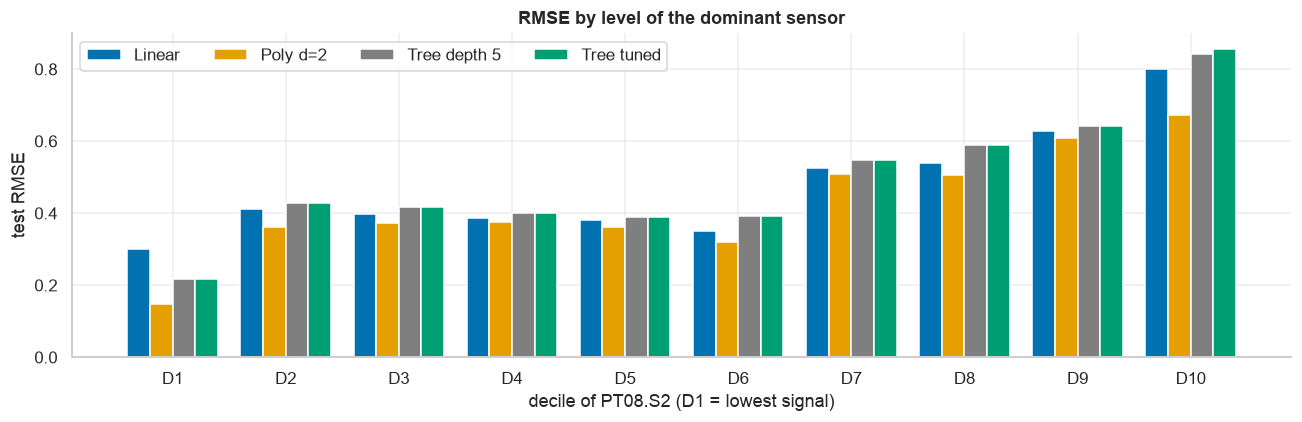

In [64]:
dec = pd.qcut(X_test["PT08.S2(NMHC)"], 10, labels=[f"D{i}" for i in range(1, 11)])
cmp_models = {"Linear": N_LIN_NE, f"Poly d={DEG_STAR}": N_POLY_NE, "Tree depth 5": tree_names[5], "Tree tuned": N_TREE_T}
DECILE = pd.DataFrame({l: pd.Series(yt_all - PRED[nm]["test"], index=y_test.index).groupby(dec, observed=True).apply(lambda s: np.sqrt((s ** 2).mean())) for l, nm in cmp_models.items()})
DECILE["mean CO"] = y_test.groupby(dec, observed=True).mean(); DECILE["winner"] = DECILE[list(cmp_models)].idxmin(axis=1)
display(DECILE.style.format(precision=3).background_gradient(subset=list(cmp_models), cmap="RdYlGn_r", axis=1))
lt = DECILE[["Linear", "Tree tuned"]]; print("Deciles in which Tree tuned beats Linear:", list(lt.index[lt["Tree tuned"] < lt["Linear"]]), "| Linear beats tree in", int((lt["Linear"] < lt["Tree tuned"]).sum()), "of 10")
fig, ax = plt.subplots(figsize=(12, 4)); w = .2
for i, (l, c) in enumerate(zip(cmp_models, [BLUE, ORANGE, GREY, GREEN])): ax.bar(np.arange(10) + (i - 1.5) * w, DECILE[l], w, color=c, label=l)
ax.set_xticks(range(10)); ax.set_xticklabels(DECILE.index); ax.set_xlabel("decile of PT08.S2 (D1 = lowest signal)"); ax.set_ylabel("test RMSE"); ax.set_title("RMSE by level of the dominant sensor"); ax.legend(ncol=4); plt.tight_layout(); plt.show()

**Observations.** The degree-2 polynomial has the lowest RMSE in **all ten deciles** of the dominant sensor. Between the two models the assignment asks about, Linear beats the tuned tree in **9 of 10** deciles; the tree wins only in the lowest decile (D1, 0.218 vs. 0.300), where the relation flattens. The linear model's disadvantage is largest at the extremes of the sensor range (D1 and D10, where the straight line misses the curvature), and the tree's disadvantage is largest in the top decile (0.857 vs. 0.800 for linear and 0.672 for the polynomial). The depth-5 and the tuned tree are identical in nine deciles because both split almost only on `PT08.S2`.

In [65]:
oot_pipes = {l: Pipeline([("scale", StandardScaler()), ("m", mk_())]).fit(Xo_tr, yo_tr) for l, mk_ in {"Linear": make_linear, f"Poly d={DEG_STAR}": make_poly, "Tree depth 5": lambda: DecisionTreeRegressor(max_depth=5, random_state=SEED), "Tree tuned": make_tree}.items()}
lo_, hi_ = Xo_tr.min(), Xo_tr.max(); out_f = (Xo_te < lo_) | (Xo_te > hi_); out_any = out_f.any(axis=1)
print("Share of out-of-time test hours outside the training range, per feature:", {k: f"{v:.1%}" for k, v in out_f.mean().items() if v > 0}, "| any feature:", f"{out_any.mean():.1%}")
EXTRAP = pd.DataFrame({l: {"RMSE inside training range": rmse(yo_te[~out_any], p.predict(Xo_te[~out_any])), "RMSE outside range": rmse(yo_te[out_any], p.predict(Xo_te[out_any])) if out_any.sum() else np.nan,
                           "n inside": int((~out_any).sum()), "n outside": int(out_any.sum())} for l, p in oot_pipes.items()}).T
display(EXTRAP.style.format({"RMSE inside training range": "{:.3f}", "RMSE outside range": "{:.3f}"}))

Share of out-of-time test hours outside the training range, per feature: {'PT08.S2(NMHC)': '0.1%', 'PT08.S4(NO2)': '1.7%', 'PT08.S5(O3)': '0.4%', 'T': '2.6%', 'AH': '0.3%'} | any feature: 3.3%


,RMSE inside training range,RMSE outside range,n inside,n outside
Linear,0.489,0.281,1420.000000,49.000000
Poly d=2,0.451,0.261,1420.000000,49.000000
Tree depth 5,0.534,0.285,1420.000000,49.000000
Tree tuned,0.519,0.285,1420.000000,49.000000


**Observations.** Only **3.3 %** of the out-of-time test hours have any feature outside the range seen in training (mainly `T` 2.6 % and `PT08.S4` 1.7 %), and those hours are easy (RMSE 0.26–0.29 versus 0.45–0.53 inside the range — low CO, low variance). This dataset therefore provides **no empirical evidence of extrapolation failure**; the synthetic demonstration above shows the mechanism, and it would matter for deployment if the sensors drifted further (`PT08.S4` already drifts, Stage 1): a tree would saturate while a linear model would follow the drift.

### 5.5 Ablation ledger — every ablation in one table

In [66]:
NOISE = 0.03     # differences below this are within the fold-to-fold noise seen in Stages 2-3
def verdict(delta):
    return "negligible (within noise)" if abs(delta) < NOISE else ("worse" if delta > 0 else "better")
L = []
def add(group, what, model, delta, unit="ΔCV RMSE", note=""): L.append({"ablation": group, "change": what, "model": model, unit: delta, "verdict": verdict(delta), "note": note})
for m_ in ["Linear", f"Poly(d={DEG_STAR})", "Tree (tuned)"]:
    add("Features", "sensors only (drop weather)", m_, tbl.loc["Sensors only (5)", m_] - base[m_])
    add("Features", "weather only (drop sensors)", m_, tbl.loc["Weather only (T, RH, AH)", m_] - base[m_])
    add("Features", "drop PT08.S2 only", m_, tbl.loc["Drop PT08.S2(NMHC)", m_] - base[m_])
    add("Features", "PT08.S2 as the only feature", m_, tbl.loc["Best single sensor (PT08.S2)", m_] - base[m_])
add("Scaling", "no standardisation (batch GD, 1000 epochs)", "Linear", ABL_SCALE.loc["raw features", "gap to OLS optimum"], "Δ train RMSE", "optimisation, not model quality")
for m_ in ABL_LOG.index: add("Target", "log1p-transformed target", m_, ABL_LOG.loc[m_, "CV RMSE (log1p target)"] - ABL_LOG.loc[m_, "CV RMSE (raw target)"])
for c_ in ["absolute_error", "poisson"]: add("Tree criterion", c_ + " instead of squared_error", "Tree (tuned)", ABL_CRIT.loc[c_, "cv_rmse"] - ABL_CRIT.loc["squared_error", "cv_rmse"])
add("Regularisation", f"ridge (best α≈{RIDGE_CV['cv_rmse'].idxmin():.0f}) instead of OLS", "Linear", RIDGE_CV["cv_rmse"].min() - RIDGE_CV.iloc[0]["cv_rmse"])
add("Regularisation", f"ridge α={ALPHA_R:g} on degree {DEG_R}", f"Poly(d={DEG_R})", RESULTS[N_PR_SC]["cv_rmse"] - RESULTS[N_POLY_NE]["cv_rmse"])
for d_ in (1, 3, 4, 5): add("Polynomial degree", f"degree {d_} instead of {DEG_STAR}", "Poly", unreg.loc[d_, "cv_rmse"] - unreg.loc[DEG_STAR, "cv_rmse"])
for d_ in ("3", "10", "None"): add("Tree depth", f"max_depth={d_} instead of 5", "Tree", TREE_SWEEP[TREE_SWEEP["max_depth"].astype(str) == d_]["cv_rmse"].iloc[0] - RESULTS[tree_names[5]]["cv_rmse"])
add("Tree regularisation", "cost-complexity pruning vs. tuned depth/leaf", "Tree", RESULTS[N_TREE_P]["cv_rmse"] - RESULTS[N_TREE_T]["cv_rmse"])
add("Tree regularisation", "min_samples_leaf=50 added to depth 5", "Tree", RESULTS[N_TREE_T]["cv_rmse"] - RESULTS[tree_names[5]]["cv_rmse"])
add("Hybrid extension", f"linear + depth-{HYBRID['depth']} tree on residuals", "Linear", HYBRID["cv_rmse"] - RESULTS[N_LIN_NE]["cv_rmse"])
for m_, r_ in OOT.iterrows():
    if m_ in ("Linear", f"Poly(d={DEG_STAR})", "Tree (tuned)", "Tree max_depth=5"): add("Evaluation protocol", "chronological instead of shuffled split", m_, r_["degradation (oot - random)"], "Δ test RMSE")
LEDGER = pd.DataFrame(L); LEDGER["Δ"] = LEDGER[["ΔCV RMSE", "Δ train RMSE", "Δ test RMSE"]].bfill(axis=1).iloc[:, 0]
LEDGER = LEDGER[["ablation", "change", "model", "Δ", "verdict", "note"]].fillna({"note": ""})
display(LEDGER.style.format({"Δ": "{:+.4f}"}).map(lambda v: "color:#b00000;font-weight:600" if v == "worse" else ("color:#1a7f37;font-weight:600" if v == "better" else ""), subset=["verdict"]).hide(axis="index"))
print("Positive Δ = the ablated variant is worse than the reference. Noise threshold used for the verdict:", NOISE)

ablation,change,model,Δ,verdict,note
Features,sensors only (drop weather),Linear,+0.0143,negligible (within noise),
Features,weather only (drop sensors),Linear,+0.9541,worse,
Features,drop PT08.S2 only,Linear,+0.1191,worse,
Features,PT08.S2 as the only feature,Linear,+0.0869,worse,
Features,sensors only (drop weather),Poly(d=2),+0.0157,negligible (within noise),
Features,weather only (drop sensors),Poly(d=2),+1.0027,worse,
Features,drop PT08.S2 only,Poly(d=2),+0.0710,worse,
Features,PT08.S2 as the only feature,Poly(d=2),+0.0666,worse,
Features,sensors only (drop weather),Tree (tuned),+0.0143,negligible (within noise),
Features,weather only (drop sensors),Tree (tuned),+0.9575,worse,


Positive Δ = the ablated variant is worse than the reference. Noise threshold used for the verdict: 0.03


**Observations — what the ablations tell us.**
- **Features:** sensors alone are essentially as good as everything (+0.014 to +0.016, within noise); weather alone is as bad as the mean predictor (+0.95 to +1.00); `PT08.S2` is the one indispensable feature (dropping it costs +0.07 to +0.15) and the only one for which a single-feature model is already competitive.
- **Model complexity:** the polynomial degree must be exactly 2 (degree 1: +0.035, degree 3: +0.047, degree 4: +0.77, degree 5: +8.1); for trees depth 5 is best (3: +0.068, 10: +0.089, `None`: +0.150).
- **Preprocessing:** standardisation matters for gradient-based optimisation (+0.14 train RMSE without it) and log-transforming the target hurts the linear model (+0.036) while being neutral for the others.
- **Negligible (within noise):** ridge for the linear model or the polynomial, the tree split criterion, cost-complexity pruning vs. the tuned tree, the hybrid correction (−0.018, in the right direction), and the chronological split (|Δ| ≤ 0.015). The conclusions are therefore robust to these choices.

### 5.6 Scorecard — Linear vs. Decision Tree vs. Polynomial

In [67]:
SC_M = {"Linear": N_LIN_NE, "Tree depth 5": tree_names[5], "Tree tuned": N_TREE_T, f"Poly d={DEG_STAR}": N_POLY_NE}
reg = REGIME.set_index(["model", "regime"]); vh = bands_labels[-1]; hi_r = bands_labels[-2]
fold_col = {"Linear": "Linear", "Tree depth 5": "Tree depth 5", "Tree tuned": "Tree (tuned)", f"Poly d={DEG_STAR}": f"Poly(d={DEG_STAR})"}
oot_row = {"Linear": "Linear", "Tree depth 5": "Tree max_depth=5", "Tree tuned": "Tree (tuned)", f"Poly d={DEG_STAR}": f"Poly(d={DEG_STAR})"}
SCORE = pd.DataFrame({l: {"test RMSE": RESULTS[nm]["test_rmse"], "test R²": RESULTS[nm]["test_r2"], "CV RMSE": RESULTS[nm]["cv_rmse"], "CV fold-to-fold sd": FOLD_RMSE.loc["sd", fold_col[l]],
                          "out-of-time test RMSE": OOT.loc[oot_row[l], "oot_test_rmse"], "RMSE gap (test − train)": RESULTS[nm]["rmse_gap (test-train)"],
                          f"RMSE, {hi_r}": reg.loc[(nm, hi_r), "rmse"], f"RMSE, {vh}": reg.loc[(nm, vh), "rmse"], f"bias, {vh}": reg.loc[(nm, vh), "bias (pred-true)"],
                          "parameters / leaves": RESULTS[nm]["complexity"], "fit time (s)": RESULTS[nm]["fit_time_s"]} for l, nm in SC_M.items()})
lower_better = [r for r in SCORE.index if r not in ("test R²", f"bias, {vh}")]
SCORE["best"] = [SCORE.loc[r].idxmin() if r in lower_better else (SCORE.loc[r].idxmax() if r == "test R²" else SCORE.loc[r].abs().idxmin()) for r in SCORE.index]
display(SCORE.style.format({c: "{:.4f}" for c in SCORE.columns if c != "best"}))
static = pd.DataFrame({"Linear": ["yes (straight line)", "no", "9 signed coefficients with CIs", "needs scaling for GD", "yes"],
                       "Decision Tree": ["no — constant beyond the training range", "yes", "readable rules / leaves, but unstable across data subsets", "none needed", "no (staircase)"],
                       f"Poly d={DEG_STAR}": ["yes, but quadratic growth", "mild (degree 2)", "45 correlated terms: hard to read", "needs scaling", "yes"]},
                      index=["extrapolates beyond the training range", "captures non-linear / interaction effects", "interpretability", "preprocessing sensitivity", "smooth predictions"])
display(static)

,Linear,Tree depth 5,Tree tuned,Poly d=2,best
test RMSE,0.4933,0.5131,0.5157,0.4470,Poly d=2
test R²,0.8799,0.8700,0.8687,0.9013,Poly d=2
CV RMSE,0.4882,0.5092,0.5134,0.4530,Poly d=2
CV fold-to-fold sd,0.0610,0.0572,0.0534,0.0538,Tree tuned
out-of-time test RMSE,0.4836,0.5276,0.5126,0.4460,Poly d=2
RMSE gap (test − train),0.0134,0.0728,0.0459,0.0359,Linear
"RMSE, High (3-5)",0.5193,0.6460,0.6529,0.5594,Linear
"RMSE, Very high (>=5)",1.1729,1.1518,1.1608,0.9462,Poly d=2
"bias, Very high (>=5)",-0.9270,-0.6597,-0.5561,-0.5550,Poly d=2
parameters / leaves,9.0000,32.0000,29.0000,45.0000,Linear


,Linear,Decision Tree,Poly d=2
extrapolates beyond the training range,yes (straight line),no — constant beyond the training range,"yes, but quadratic growth"
captures non-linear / interaction effects,no,yes,mild (degree 2)
interpretability,9 signed coefficients with CIs,"readable rules / leaves, but unstable across d...",45 correlated terms: hard to read
preprocessing sensitivity,needs scaling for GD,none needed,needs scaling
smooth predictions,yes,no (staircase),yes


**Observations.**
- **Accuracy:** Polynomial d=2 is best on test RMSE/R², CV RMSE and out-of-time RMSE; Linear is second; the trees are third. In the High regime Linear (0.519) is far better than the trees (0.646–0.653); in the Very-high regime the models are close (tree 1.15–1.16, linear 1.17, polynomial 0.95), with the trees slightly less biased than linear (−0.56 to −0.66 vs. −0.93).
- **Simplicity and stability:** Linear has the fewest parameters, the smallest generalisation gap and the fastest fit; the differences in fold-to-fold sd (0.053–0.061) are not meaningful.
- **Qualitative:** trees need no scaling and give readable rules, but cannot extrapolate and give staircase predictions; the polynomial is accurate but its 45 collinear terms are hard to interpret and it is fragile on unrealistic inputs (Stage 4).

✅ **Stage 5 complete** — head-to-head comparison with uncertainty, evidence on linear vs. non-linear structure, a synthetic illustration, regime-wise wins, extrapolation behaviour, the ablation ledger and the scorecard.

---
## Stage 6 — Discussion *(next)*